<a href="https://colab.research.google.com/github/sgsinghashka-del/Linear-Regression-30-Practical-Projects/blob/main/Linear_Regression_30_Practical_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. House Price Prediction

Dataset:
    Area  Bedrooms  Bathrooms  House_Price
0    800         1          1           35
1   1000         2          1           42
2   1200         2          2           50
3   1400         2          2           58
4   1600         3          2           68
5   1800         3          2           75
6   2000         3          3           85
7   2200         4          3           95
8   2400         4          3          105
9   2600         4          3          115
10  2800         4          4          128
11  3000         5          4          140
12  3200         5          4          150
13  3400         5          5          165
14  3600         6          5          180

Model Evaluation
----------------
MAE : 5.09
RMSE: 6.84
R2 Score: 0.98

Model Coefficients
------------------
Area coefficient: 0.0389
Bedrooms coefficient: 4.4031
Bathrooms coefficient: 5.0534
Intercept: -17.1543

New House Prediction
--------------------
Area: 2500 sq.ft
Bedrooms: 4
Bathrooms: 3
Pre

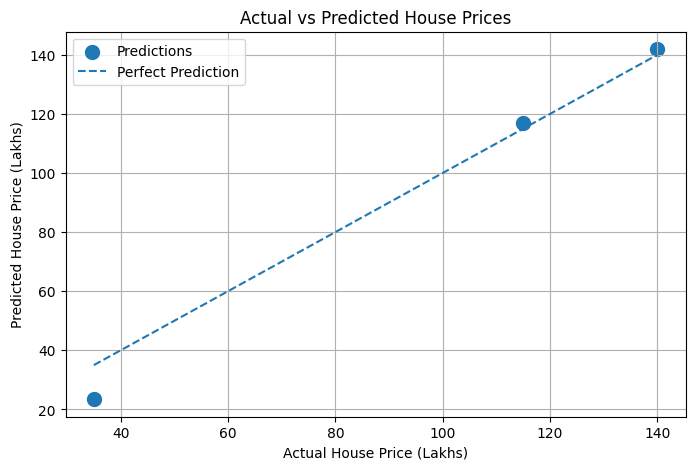

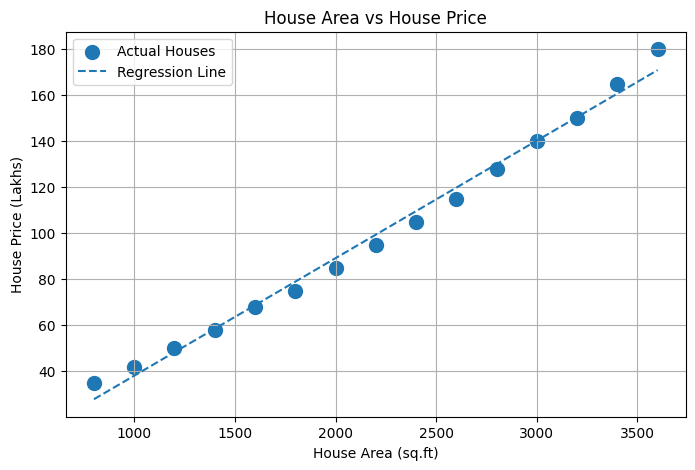

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------
# 1. Create sample dataset
# --------------------------------

data = {
    "Area": [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600,
             2800, 3000, 3200, 3400, 3600],

    "Bedrooms": [1, 2, 2, 2, 3, 3, 3, 4, 4, 4,
                 4, 5, 5, 5, 6],

    "Bathrooms": [1, 1, 2, 2, 2, 2, 3, 3, 3, 3,
                  4, 4, 4, 5, 5],

    "House_Price": [35, 42, 50, 58, 68, 75, 85, 95, 105, 115,
                    128, 140, 150, 165, 180]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# --------------------------------
# 2. Define X and Y
# --------------------------------

X = df[["Area", "Bedrooms", "Bathrooms"]]
y = df["House_Price"]

# --------------------------------
# 3. Split the data
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# --------------------------------
# 4. Train Linear Regression
# --------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# --------------------------------
# 5. Prediction
# --------------------------------

y_pred = model.predict(X_test)

# --------------------------------
# 6. Model Evaluation
# --------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

# --------------------------------
# 7. Model Coefficients
# --------------------------------

print("\nModel Coefficients")
print("------------------")
print("Area coefficient:", round(model.coef_[0], 4))
print("Bedrooms coefficient:", round(model.coef_[1], 4))
print("Bathrooms coefficient:", round(model.coef_[2], 4))
print("Intercept:", round(model.intercept_, 4))

# --------------------------------
# 8. Predict a New House
# --------------------------------

new_house = pd.DataFrame({
    "Area": [2500],
    "Bedrooms": [4],
    "Bathrooms": [3]
})

predicted_price = model.predict(new_house)

print("\nNew House Prediction")
print("--------------------")
print("Area: 2500 sq.ft")
print("Bedrooms: 4")
print("Bathrooms: 3")
print("Predicted Price: ₹", round(predicted_price[0], 2), "Lakhs")

# --------------------------------
# 9. Graph: Actual vs Predicted
# --------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=100,
    label="Predictions"
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual House Price (Lakhs)")
plt.ylabel("Predicted House Price (Lakhs)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(True)

plt.show()

# --------------------------------
# 10. Graph: Area vs House Price
# --------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Area"],
    df["House_Price"],
    s=100,
    label="Actual Houses"
)

# Fit simple line only for visualization
visual_model = LinearRegression()
visual_model.fit(df[["Area"]], df["House_Price"])

area_range = pd.DataFrame({
    "Area": range(df["Area"].min(), df["Area"].max() + 1, 50)
})

price_line = visual_model.predict(area_range)

plt.plot(
    area_range["Area"],
    price_line,
    linestyle="--",
    label="Regression Line"
)

plt.xlabel("House Area (sq.ft)")
plt.ylabel("House Price (Lakhs)")
plt.title("House Area vs House Price")
plt.legend()
plt.grid(True)

plt.show()

2. Salary Prediction

Employee Salary Dataset
    Experience  Education  Age  Salary
0            1         12   22     3.2
1            2         14   24     3.8
2            3         15   25     4.5
3            4         16   27     5.2
4            5         16   28     5.8
5            6         16   30     6.5
6            7         18   31     7.2
7            8         18   33     8.0
8            9         16   34     8.7
9           10         18   36     9.5
10          11         18   37    10.2
11          12         16   39    11.0
12          13         18   40    11.8
13          14         18   42    12.7
14          15         16   43    13.5
15          16         18   45    14.5
16          17         18   46    15.5
17          18         18   48    16.5
18          19         18   49    17.5
19          20         18   51    18.5

Model Evaluation
----------------
MAE  : 0.33
RMSE : 0.37
R² Score : 1.0

Model Coefficients
------------------
Experience : 0.699
Education  : -0.076
Age  

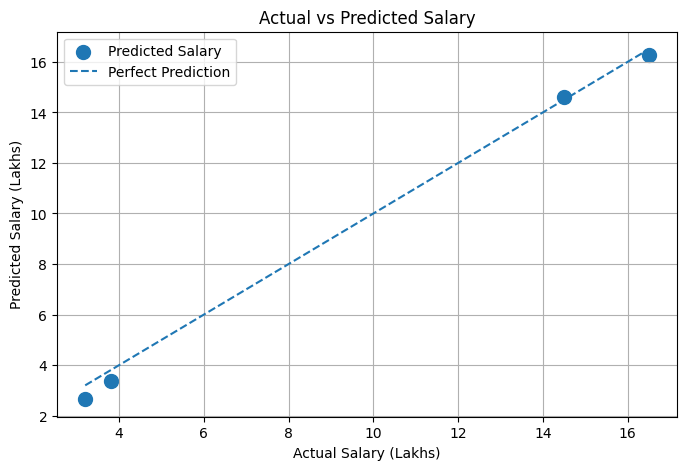

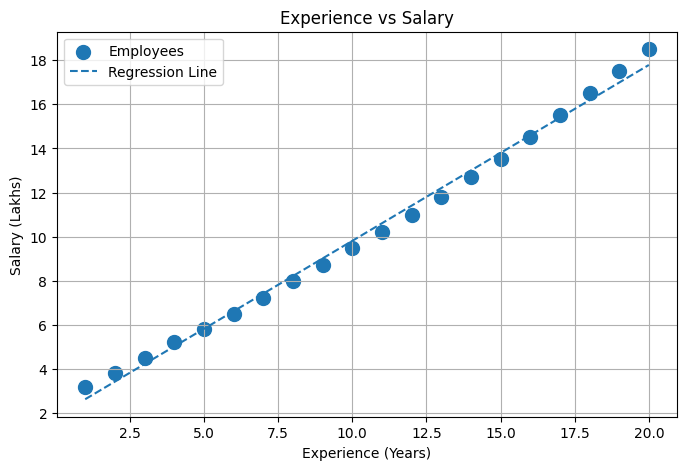

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------
# 1. Create realistic employee dataset
# ------------------------------------------------

data = {
    "Experience": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 15, 16, 17, 18, 19, 20
    ],

    "Education": [
        12, 14, 15, 16, 16, 16, 18, 18, 16, 18,
        18, 16, 18, 18, 16, 18, 18, 18, 18, 18
    ],

    "Age": [
        22, 24, 25, 27, 28, 30, 31, 33, 34, 36,
        37, 39, 40, 42, 43, 45, 46, 48, 49, 51
    ],

    "Salary": [
        3.2, 3.8, 4.5, 5.2, 5.8, 6.5, 7.2, 8.0, 8.7, 9.5,
        10.2, 11.0, 11.8, 12.7, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5
    ]
}

df = pd.DataFrame(data)

print("Employee Salary Dataset")
print(df)

# ------------------------------------------------
# 2. Define input and target
# ------------------------------------------------

X = df[["Experience", "Education", "Age"]]
y = df["Salary"]

# ------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------
# 4. Train Linear Regression Model
# ------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)

# ------------------------------------------------
# 5. Make Predictions
# ------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------
# 6. Model Evaluation
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R² Score :", round(r2, 2))

# ------------------------------------------------
# 7. Display Model Coefficients
# ------------------------------------------------

print("\nModel Coefficients")
print("------------------")

print("Experience :", round(model.coef_[0], 3))
print("Education  :", round(model.coef_[1], 3))
print("Age        :", round(model.coef_[2], 3))

print("Intercept  :", round(model.intercept_, 3))

# ------------------------------------------------
# 8. Predict Salary for a New Employee
# ------------------------------------------------

new_employee = pd.DataFrame({
    "Experience": [8],
    "Education": [18],
    "Age": [32]
})

predicted_salary = model.predict(new_employee)

print("\nNew Employee Prediction")
print("-----------------------")
print("Experience : 8 years")
print("Education  : 18 years")
print("Age        : 32 years")

print(
    "Predicted Salary : ₹",
    round(predicted_salary[0], 2),
    "Lakhs per year"
)

# ------------------------------------------------
# 9. Graph 1 - Actual vs Predicted Salary
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=100,
    label="Predicted Salary"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Salary (Lakhs)")
plt.ylabel("Predicted Salary (Lakhs)")
plt.title("Actual vs Predicted Salary")

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------
# 10. Graph 2 - Experience vs Salary
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Experience"],
    df["Salary"],
    s=100,
    label="Employees"
)

# Simple regression line for visualization
visual_model = LinearRegression()

visual_model.fit(
    df[["Experience"]],
    df["Salary"]
)

experience_range = pd.DataFrame({
    "Experience": range(
        df["Experience"].min(),
        df["Experience"].max() + 1
    )
})

salary_line = visual_model.predict(experience_range)

plt.plot(
    experience_range["Experience"],
    salary_line,
    linestyle="--",
    label="Regression Line"
)

plt.xlabel("Experience (Years)")
plt.ylabel("Salary (Lakhs)")
plt.title("Experience vs Salary")

plt.legend()
plt.grid(True)

plt.show()


Student Dataset
----------------
    Study_Hours  Attendance  Assignments  Marks
0             1          55            2     35
1             2          60            3     40
2             2          65            3     44
3             3          62            4     48
4             3          70            4     50
5             4          68            5     54
6             4          75            5     58
7             5          72            6     61
8             5          78            6     64
9             6          75            7     67
10            6          82            7     69
11            7          80            8     72
12            7          85            8     74
13            8          83            8     77
14            8          88            9     79
15            9          85            9     82
16            9          90            9     84
17           10          92           10     87
18           10          94           10     89
19    

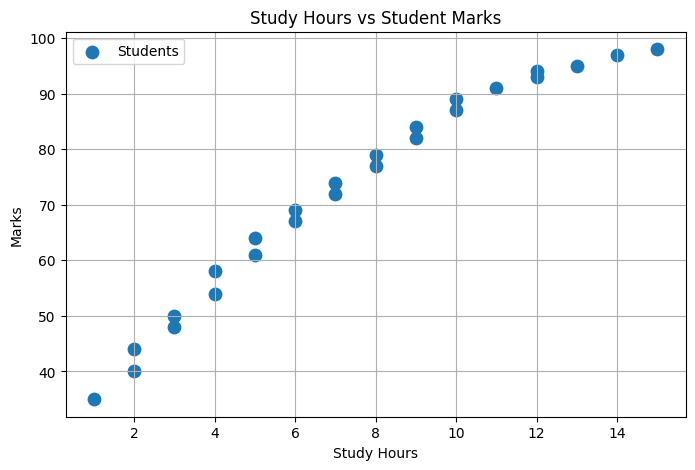

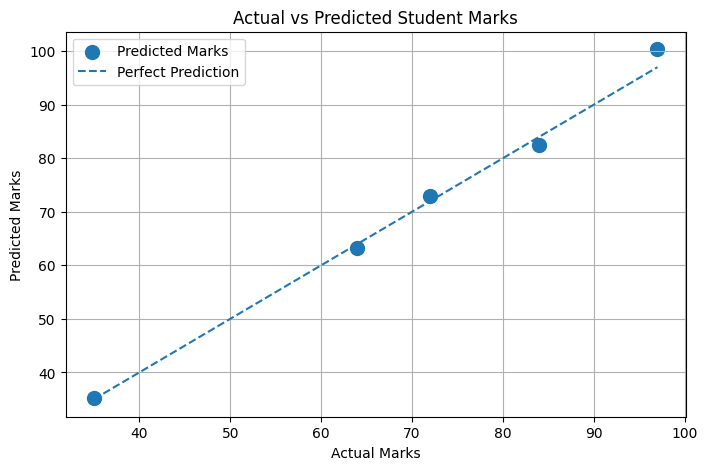

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------
# 1. Student Dataset
# ------------------------------------------------

data = {
    "Study_Hours": [
        1, 2, 2, 3, 3, 4, 4, 5, 5, 6,
        6, 7, 7, 8, 8, 9, 9, 10, 10, 11,
        12, 12, 13, 14, 15
    ],

    "Attendance": [
        55, 60, 65, 62, 70, 68, 75, 72, 78, 75,
        82, 80, 85, 83, 88, 85, 90, 92, 94, 93,
        95, 96, 97, 98, 99
    ],

    "Assignments": [
        2, 3, 3, 4, 4, 5, 5, 6, 6, 7,
        7, 8, 8, 8, 9, 9, 9, 10, 10, 10,
        10, 11, 11, 12, 12
    ],

    "Marks": [
        35, 40, 44, 48, 50, 54, 58, 61, 64, 67,
        69, 72, 74, 77, 79, 82, 84, 87, 89, 91,
        93, 94, 95, 97, 98
    ]
}

df = pd.DataFrame(data)

print("\nStudent Dataset")
print("----------------")
print(df)


# ------------------------------------------------
# 2. Input and Target
# ------------------------------------------------

X = df[[
    "Study_Hours",
    "Attendance",
    "Assignments"
]]

y = df["Marks"]


# ------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------
# 4. Train Linear Regression Model
# ------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ------------------------------------------------
# 5. Model Prediction
# ------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------
# 6. Model Evaluation
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))
print("R2 Score :", round(r2, 2))


# ------------------------------------------------
# 7. Take Input From User
# ------------------------------------------------

print("\n==============================")
print(" Student Marks Prediction")
print("==============================")

# Study Hours
while True:
    try:
        study_hours = float(
            input("Enter Study Hours (0-15): ")
        )

        if 0 <= study_hours <= 15:
            break

        print("Please enter Study Hours between 0 and 15.")

    except ValueError:
        print("Please enter a valid number.")


# Attendance
while True:
    try:
        attendance = float(
            input("Enter Attendance Percentage (0-100): ")
        )

        if 0 <= attendance <= 100:
            break

        print("Please enter Attendance between 0 and 100.")

    except ValueError:
        print("Please enter a valid number.")


# Assignments
while True:
    try:
        assignments = int(
            input("Enter Assignments Submitted (0-12): ")
        )

        if 0 <= assignments <= 12:
            break

        print("Please enter Assignments between 0 and 12.")

    except ValueError:
        print("Please enter a valid whole number.")


# ------------------------------------------------
# 8. Predict Marks
# ------------------------------------------------

student_input = pd.DataFrame({
    "Study_Hours": [study_hours],
    "Attendance": [attendance],
    "Assignments": [assignments]
})

predicted_marks = model.predict(student_input)[0]

# Keep marks within 0-100
predicted_marks = max(0, min(100, predicted_marks))


# ------------------------------------------------
# 9. Display Result
# ------------------------------------------------

print("\n==============================")
print(" Prediction Result")
print("==============================")

print("Study Hours          :", study_hours)
print("Attendance            :", attendance, "%")
print("Assignments Submitted :", assignments)

print(
    "\nPredicted Marks       :",
    round(predicted_marks, 2)
)


# ------------------------------------------------
# 10. Performance Condition
# ------------------------------------------------

if predicted_marks >= 90:
    result = "Excellent"

elif predicted_marks >= 75:
    result = "Very Good"

elif predicted_marks >= 60:
    result = "Good"

elif predicted_marks >= 40:
    result = "Pass"

else:
    result = "Needs Improvement"


print("Performance           :", result)


# ------------------------------------------------
# 11. Graph 1
# Study Hours vs Marks
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Marks"],
    s=80,
    label="Students"
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Student Marks")

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------
# 12. Graph 2
# Actual vs Predicted
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=100,
    label="Predicted Marks"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Student Marks")

plt.legend()
plt.grid(True)

plt.show()

4. Electricity Consumption Prediction


Electricity Consumption Dataset
--------------------------------
    Temperature  Day  Household_Size  Electricity_Units
0            18    1               2                145
1            20    2               3                170
2            22    3               2                155
3            24    4               4                205
4            25    5               3                190
5            26    6               4                220
6            27    7               5                245
7            28    8               3                200
8            29    9               4                235
9            30   10               5                270
10           31   11               4                250
11           32   12               5                285
12           33   13               6                320
13           34   14               4                275
14           35   15               5                310
15           36   16               6  

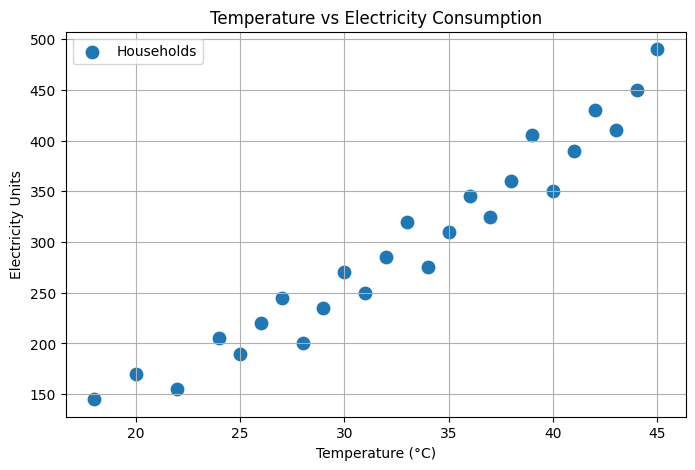

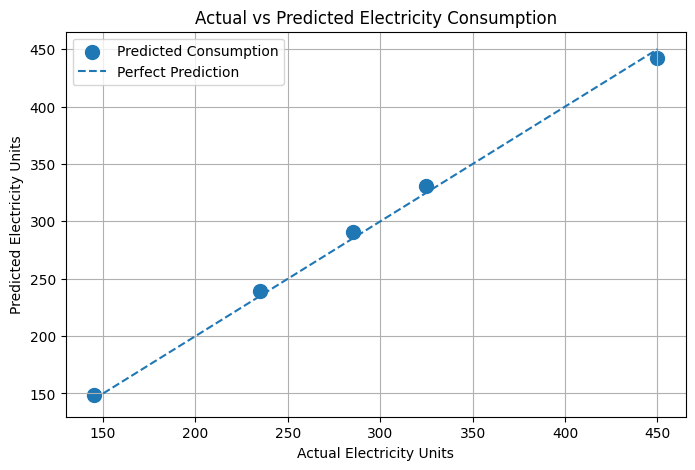

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------
# 1. Create Dataset
# ------------------------------------------------

data = {
    "Temperature": [
        18, 20, 22, 24, 25, 26, 27, 28, 29, 30,
        31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
        41, 42, 43, 44, 45
    ],

    "Day": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25
    ],

    "Household_Size": [
        2, 3, 2, 4, 3, 4, 5, 3, 4, 5,
        4, 5, 6, 4, 5, 6, 5, 6, 7, 5,
        6, 7, 6, 7, 8
    ],

    "Electricity_Units": [
        145, 170, 155, 205, 190, 220, 245, 200, 235, 270,
        250, 285, 320, 275, 310, 345, 325, 360, 405, 350,
        390, 430, 410, 450, 490
    ]
}

df = pd.DataFrame(data)

print("\nElectricity Consumption Dataset")
print("--------------------------------")
print(df)


# ------------------------------------------------
# 2. Define Input and Target
# ------------------------------------------------

X = df[
    [
        "Temperature",
        "Day",
        "Household_Size"
    ]
]

y = df["Electricity_Units"]


# ------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------
# 4. Train Linear Regression Model
# ------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ------------------------------------------------
# 5. Predict Test Data
# ------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------
# 6. Model Evaluation
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))
print("R2 Score :", round(r2, 2))


# ------------------------------------------------
# 7. Model Coefficients
# ------------------------------------------------

print("\nModel Coefficients")
print("------------------")

print(
    "Temperature Coefficient :",
    round(model.coef_[0], 3)
)

print(
    "Day Coefficient         :",
    round(model.coef_[1], 3)
)

print(
    "Household Size Coefficient :",
    round(model.coef_[2], 3)
)

print(
    "Intercept :",
    round(model.intercept_, 3)
)


# ------------------------------------------------
# 8. Take User Input
# ------------------------------------------------

print("\n===================================")
print(" Electricity Consumption Prediction")
print("===================================")


# Temperature
while True:
    try:

        temperature = float(
            input("Enter Temperature (10-50 °C): ")
        )

        if 10 <= temperature <= 50:
            break

        print(
            "Please enter temperature between 10 and 50 °C."
        )

    except ValueError:

        print("Please enter a valid number.")


# Day
while True:
    try:

        day = int(
            input("Enter Day of Month (1-31): ")
        )

        if 1 <= day <= 31:
            break

        print(
            "Please enter a day between 1 and 31."
        )

    except ValueError:

        print("Please enter a valid whole number.")


# Household Size
while True:
    try:

        household_size = int(
            input("Enter Household Size (1-10): ")
        )

        if 1 <= household_size <= 10:
            break

        print(
            "Please enter household size between 1 and 10."
        )

    except ValueError:

        print("Please enter a valid whole number.")


# ------------------------------------------------
# 9. Create Input DataFrame
# ------------------------------------------------

new_household = pd.DataFrame({
    "Temperature": [temperature],
    "Day": [day],
    "Household_Size": [household_size]
})


# ------------------------------------------------
# 10. Predict Electricity Consumption
# ------------------------------------------------

predicted_units = model.predict(
    new_household
)[0]


# Prevent negative prediction
predicted_units = max(
    0,
    predicted_units
)


# ------------------------------------------------
# 11. Display Result
# ------------------------------------------------

print("\n===================================")
print(" Prediction Result")
print("===================================")

print(
    "Temperature      :",
    temperature,
    "°C"
)

print(
    "Day               :",
    day
)

print(
    "Household Size    :",
    household_size
)

print(
    "\nPredicted Electricity Consumption :",
    round(predicted_units, 2),
    "Units"
)


# ------------------------------------------------
# 12. Consumption Category
# ------------------------------------------------

if predicted_units < 200:

    category = "Low Consumption"

elif predicted_units < 350:

    category = "Moderate Consumption"

elif predicted_units < 500:

    category = "High Consumption"

else:

    category = "Very High Consumption"


print(
    "Consumption Category              :",
    category
)


# ------------------------------------------------
# 13. Graph 1
# Temperature vs Electricity Units
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Temperature"],
    df["Electricity_Units"],
    s=80,
    label="Households"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Units")
plt.title(
    "Temperature vs Electricity Consumption"
)

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------
# 14. Graph 2
# Actual vs Predicted
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=100,
    label="Predicted Consumption"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Electricity Units")
plt.ylabel("Predicted Electricity Units")

plt.title(
    "Actual vs Predicted Electricity Consumption"
)

plt.legend()
plt.grid(True)

plt.show()

5. Car Price Prediction


Car Price Dataset
-----------------
    Age  Mileage  Engine_Size  Car_Price
0     1    10000          1.2        9.5
1     2    15000          1.2        9.0
2     2    18000          1.5       10.2
3     3    22000          1.2        8.5
4     3    25000          1.5        9.3
5     4    30000          1.5        8.0
6     4    33000          1.6        8.7
7     5    38000          1.5        7.5
8     5    42000          1.6        8.1
9     6    47000          1.8        7.0
10    6    50000          1.6        7.6
11    7    55000          1.8        6.5
12    7    58000          2.0        7.2
13    8    62000          1.8        6.0
14    8    67000          2.0        6.8
15    9    71000          2.0        5.5
16    9    76000          2.2        6.2
17   10    80000          2.0        5.0
18   10    85000          2.2        5.7
19   11    90000          2.0        4.8
20   12    95000          2.2        4.5
21   12   100000          2.4        4.2
22   13   108000    

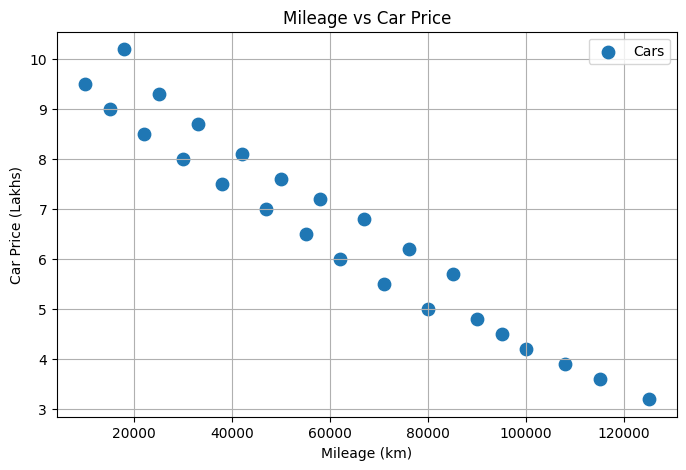

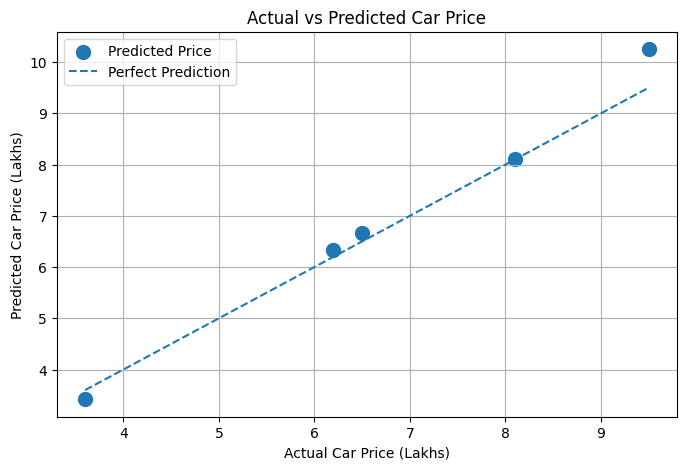

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ------------------------------------------------
# 1. Create Dataset
# ------------------------------------------------

data = {
    "Age": [
        1, 2, 2, 3, 3, 4, 4, 5, 5, 6,
        6, 7, 7, 8, 8, 9, 9, 10, 10, 11,
        12, 12, 13, 14, 15
    ],

    "Mileage": [
        10000, 15000, 18000, 22000, 25000,
        30000, 33000, 38000, 42000, 47000,
        50000, 55000, 58000, 62000, 67000,
        71000, 76000, 80000, 85000, 90000,
        95000, 100000, 108000, 115000, 125000
    ],

    "Engine_Size": [
        1.2, 1.2, 1.5, 1.2, 1.5,
        1.5, 1.6, 1.5, 1.6, 1.8,
        1.6, 1.8, 2.0, 1.8, 2.0,
        2.0, 2.2, 2.0, 2.2, 2.0,
        2.2, 2.4, 2.2, 2.5, 2.4
    ],

    # Price in Lakhs
    "Car_Price": [
        9.5, 9.0, 10.2, 8.5, 9.3,
        8.0, 8.7, 7.5, 8.1, 7.0,
        7.6, 6.5, 7.2, 6.0, 6.8,
        5.5, 6.2, 5.0, 5.7, 4.8,
        4.5, 4.2, 3.9, 3.6, 3.2
    ]
}

df = pd.DataFrame(data)

print("\nCar Price Dataset")
print("-----------------")
print(df)


# ------------------------------------------------
# 2. Define Input and Target
# ------------------------------------------------

X = df[
    [
        "Age",
        "Mileage",
        "Engine_Size"
    ]
]

y = df["Car_Price"]


# ------------------------------------------------
# 3. Train-Test Split
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ------------------------------------------------
# 4. Train Linear Regression Model
# ------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ------------------------------------------------
# 5. Predict Test Data
# ------------------------------------------------

y_pred = model.predict(X_test)


# ------------------------------------------------
# 6. Model Evaluation
# ------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("----------------")
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))
print("R2 Score :", round(r2, 2))


# ------------------------------------------------
# 7. Model Coefficients
# ------------------------------------------------

print("\nModel Coefficients")
print("------------------")

print(
    "Age Coefficient :",
    round(model.coef_[0], 4)
)

print(
    "Mileage Coefficient :",
    round(model.coef_[1], 6)
)

print(
    "Engine Size Coefficient :",
    round(model.coef_[2], 4)
)

print(
    "Intercept :",
    round(model.intercept_, 4)
)


# ------------------------------------------------
# 8. Take User Input
# ------------------------------------------------

print("\n================================")
print("      Car Price Prediction")
print("================================")


# Age
while True:
    try:

        age = float(
            input("Enter Car Age (0-20 years): ")
        )

        if 0 <= age <= 20:
            break

        print(
            "Please enter car age between 0 and 20."
        )

    except ValueError:

        print("Please enter a valid number.")


# Mileage
while True:
    try:

        mileage = float(
            input("Enter Mileage (0-200000 km): ")
        )

        if 0 <= mileage <= 200000:
            break

        print(
            "Please enter mileage between 0 and 200000 km."
        )

    except ValueError:

        print("Please enter a valid number.")


# Engine Size
while True:
    try:

        engine_size = float(
            input("Enter Engine Size (0.8-5.0 L): ")
        )

        if 0.8 <= engine_size <= 5.0:
            break

        print(
            "Please enter engine size between 0.8 and 5.0 L."
        )

    except ValueError:

        print("Please enter a valid number.")


# ------------------------------------------------
# 9. Create New Car Data
# ------------------------------------------------

new_car = pd.DataFrame({
    "Age": [age],
    "Mileage": [mileage],
    "Engine_Size": [engine_size]
})


# ------------------------------------------------
# 10. Predict Car Price
# ------------------------------------------------

predicted_price = model.predict(new_car)[0]

# Prevent negative price
predicted_price = max(0, predicted_price)


# ------------------------------------------------
# 11. Display Prediction
# ------------------------------------------------

print("\n================================")
print("       Prediction Result")
print("================================")

print("Car Age       :", age, "years")
print("Mileage       :", mileage, "km")
print("Engine Size   :", engine_size, "L")

print(
    "\nPredicted Car Price : ₹",
    round(predicted_price, 2),
    "Lakhs"
)


# ------------------------------------------------
# 12. Price Category
# ------------------------------------------------

if predicted_price < 5:

    category = "Budget Car"

elif predicted_price < 10:

    category = "Mid-Range Car"

elif predicted_price < 20:

    category = "Premium Car"

else:

    category = "Luxury Car"


print(
    "Price Category      :",
    category
)


# ------------------------------------------------
# 13. Graph 1
# Mileage vs Car Price
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Mileage"],
    df["Car_Price"],
    s=80,
    label="Cars"
)

plt.xlabel("Mileage (km)")
plt.ylabel("Car Price (Lakhs)")
plt.title("Mileage vs Car Price")

plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------
# 14. Graph 2
# Actual vs Predicted
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=100,
    label="Predicted Price"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Car Price (Lakhs)")
plt.ylabel("Predicted Car Price (Lakhs)")
plt.title("Actual vs Predicted Car Price")

plt.legend()
plt.grid(True)

plt.show()

6. Mobile Price Prediction


Mobile Dataset:
   RAM  Storage  Battery  Camera  Price
0    2       32     4000      12   8999
1    3       32     4500      13  10999
2    4       64     5000      16  13999
3    4      128     5000      20  15999
4    6      128     4500      24  19999

========== MODEL EVALUATION ==========
MAE  : ₹2,193.93
MSE  : 8,556,111.91
RMSE : ₹2,925.08
R²   : 0.98

========== MODEL COEFFICIENTS ==========
RAM: 1,434.87
Storage: 29.30
Battery: -3.53
Camera: 328.90
Intercept: 15,821.10

========== ENTER MOBILE DETAILS ==========
Enter RAM (GB): 2
Enter Storage (GB): 3
Please enter storage as 16, 32, 64, 128, 256, 512 or 1024 GB.
Enter Storage (GB): 16
Enter Battery Capacity (mAh): 2000
Enter Main Camera (MP): 600
Please enter camera between 5 and 200 MP.
Enter Main Camera (MP): 15

       MOBILE PRICE PREDICTION
RAM              : 2.0 GB
Storage          : 16 GB
Battery          : 2000 mAh
Camera           : 15.0 MP
----------------------------------------
Predicted Price  : ₹17,032
Price Ca

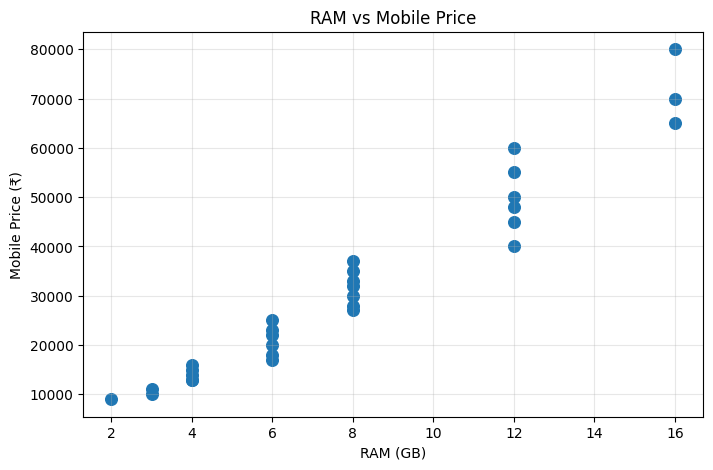

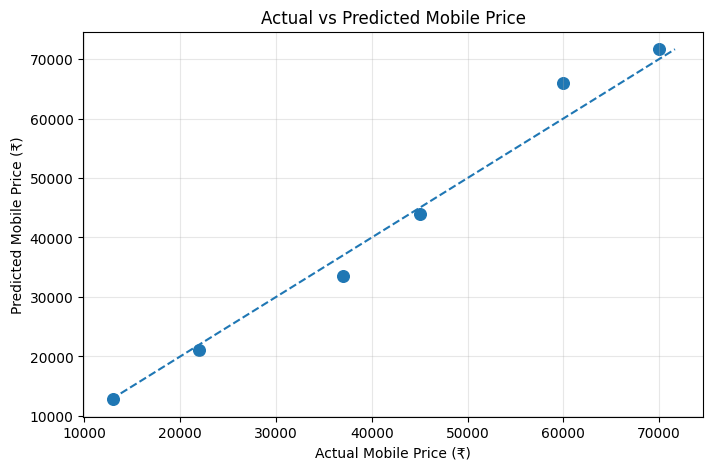

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Sample Mobile Dataset
# =========================================================

data = {
    "RAM": [
        2, 3, 4, 4, 6, 6, 8, 8, 12, 12,
        4, 6, 8, 8, 12, 16, 3, 4, 6, 8,
        12, 16, 6, 8, 12, 16, 4, 6, 8, 12
    ],

    "Storage": [
        32, 32, 64, 128, 128, 256, 128, 256, 256, 512,
        64, 128, 128, 256, 512, 512, 32, 64, 128, 256,
        256, 512, 128, 256, 512, 512, 64, 128, 256, 512
    ],

    "Battery": [
        4000, 4500, 5000, 5000, 4500, 5000, 5000, 4500, 5000, 5000,
        4500, 5000, 4800, 5000, 5200, 5000, 4000, 4500, 5000, 5000,
        4800, 5200, 5000, 5000, 5200, 5000, 4500, 5000, 5000, 5200
    ],

    "Camera": [
        12, 13, 16, 20, 24, 32, 48, 50, 64, 108,
        16, 24, 48, 50, 64, 108, 13, 16, 24, 48,
        50, 108, 32, 50, 64, 108, 20, 32, 48, 64
    ],

    "Price": [
        8999, 10999, 13999, 15999, 19999, 24999, 29999, 34999, 44999, 59999,
        12999, 17999, 27999, 32999, 49999, 69999, 9999, 12999, 16999, 26999,
        39999, 64999, 22999, 36999, 54999, 79999, 14999, 21999, 31999, 47999
    ]
}

df = pd.DataFrame(data)

print("\nMobile Dataset:")
print(df.head())


# =========================================================
# 2. Separate Input and Target
# =========================================================

X = df[["RAM", "Storage", "Battery", "Camera"]]
y = df["Price"]


# =========================================================
# 3. Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 4. Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)


# =========================================================
# 5. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 6. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL EVALUATION ==========")

print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.2f}")


# =========================================================
# 7. Model Coefficients
# =========================================================

print("\n========== MODEL COEFFICIENTS ==========")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:,.2f}")

print(f"Intercept: {model.intercept_:,.2f}")


# =========================================================
# 8. Take User Input
# =========================================================

print("\n========== ENTER MOBILE DETAILS ==========")

# RAM
while True:
    try:
        ram = float(input("Enter RAM (GB): "))

        if 1 <= ram <= 24:
            break
        else:
            print("Please enter RAM between 1 and 24 GB.")

    except ValueError:
        print("Please enter a valid number.")


# Storage
while True:
    try:
        storage = int(input("Enter Storage (GB): "))

        if storage in [16, 32, 64, 128, 256, 512, 1024]:
            break
        else:
            print("Please enter storage as 16, 32, 64, 128, 256, 512 or 1024 GB.")

    except ValueError:
        print("Please enter a valid number.")


# Battery
while True:
    try:
        battery = int(input("Enter Battery Capacity (mAh): "))

        if 2000 <= battery <= 7000:
            break
        else:
            print("Please enter battery between 2000 and 7000 mAh.")

    except ValueError:
        print("Please enter a valid number.")


# Camera
while True:
    try:
        camera = float(input("Enter Main Camera (MP): "))

        if 5 <= camera <= 200:
            break
        else:
            print("Please enter camera between 5 and 200 MP.")

    except ValueError:
        print("Please enter a valid number.")


# =========================================================
# 9. Predict Mobile Price
# =========================================================

new_mobile = pd.DataFrame({
    "RAM": [ram],
    "Storage": [storage],
    "Battery": [battery],
    "Camera": [camera]
})

predicted_price = model.predict(new_mobile)[0]

# Prevent negative price
predicted_price = max(0, predicted_price)


# =========================================================
# 10. Price Category
# =========================================================

if predicted_price < 15000:
    category = "Budget Mobile"

elif predicted_price < 30000:
    category = "Mid-Range Mobile"

elif predicted_price < 50000:
    category = "Premium Mobile"

else:
    category = "Flagship Mobile"


# =========================================================
# 11. Display Result
# =========================================================

print("\n========================================")
print("       MOBILE PRICE PREDICTION")
print("========================================")

print(f"RAM              : {ram} GB")
print(f"Storage          : {storage} GB")
print(f"Battery          : {battery} mAh")
print(f"Camera           : {camera} MP")

print("----------------------------------------")

print(f"Predicted Price  : ₹{predicted_price:,.0f}")
print(f"Price Category   : {category}")

print("========================================")


# =========================================================
# 12. Graph 1 - RAM vs Price
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["RAM"],
    df["Price"],
    s=70
)

plt.xlabel("RAM (GB)")
plt.ylabel("Mobile Price (₹)")
plt.title("RAM vs Mobile Price")

plt.grid(True, alpha=0.3)

plt.show()


# =========================================================
# 13. Graph 2 - Actual vs Predicted
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=70
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Mobile Price (₹)")
plt.ylabel("Predicted Mobile Price (₹)")
plt.title("Actual vs Predicted Mobile Price")

plt.grid(True, alpha=0.3)

plt.show()

7. Hotel Room Price Prediction


========== HOTEL DATASET ==========
  Room_Type  Location_Score  Rating  Room_Price
0  Standard             6.2     3.2        1800
1  Standard             7.0     3.5        2200
2  Standard             7.5     3.8        2500
3  Standard             8.2     4.0        2900
4    Deluxe             6.5     3.5        3200
5    Deluxe             7.2     3.8        3600
6    Deluxe             8.0     4.1        4100
7    Deluxe             8.7     4.3        4700
8     Suite             6.8     3.8        5500
9     Suite             7.5     4.0        6200

========== MODEL EVALUATION ==========
MAE  : ₹867.73
MSE  : 868,969.09
RMSE : ₹932.19
R²   : 0.78

========== ENTER HOTEL DETAILS ==========
Enter Room Type (Standard/Deluxe/Suite): Deluxe
Enter Location Score (1-10): 9
Enter Hotel Rating (1-5): 5

       HOTEL ROOM PRICE PREDICTION
Room Type        : Deluxe
Location Score   : 9.0
Hotel Rating     : 5.0/5
----------------------------------------
Predicted Price  : ₹6,410
Price Ca

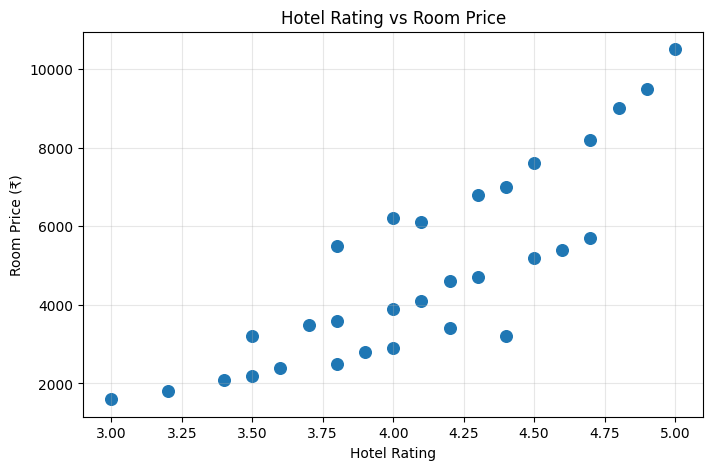

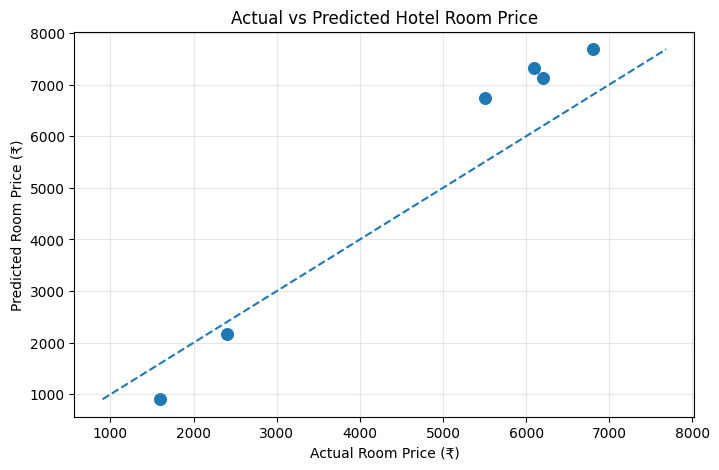

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Hotel Dataset
# =========================================================

data = {
    "Room_Type": [
        "Standard", "Standard", "Standard", "Standard",
        "Deluxe", "Deluxe", "Deluxe", "Deluxe",
        "Suite", "Suite", "Suite", "Suite",
        "Standard", "Deluxe", "Suite",
        "Standard", "Deluxe", "Suite",
        "Standard", "Deluxe", "Suite",
        "Standard", "Deluxe", "Suite",
        "Standard", "Deluxe", "Suite", "Standard",
        "Deluxe", "Suite"
    ],

    "Location_Score": [
        6.2, 7.0, 7.5, 8.2,
        6.5, 7.2, 8.0, 8.7,
        6.8, 7.5, 8.3, 9.2,
        8.8, 9.0, 9.5,
        5.8, 6.9, 7.8,
        7.8, 8.4, 8.9,
        6.5, 7.7, 8.6,
        9.0, 8.8, 9.7, 7.3,
        9.1, 9.8
    ],

    "Rating": [
        3.2, 3.5, 3.8, 4.0,
        3.5, 3.8, 4.1, 4.3,
        3.8, 4.0, 4.4, 4.7,
        4.2, 4.5, 4.8,
        3.0, 3.7, 4.1,
        3.9, 4.2, 4.5,
        3.4, 4.0, 4.3,
        4.4, 4.6, 4.9, 3.6,
        4.7, 5.0
    ],

    "Room_Price": [
        1800, 2200, 2500, 2900,
        3200, 3600, 4100, 4700,
        5500, 6200, 7000, 8200,
        3400, 5200, 9000,
        1600, 3500, 6100,
        2800, 4600, 7600,
        2100, 3900, 6800,
        3200, 5400, 9500, 2400,
        5700, 10500
    ]
}

df = pd.DataFrame(data)


# =========================================================
# 2. Display Dataset
# =========================================================

print("\n========== HOTEL DATASET ==========")
print(df.head(10))


# =========================================================
# 3. Separate Features and Target
# =========================================================

X = df[[
    "Room_Type",
    "Location_Score",
    "Rating"
]]

y = df["Room_Price"]


# =========================================================
# 4. Identify Categorical and Numerical Columns
# =========================================================

categorical_features = ["Room_Type"]

numerical_features = [
    "Location_Score",
    "Rating"
]


# =========================================================
# 5. Preprocessing
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# =========================================================
# 6. Create Machine Learning Pipeline
# =========================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


# =========================================================
# 7. Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 8. Train Model
# =========================================================

model.fit(X_train, y_train)


# =========================================================
# 9. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 10. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL EVALUATION ==========")

print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.2f}")


# =========================================================
# 11. Take User Input
# =========================================================

print("\n========== ENTER HOTEL DETAILS ==========")


# Room Type
while True:

    room_type = input(
        "Enter Room Type (Standard/Deluxe/Suite): "
    ).strip().title()

    if room_type in ["Standard", "Deluxe", "Suite"]:
        break

    print("Please enter Standard, Deluxe or Suite.")


# Location Score
while True:

    try:

        location_score = float(
            input("Enter Location Score (1-10): ")
        )

        if 1 <= location_score <= 10:
            break

        print("Location Score must be between 1 and 10.")

    except ValueError:

        print("Please enter a valid number.")


# Rating
while True:

    try:

        rating = float(
            input("Enter Hotel Rating (1-5): ")
        )

        if 1 <= rating <= 5:
            break

        print("Rating must be between 1 and 5.")

    except ValueError:

        print("Please enter a valid number.")


# =========================================================
# 12. Create New Hotel Data
# =========================================================

new_hotel = pd.DataFrame({
    "Room_Type": [room_type],
    "Location_Score": [location_score],
    "Rating": [rating]
})


# =========================================================
# 13. Predict Room Price
# =========================================================

predicted_price = model.predict(new_hotel)[0]

predicted_price = max(0, predicted_price)


# =========================================================
# 14. Price Category
# =========================================================

if predicted_price < 3000:

    category = "Budget Room"

elif predicted_price < 6000:

    category = "Mid-Range Room"

elif predicted_price < 9000:

    category = "Premium Room"

else:

    category = "Luxury Room"


# =========================================================
# 15. Display Final Prediction
# =========================================================

print("\n========================================")
print("       HOTEL ROOM PRICE PREDICTION")
print("========================================")

print(f"Room Type        : {room_type}")
print(f"Location Score   : {location_score}")
print(f"Hotel Rating     : {rating}/5")

print("----------------------------------------")

print(f"Predicted Price  : ₹{predicted_price:,.0f}")
print(f"Price Category   : {category}")

print("========================================")


# =========================================================
# 16. Graph 1 - Rating vs Room Price
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Rating"],
    df["Room_Price"],
    s=70
)

plt.xlabel("Hotel Rating")
plt.ylabel("Room Price (₹)")
plt.title("Hotel Rating vs Room Price")

plt.grid(True, alpha=0.3)

plt.show()


# =========================================================
# 17. Graph 2 - Actual vs Predicted
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=70
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Room Price (₹)")
plt.ylabel("Predicted Room Price (₹)")
plt.title("Actual vs Predicted Hotel Room Price")

plt.grid(True, alpha=0.3)

plt.show()

8. Flight Ticket Price Prediction


========== FLIGHT DATASET ==========
   Distance  Duration     Stops  Ticket_Price
0       300       1.0  Non-stop          3500
1       450       1.3  Non-stop          4200
2       600       1.5  Non-stop          4800
3       750       1.8    1 Stop          6200
4       900       2.0    1 Stop          7000
5      1100       2.4  Non-stop          8500
6      1300       2.7    1 Stop          9800
7      1500       3.0    1 Stop         11000
8      1700       3.3   2 Stops         12500
9      1900       3.6    1 Stop         13500

========== MODEL EVALUATION ==========
MAE  : ₹367.69
MSE  : 222,797.09
RMSE : ₹472.01
R²   : 0.99

========== ENTER FLIGHT DETAILS ==========
Enter Distance (km): 2500
Enter Duration (hours): 18
Enter Stops (Non-stop/1 Stop/2 Stops): 2
Please enter Non-stop, 1 Stop or 2 Stops.
Enter Stops (Non-stop/1 Stop/2 Stops): 2 stops

       FLIGHT TICKET PRICE PREDICTION
Distance         : 2,500 km
Duration         : 18.0 hours
Stops            : 2 Stops
-----

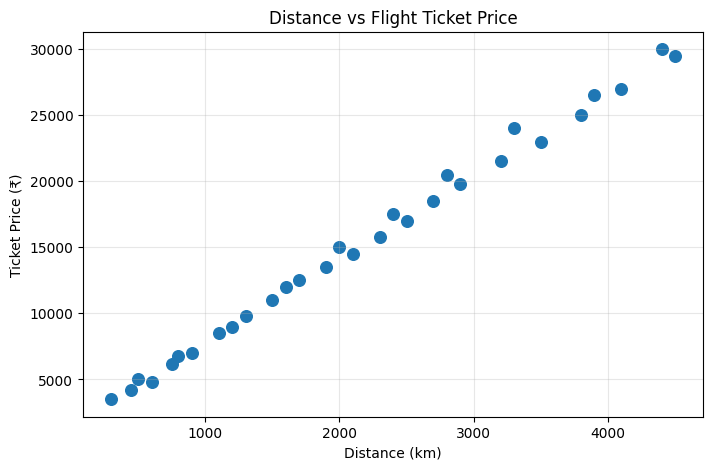

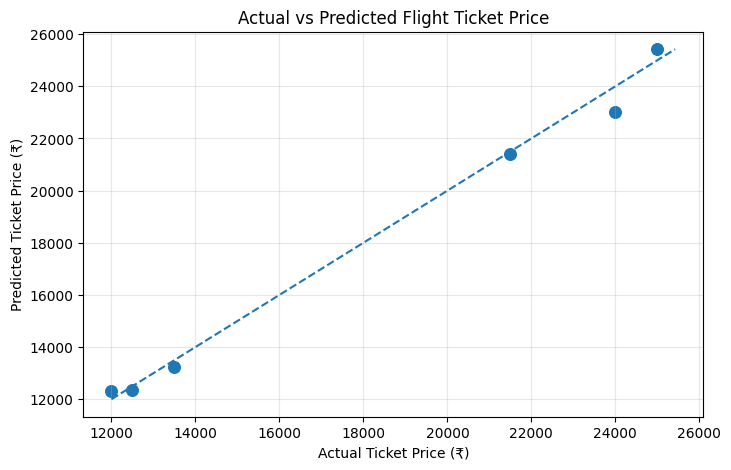

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Flight Dataset
# =========================================================

data = {
    "Distance": [
        300, 450, 600, 750, 900,
        1100, 1300, 1500, 1700, 1900,
        2100, 2300, 2500, 2700, 2900,
        3200, 3500, 3800, 4100, 4500,
        500, 800, 1200, 1600, 2000,
        2400, 2800, 3300, 3900, 4400
    ],

    "Duration": [
        1.0, 1.3, 1.5, 1.8, 2.0,
        2.4, 2.7, 3.0, 3.3, 3.6,
        4.0, 4.3, 4.6, 5.0, 5.3,
        5.8, 6.2, 6.7, 7.1, 7.8,
        1.5, 2.1, 2.8, 3.5, 4.1,
        4.8, 5.5, 6.3, 7.0, 8.0
    ],

    "Stops": [
        "Non-stop", "Non-stop", "Non-stop", "1 Stop", "1 Stop",
        "Non-stop", "1 Stop", "1 Stop", "2 Stops", "1 Stop",
        "Non-stop", "1 Stop", "1 Stop", "2 Stops", "1 Stop",
        "Non-stop", "1 Stop", "2 Stops", "1 Stop", "2 Stops",
        "Non-stop", "1 Stop", "Non-stop", "1 Stop", "2 Stops",
        "1 Stop", "2 Stops", "1 Stop", "2 Stops", "2 Stops"
    ],

    "Ticket_Price": [
        3500, 4200, 4800, 6200, 7000,
        8500, 9800, 11000, 12500, 13500,
        14500, 15800, 17000, 18500, 19800,
        21500, 23000, 25000, 27000, 29500,
        5000, 6800, 9000, 12000, 15000,
        17500, 20500, 24000, 26500, 30000
    ]
}

df = pd.DataFrame(data)


# =========================================================
# 2. Display Dataset
# =========================================================

print("\n========== FLIGHT DATASET ==========")
print(df.head(10))


# =========================================================
# 3. Separate Features and Target
# =========================================================

X = df[
    [
        "Distance",
        "Duration",
        "Stops"
    ]
]

y = df["Ticket_Price"]


# =========================================================
# 4. Define Categorical Feature
# =========================================================

categorical_features = ["Stops"]

numerical_features = [
    "Distance",
    "Duration"
]


# =========================================================
# 5. Preprocessing
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# =========================================================
# 6. Create ML Pipeline
# =========================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


# =========================================================
# 7. Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 8. Train Model
# =========================================================

model.fit(X_train, y_train)


# =========================================================
# 9. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 10. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL EVALUATION ==========")

print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.2f}")


# =========================================================
# 11. User Input
# =========================================================

print("\n========== ENTER FLIGHT DETAILS ==========")


# Distance
while True:

    try:

        distance = float(
            input("Enter Distance (km): ")
        )

        if 100 <= distance <= 10000:
            break

        print("Distance must be between 100 and 10,000 km.")

    except ValueError:

        print("Please enter a valid number.")


# Duration
while True:

    try:

        duration = float(
            input("Enter Duration (hours): ")
        )

        if 0.5 <= duration <= 20:
            break

        print("Duration must be between 0.5 and 20 hours.")

    except ValueError:

        print("Please enter a valid number.")


# Stops
while True:

    stops = input(
        "Enter Stops (Non-stop/1 Stop/2 Stops): "
    ).strip().title()

    if stops in ["Non-Stop", "1 Stop", "2 Stops"]:
        break

    print("Please enter Non-stop, 1 Stop or 2 Stops.")

# Fix capitalization
if stops == "Non-Stop":
    stops = "Non-stop"


# =========================================================
# 12. Create New Flight Data
# =========================================================

new_flight = pd.DataFrame({
    "Distance": [distance],
    "Duration": [duration],
    "Stops": [stops]
})


# =========================================================
# 13. Predict Ticket Price
# =========================================================

predicted_price = model.predict(new_flight)[0]

predicted_price = max(0, predicted_price)


# =========================================================
# 14. Ticket Price Category
# =========================================================

if predicted_price < 5000:

    category = "Budget Flight"

elif predicted_price < 10000:

    category = "Economy Flight"

elif predicted_price < 20000:

    category = "Premium Flight"

else:

    category = "Expensive Flight"


# =========================================================
# 15. Display Prediction
# =========================================================

print("\n========================================")
print("       FLIGHT TICKET PRICE PREDICTION")
print("========================================")

print(f"Distance         : {distance:,.0f} km")
print(f"Duration         : {duration:.1f} hours")
print(f"Stops            : {stops}")

print("----------------------------------------")

print(f"Predicted Price  : ₹{predicted_price:,.0f}")
print(f"Price Category   : {category}")

print("========================================")


# =========================================================
# 16. Graph 1 - Distance vs Ticket Price
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Distance"],
    df["Ticket_Price"],
    s=70
)

plt.xlabel("Distance (km)")
plt.ylabel("Ticket Price (₹)")
plt.title("Distance vs Flight Ticket Price")

plt.grid(True, alpha=0.3)

plt.show()


# =========================================================
# 17. Graph 2 - Actual vs Predicted
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=70
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Ticket Price (₹)")
plt.ylabel("Predicted Ticket Price (₹)")
plt.title("Actual vs Predicted Flight Ticket Price")

plt.grid(True, alpha=0.3)

plt.show()

9. Shopping Bill Prediction


========== SHOPPING DATASET ==========
   Items  Quantity  Discount  Total_Bill
0      2         3         0         850
1      3         5         5        1250
2      4         6        10        1680
3      5         8         0        2100
4      6        10         5        2750
5      7        12        10        3100
6      8        14        15        3600
7      9        15         5        4050
8     10        18        20        4500
9     12        20        10        5200

========== MODEL EVALUATION ==========
MAE  : ₹103.70
MSE  : 13,047.27
RMSE : ₹114.22
R²   : 0.99

========== MODEL COEFFICIENTS ==========
Items: ₹125.79
Quantity: ₹162.37
Discount: ₹6.24
Intercept: ₹234.32

========== ENTER SHOPPING DETAILS ==========
Enter Number of Items: 2
Enter Total Quantity: 10
Enter Discount (%): 50

       SHOPPING BILL PREDICTION
Number of Items  : 2
Total Quantity   : 10
Discount         : 50.0%
----------------------------------------
Predicted Bill   : ₹2,422
Bill Category

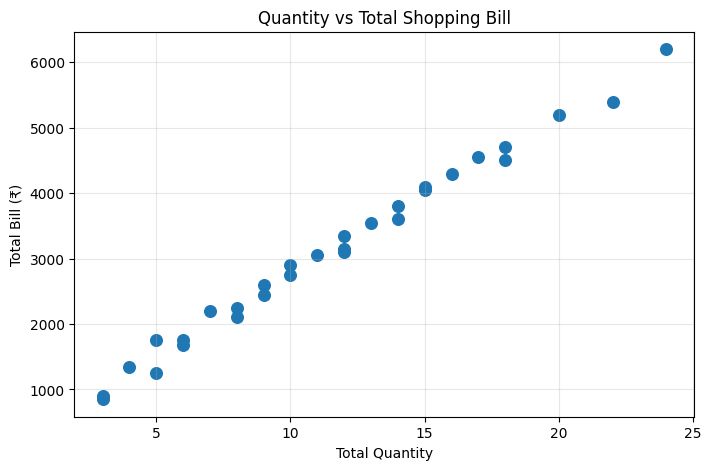

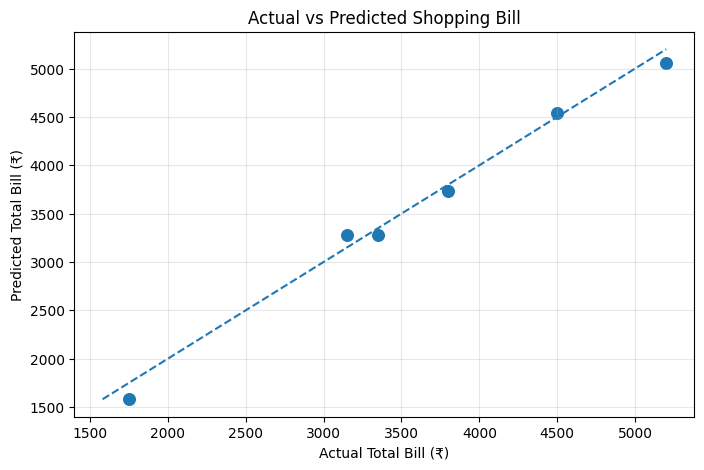

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Shopping Dataset
# =========================================================

data = {
    "Items": [
        2, 3, 4, 5, 6,
        7, 8, 9, 10, 12,
        3, 5, 7, 9, 11,
        4, 6, 8, 10, 14,
        2, 4, 6, 8, 12,
        5, 7, 9, 11, 15
    ],

    "Quantity": [
        3, 5, 6, 8, 10,
        12, 14, 15, 18, 20,
        4, 7, 10, 13, 16,
        5, 9, 12, 15, 22,
        3, 6, 9, 12, 18,
        8, 11, 14, 17, 24
    ],

    "Discount": [
        0, 5, 10, 0, 5,
        10, 15, 5, 20, 10,
        0, 10, 5, 15, 20,
        5, 10, 15, 20, 10,
        0, 5, 10, 15, 20,
        5, 10, 15, 20, 25
    ],

    "Total_Bill": [
        850, 1250, 1680, 2100, 2750,
        3100, 3600, 4050, 4500, 5200,
        1350, 2200, 2900, 3550, 4300,
        1750, 2600, 3350, 4100, 5400,
        900, 1750, 2450, 3150, 4700,
        2250, 3050, 3800, 4550, 6200
    ]
}

df = pd.DataFrame(data)


# =========================================================
# 2. Display Dataset
# =========================================================

print("\n========== SHOPPING DATASET ==========")
print(df.head(10))


# =========================================================
# 3. Separate Features and Target
# =========================================================

X = df[
    [
        "Items",
        "Quantity",
        "Discount"
    ]
]

y = df["Total_Bill"]


# =========================================================
# 4. Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 5. Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)


# =========================================================
# 6. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 7. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL EVALUATION ==========")

print(f"MAE  : ₹{mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.2f}")


# =========================================================
# 8. Display Coefficients
# =========================================================

print("\n========== MODEL COEFFICIENTS ==========")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: ₹{coefficient:,.2f}")

print(f"Intercept: ₹{model.intercept_:,.2f}")


# =========================================================
# 9. Take User Input
# =========================================================

print("\n========== ENTER SHOPPING DETAILS ==========")


# Number of Items
while True:

    try:

        items = int(
            input("Enter Number of Items: ")
        )

        if 1 <= items <= 50:
            break

        print("Items must be between 1 and 50.")

    except ValueError:

        print("Please enter a valid whole number.")


# Quantity
while True:

    try:

        quantity = int(
            input("Enter Total Quantity: ")
        )

        if 1 <= quantity <= 100:
            break

        print("Quantity must be between 1 and 100.")

    except ValueError:

        print("Please enter a valid whole number.")


# Discount
while True:

    try:

        discount = float(
            input("Enter Discount (%): ")
        )

        if 0 <= discount <= 50:
            break

        print("Discount must be between 0% and 50%.")

    except ValueError:

        print("Please enter a valid number.")


# =========================================================
# 10. Create New Shopping Data
# =========================================================

new_shopping = pd.DataFrame({
    "Items": [items],
    "Quantity": [quantity],
    "Discount": [discount]
})


# =========================================================
# 11. Predict Total Bill
# =========================================================

predicted_bill = model.predict(new_shopping)[0]

predicted_bill = max(0, predicted_bill)


# =========================================================
# 12. Bill Category
# =========================================================

if predicted_bill < 1500:

    category = "Small Shopping"

elif predicted_bill < 3000:

    category = "Medium Shopping"

elif predicted_bill < 5000:

    category = "Large Shopping"

else:

    category = "Heavy Shopping"


# =========================================================
# 13. Display Final Prediction
# =========================================================

print("\n========================================")
print("       SHOPPING BILL PREDICTION")
print("========================================")

print(f"Number of Items  : {items}")
print(f"Total Quantity   : {quantity}")
print(f"Discount         : {discount:.1f}%")

print("----------------------------------------")

print(f"Predicted Bill   : ₹{predicted_bill:,.0f}")
print(f"Bill Category    : {category}")

print("========================================")


# =========================================================
# 14. Graph 1 - Quantity vs Total Bill
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Quantity"],
    df["Total_Bill"],
    s=70
)

plt.xlabel("Total Quantity")
plt.ylabel("Total Bill (₹)")
plt.title("Quantity vs Total Shopping Bill")

plt.grid(True, alpha=0.3)

plt.show()


# =========================================================
# 15. Graph 2 - Actual vs Predicted
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=70
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Total Bill (₹)")
plt.ylabel("Predicted Total Bill (₹)")
plt.title("Actual vs Predicted Shopping Bill")

plt.grid(True, alpha=0.3)

plt.show()

10. Food Delivery Cost Prediction


========== FOOD DELIVERY DATASET ==========
   Distance  Order_Value  Delivery_Time  Delivery_Fee
0         1          250             20            35
1         2          400             22            40
2         3          550             25            45
3         4          700             28            50
4         5          900             30            55
5         6         1100             34            65
6         7         1300             36            70
7         8         1500             40            75
8         9         1800             43            82
9        10         2000             47            90

========== MODEL EVALUATION ==========
MAE  : ₹2.15
MSE  : 6.36
RMSE : ₹2.52
R²   : 0.87

========== MODEL COEFFICIENTS ==========
Distance: ₹2.22
Order_Value: ₹0.01
Delivery_Time: ₹0.99
Intercept: ₹8.89

========== ENTER ORDER DETAILS ==========
Enter Delivery Distance (km): 15
Enter Order Value (₹): 842
Enter Expected Delivery Time (minutes): 50

       FO

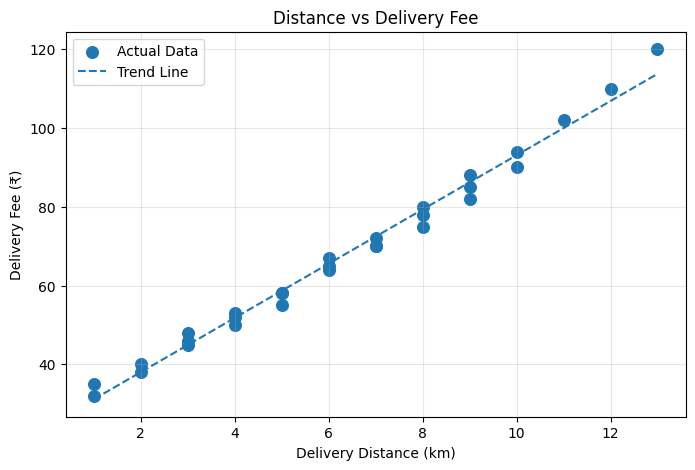

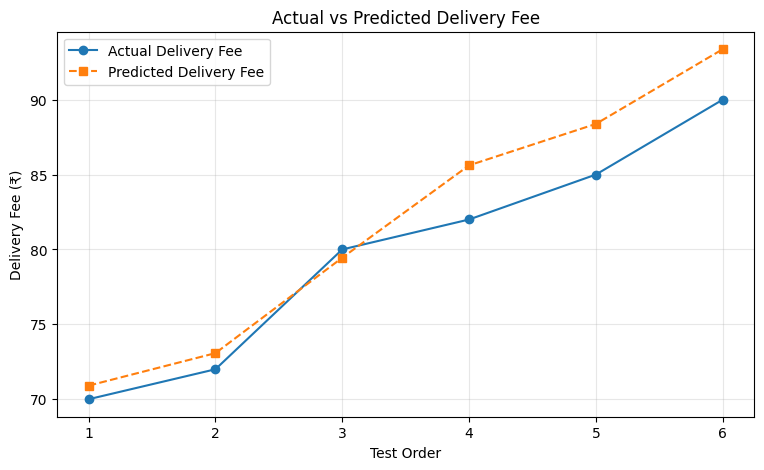

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Food Delivery Dataset
# =========================================================

data = {
    "Distance": [
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10,
        2, 3, 4, 5, 6,
        7, 8, 9, 10, 12,
        1, 3, 5, 7, 9,
        4, 6, 8, 11, 13
    ],

    "Order_Value": [
        250, 400, 550, 700, 900,
        1100, 1300, 1500, 1800, 2000,
        350, 600, 800, 1000, 1200,
        1400, 1600, 1900, 2200, 2500,
        300, 650, 950, 1250, 1700,
        750, 1150, 1550, 2100, 2800
    ],

    "Delivery_Time": [
        20, 22, 25, 28, 30,
        34, 36, 40, 43, 47,
        21, 26, 29, 32, 35,
        38, 42, 45, 49, 55,
        19, 27, 31, 37, 44,
        29, 34, 41, 50, 58
    ],

    "Delivery_Fee": [
        35, 40, 45, 50, 55,
        65, 70, 75, 82, 90,
        38, 46, 52, 58, 64,
        72, 78, 85, 94, 110,
        32, 48, 58, 70, 88,
        53, 67, 80, 102, 120
    ]
}

df = pd.DataFrame(data)


# =========================================================
# 2. Display Dataset
# =========================================================

print("\n========== FOOD DELIVERY DATASET ==========")
print(df.head(10))


# =========================================================
# 3. Separate Features and Target
# =========================================================

X = df[
    [
        "Distance",
        "Order_Value",
        "Delivery_Time"
    ]
]

y = df["Delivery_Fee"]


# =========================================================
# 4. Train-Test Split
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 5. Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)


# =========================================================
# 6. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 7. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL EVALUATION ==========")

print(f"MAE  : ₹{mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"R²   : {r2:.2f}")


# =========================================================
# 8. Display Coefficients
# =========================================================

print("\n========== MODEL COEFFICIENTS ==========")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: ₹{coefficient:.2f}")

print(f"Intercept: ₹{model.intercept_:.2f}")


# =========================================================
# 9. Take User Input
# =========================================================

print("\n========== ENTER ORDER DETAILS ==========")


# Distance
while True:

    try:

        distance = float(
            input("Enter Delivery Distance (km): ")
        )

        if 0.5 <= distance <= 50:
            break

        print("Distance must be between 0.5 and 50 km.")

    except ValueError:

        print("Please enter a valid number.")


# Order Value
while True:

    try:

        order_value = float(
            input("Enter Order Value (₹): ")
        )

        if 50 <= order_value <= 10000:
            break

        print("Order value must be between ₹50 and ₹10,000.")

    except ValueError:

        print("Please enter a valid number.")


# Delivery Time
while True:

    try:

        delivery_time = float(
            input("Enter Expected Delivery Time (minutes): ")
        )

        if 10 <= delivery_time <= 180:
            break

        print("Delivery time must be between 10 and 180 minutes.")

    except ValueError:

        print("Please enter a valid number.")


# =========================================================
# 10. Create New Order
# =========================================================

new_order = pd.DataFrame({
    "Distance": [distance],
    "Order_Value": [order_value],
    "Delivery_Time": [delivery_time]
})


# =========================================================
# 11. Predict Delivery Fee
# =========================================================

predicted_fee = model.predict(new_order)[0]

predicted_fee = max(0, predicted_fee)


# =========================================================
# 12. Delivery Fee Category
# =========================================================

if predicted_fee < 50:

    category = "Low Delivery Fee"

elif predicted_fee < 80:

    category = "Moderate Delivery Fee"

elif predicted_fee < 110:

    category = "High Delivery Fee"

else:

    category = "Very High Delivery Fee"


# =========================================================
# 13. Display Final Prediction
# =========================================================

print("\n========================================")
print("       FOOD DELIVERY COST PREDICTION")
print("========================================")

print(f"Distance         : {distance:.1f} km")
print(f"Order Value      : ₹{order_value:,.0f}")
print(f"Delivery Time    : {delivery_time:.0f} minutes")

print("----------------------------------------")

print(f"Predicted Fee    : ₹{predicted_fee:.2f}")
print(f"Fee Category     : {category}")

print("========================================")


# =========================================================
# 14. GRAPH 1
# Distance vs Delivery Fee + Trend Line
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Distance"],
    df["Delivery_Fee"],
    s=70,
    label="Actual Data"
)

# Calculate trend line using simple regression
trend_model = LinearRegression()

trend_model.fit(
    df[["Distance"]],
    df["Delivery_Fee"]
)

distance_range = pd.DataFrame({
    "Distance": sorted(df["Distance"].unique())
})

trend_prediction = trend_model.predict(distance_range)

plt.plot(
    distance_range["Distance"],
    trend_prediction,
    linestyle="--",
    label="Trend Line"
)

plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Fee (₹)")
plt.title("Distance vs Delivery Fee")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


# =========================================================
# 15. GRAPH 2
# Actual vs Predicted - Line Graph
# =========================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).sort_values("Actual").reset_index(drop=True)


plt.figure(figsize=(9, 5))

plt.plot(
    comparison.index + 1,
    comparison["Actual"],
    marker="o",
    label="Actual Delivery Fee"
)

plt.plot(
    comparison.index + 1,
    comparison["Predicted"],
    marker="s",
    linestyle="--",
    label="Predicted Delivery Fee"
)

plt.xlabel("Test Order")
plt.ylabel("Delivery Fee (₹)")
plt.title("Actual vs Predicted Delivery Fee")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

11. Taxi Fare Prediction

Taxi Fare Dataset:

   Distance  Duration  Passengers  Fare
0       2.0         8           1    80
1       3.0        12           2   105
2       5.0        18           1   145
3       7.0        25           3   185
4      10.0        32           2   245

Dataset Shape: (30, 4)

========== MODEL EVALUATION ==========
MAE  : 1.67
MSE  : 5.18
RMSE : 2.28
R²   : 1.0

========== MODEL COEFFICIENTS ==========
Distance Coefficient   : 14.58
Duration Coefficient   : 1.71
Passengers Coefficient : 0.91
Intercept              : 39.29

========== TAXI FARE PREDICTION ==========
Enter Distance (km): 200
Distance must be between 0.5 and 100 km.
Enter Distance (km): 100
Enter Duration (minutes): 60
Enter Number of Passengers: 2

========== PREDICTION RESULT ==========
Distance   : 100.0 km
Duration   : 60.0 minutes
Passengers : 2

Predicted Taxi Fare: ₹1602.12
Fare Category       : Very High Fare


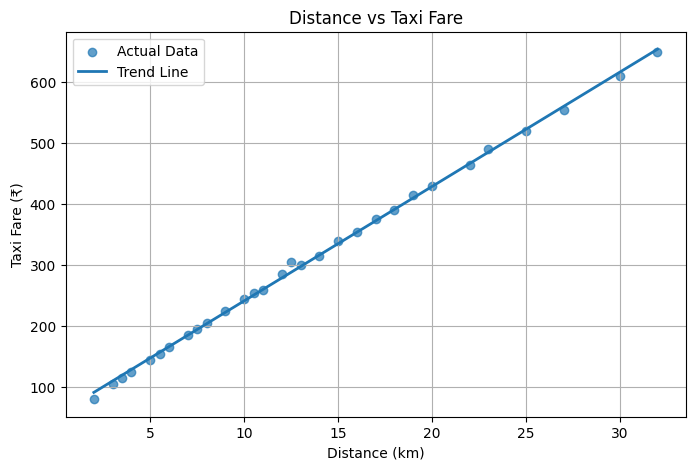

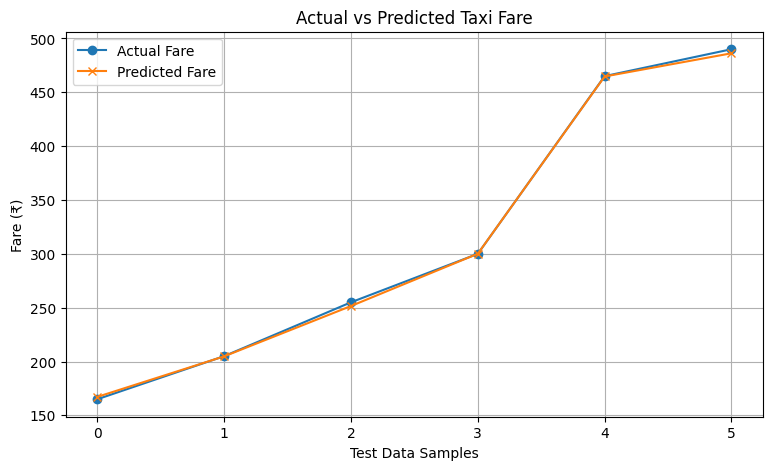

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Sample Taxi Dataset
# =========================================================

data = {
    "Distance": [
        2, 3, 5, 7, 10, 12, 15, 4, 6, 8,
        11, 14, 18, 20, 9, 13, 16, 22, 25, 30,
        3.5, 5.5, 7.5, 10.5, 12.5, 17, 19, 23, 27, 32
    ],

    "Duration": [
        8, 12, 18, 25, 32, 38, 45, 15, 22, 28,
        35, 42, 50, 55, 30, 40, 48, 60, 68, 75,
        14, 20, 27, 34, 40, 52, 58, 63, 72, 82
    ],

    "Passengers": [
        1, 2, 1, 3, 2, 1, 4, 2, 3, 1,
        2, 4, 3, 1, 2, 3, 4, 2, 1, 4,
        1, 2, 3, 1, 4, 2, 3, 4, 2, 3
    ],

    "Fare": [
        80, 105, 145, 185, 245, 285, 340, 125, 165, 205,
        260, 315, 390, 430, 225, 300, 355, 465, 520, 610,
        115, 155, 195, 255, 305, 375, 415, 490, 555, 650
    ]
}

df = pd.DataFrame(data)

print("Taxi Fare Dataset:\n")
print(df.head())

print("\nDataset Shape:", df.shape)


# =========================================================
# 2. Define Features and Target
# =========================================================

X = df[["Distance", "Duration", "Passengers"]]
y = df["Fare"]


# =========================================================
# 3. Split Data
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 4. Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)


# =========================================================
# 5. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 6. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))


# =========================================================
# 7. Model Coefficients
# =========================================================

print("\n========== MODEL COEFFICIENTS ==========")

print("Distance Coefficient   :", round(model.coef_[0], 2))
print("Duration Coefficient   :", round(model.coef_[1], 2))
print("Passengers Coefficient :", round(model.coef_[2], 2))
print("Intercept              :", round(model.intercept_, 2))


# =========================================================
# 8. Take User Input
# =========================================================

print("\n========== TAXI FARE PREDICTION ==========")

# Distance
while True:
    try:
        distance = float(input("Enter Distance (km): "))

        if 0.5 <= distance <= 100:
            break
        else:
            print("Distance must be between 0.5 and 100 km.")

    except ValueError:
        print("Please enter a valid number.")


# Duration
while True:
    try:
        duration = float(input("Enter Duration (minutes): "))

        if 5 <= duration <= 300:
            break
        else:
            print("Duration must be between 5 and 300 minutes.")

    except ValueError:
        print("Please enter a valid number.")


# Passengers
while True:
    try:
        passengers = int(input("Enter Number of Passengers: "))

        if 1 <= passengers <= 6:
            break
        else:
            print("Passengers must be between 1 and 6.")

    except ValueError:
        print("Please enter a valid whole number.")


# =========================================================
# 9. Predict Fare
# =========================================================

new_taxi = pd.DataFrame({
    "Distance": [distance],
    "Duration": [duration],
    "Passengers": [passengers]
})

predicted_fare = model.predict(new_taxi)[0]

# Fare should not be negative
predicted_fare = max(0, predicted_fare)


# =========================================================
# 10. Fare Category
# =========================================================

if predicted_fare < 150:
    category = "Low Fare"
elif predicted_fare < 300:
    category = "Moderate Fare"
elif predicted_fare < 500:
    category = "High Fare"
else:
    category = "Very High Fare"


# =========================================================
# 11. Display Result
# =========================================================

print("\n========== PREDICTION RESULT ==========")

print(f"Distance   : {distance} km")
print(f"Duration   : {duration} minutes")
print(f"Passengers : {passengers}")

print(f"\nPredicted Taxi Fare: ₹{predicted_fare:.2f}")
print("Fare Category       :", category)


# =========================================================
# 12. GRAPH 1
# Distance vs Fare
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Distance"],
    df["Fare"],
    alpha=0.7,
    label="Actual Data"
)

# Trend line using distance only
trend_model = LinearRegression()

trend_model.fit(
    df[["Distance"]],
    df["Fare"]
)

distance_range = pd.DataFrame({
    "Distance": sorted(df["Distance"])
})

trend_prediction = trend_model.predict(distance_range)

plt.plot(
    distance_range["Distance"],
    trend_prediction,
    linewidth=2,
    label="Trend Line"
)

plt.xlabel("Distance (km)")
plt.ylabel("Taxi Fare (₹)")
plt.title("Distance vs Taxi Fare")
plt.legend()
plt.grid(True)

plt.show()


# =========================================================
# 13. GRAPH 2
# Actual vs Predicted Fare
# =========================================================

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison = comparison.sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(9, 5))

plt.plot(
    comparison["Actual"],
    marker="o",
    label="Actual Fare"
)

plt.plot(
    comparison["Predicted"],
    marker="x",
    label="Predicted Fare"
)

plt.xlabel("Test Data Samples")
plt.ylabel("Fare (₹)")
plt.title("Actual vs Predicted Taxi Fare")

plt.legend()
plt.grid(True)

plt.show()


12. Fuel Consumption Prediction

Fuel Consumption Dataset:

   Distance  Engine_Size  Vehicle_Weight  Fuel_Used
0        50          1.2            1000        4.1
1        80          1.4            1100        6.0
2       120          1.5            1200        8.5
3       150          1.6            1250       10.2
4       200          1.8            1350       13.5

Dataset Shape: (30, 4)

========== MODEL EVALUATION ==========
MAE  : 0.77
MSE  : 0.81
RMSE : 0.9
R²   : 0.98

========== MODEL COEFFICIENTS ==========
Distance Coefficient       : 0.0624
Engine Size Coefficient    : 17.0467
Vehicle Weight Coefficient : -0.0239
Intercept                  : 3.3943

========== FUEL CONSUMPTION PREDICTION ==========
Enter Distance (km): 62
Enter Engine Size (L): L
Please enter a valid number.
Enter Engine Size (L): 0.9
Enter Vehicle Weight (kg): 50
Vehicle weight must be between 500 and 4000 kg.
Enter Vehicle Weight (kg): 900

========== PREDICTION RESULT ==========
Distance       : 62.0 km
Engine Size    : 0.9 L
Vehicle 

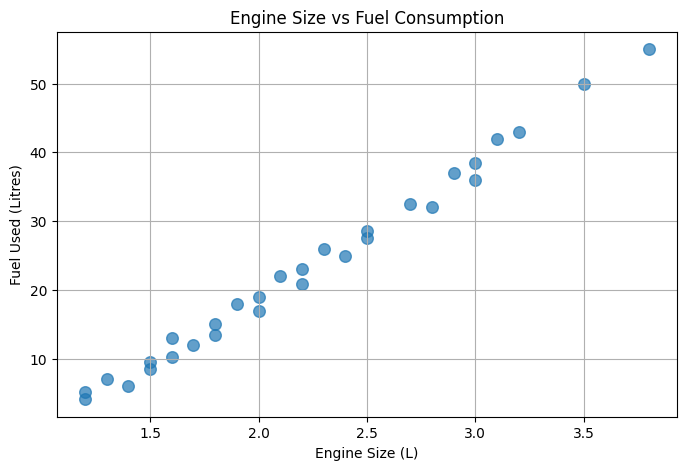

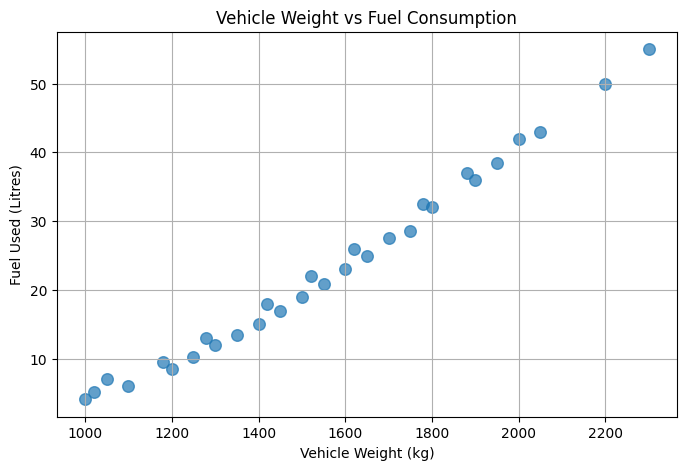

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Sample Dataset
# =========================================================

data = {
    "Distance": [
        50, 80, 120, 150, 200, 250, 300, 350, 400, 450,
        100, 180, 220, 280, 330, 380, 420, 500, 550, 600,
        70, 140, 190, 260, 310, 360, 430, 480, 520, 650
    ],

    "Engine_Size": [
        1.2, 1.4, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.5, 3.0,
        1.3, 1.7, 1.8, 2.0, 2.2, 2.5, 2.8, 3.0, 3.2, 3.5,
        1.2, 1.5, 1.6, 1.9, 2.1, 2.3, 2.7, 2.9, 3.1, 3.8
    ],

    "Vehicle_Weight": [
        1000, 1100, 1200, 1250, 1350, 1450, 1550, 1650, 1750, 1900,
        1050, 1300, 1400, 1500, 1600, 1700, 1800, 1950, 2050, 2200,
        1020, 1180, 1280, 1420, 1520, 1620, 1780, 1880, 2000, 2300
    ],

    "Fuel_Used": [
        4.1, 6.0, 8.5, 10.2, 13.5, 17.0, 20.8, 25.0, 28.5, 36.0,
        7.0, 12.0, 15.0, 19.0, 23.0, 27.5, 32.0, 38.5, 43.0, 50.0,
        5.2, 9.5, 13.0, 18.0, 22.0, 26.0, 32.5, 37.0, 42.0, 55.0
    ]
}

df = pd.DataFrame(data)

print("Fuel Consumption Dataset:\n")
print(df.head())

print("\nDataset Shape:", df.shape)


# =========================================================
# 2. Define Features and Target
# =========================================================

X = df[["Distance", "Engine_Size", "Vehicle_Weight"]]
y = df["Fuel_Used"]


# =========================================================
# 3. Split Dataset
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 4. Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)


# =========================================================
# 5. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 6. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))


# =========================================================
# 7. Model Coefficients
# =========================================================

print("\n========== MODEL COEFFICIENTS ==========")

print("Distance Coefficient       :", round(model.coef_[0], 4))
print("Engine Size Coefficient    :", round(model.coef_[1], 4))
print("Vehicle Weight Coefficient :", round(model.coef_[2], 4))
print("Intercept                  :", round(model.intercept_, 4))


# =========================================================
# 8. User Input
# =========================================================

print("\n========== FUEL CONSUMPTION PREDICTION ==========")

# Distance
while True:
    try:
        distance = float(input("Enter Distance (km): "))

        if 1 <= distance <= 2000:
            break
        else:
            print("Distance must be between 1 and 2000 km.")

    except ValueError:
        print("Please enter a valid number.")


# Engine Size
while True:
    try:
        engine_size = float(input("Enter Engine Size (L): "))

        if 0.8 <= engine_size <= 8.0:
            break
        else:
            print("Engine size must be between 0.8 and 8.0 L.")

    except ValueError:
        print("Please enter a valid number.")


# Vehicle Weight
while True:
    try:
        vehicle_weight = float(input("Enter Vehicle Weight (kg): "))

        if 500 <= vehicle_weight <= 4000:
            break
        else:
            print("Vehicle weight must be between 500 and 4000 kg.")

    except ValueError:
        print("Please enter a valid number.")


# =========================================================
# 9. Predict Fuel Used
# =========================================================

new_vehicle = pd.DataFrame({
    "Distance": [distance],
    "Engine_Size": [engine_size],
    "Vehicle_Weight": [vehicle_weight]
})

predicted_fuel = model.predict(new_vehicle)[0]

# Fuel cannot be negative
predicted_fuel = max(0, predicted_fuel)


# =========================================================
# 10. Fuel Consumption Category
# =========================================================

if predicted_fuel < 10:
    category = "Low Fuel Consumption"
elif predicted_fuel < 20:
    category = "Moderate Fuel Consumption"
elif predicted_fuel < 35:
    category = "High Fuel Consumption"
else:
    category = "Very High Fuel Consumption"


# =========================================================
# 11. Display Result
# =========================================================

print("\n========== PREDICTION RESULT ==========")

print(f"Distance       : {distance} km")
print(f"Engine Size    : {engine_size} L")
print(f"Vehicle Weight : {vehicle_weight} kg")

print(f"\nPredicted Fuel Used: {predicted_fuel:.2f} Litres")
print("Consumption Level  :", category)


# =========================================================
# 12. GRAPH 1
# Engine Size vs Fuel Used
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Engine_Size"],
    df["Fuel_Used"],
    s=70,
    alpha=0.7
)

plt.xlabel("Engine Size (L)")
plt.ylabel("Fuel Used (Litres)")
plt.title("Engine Size vs Fuel Consumption")
plt.grid(True)

plt.show()


# =========================================================
# 13. GRAPH 2
# Vehicle Weight vs Fuel Used
# =========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Vehicle_Weight"],
    df["Fuel_Used"],
    s=70,
    alpha=0.7
)

plt.xlabel("Vehicle Weight (kg)")
plt.ylabel("Fuel Used (Litres)")
plt.title("Vehicle Weight vs Fuel Consumption")
plt.grid(True)

plt.show()

13. Temperature Prediction

Weather Dataset:

   Humidity  Pressure  Wind_Speed  Temperature
0        30      1015           5           32
1        35      1012           6           31
2        40      1010           8           30
3        45      1008          10           29
4        50      1005           7           27

Dataset Shape: (30, 4)

========== MODEL EVALUATION ==========
MAE  : 0.63
MSE  : 0.49
RMSE : 0.7
R²   : 0.95

========== MODEL COEFFICIENTS ==========
Humidity Coefficient   : -0.1846
Pressure Coefficient   : 0.1666
Wind Speed Coefficient : -0.0525
Intercept              : -130.2055

========== TEMPERATURE PREDICTION ==========
Enter Humidity (%): 85
Enter Atmospheric Pressure (hPa): 1000
Enter Wind Speed (km/h): 25

========== PREDICTION RESULT ==========
Humidity    : 85.0%
Pressure    : 1000.0 hPa
Wind Speed  : 25.0 km/h

Predicted Temperature: 19.42 °C
Temperature Category : Cold


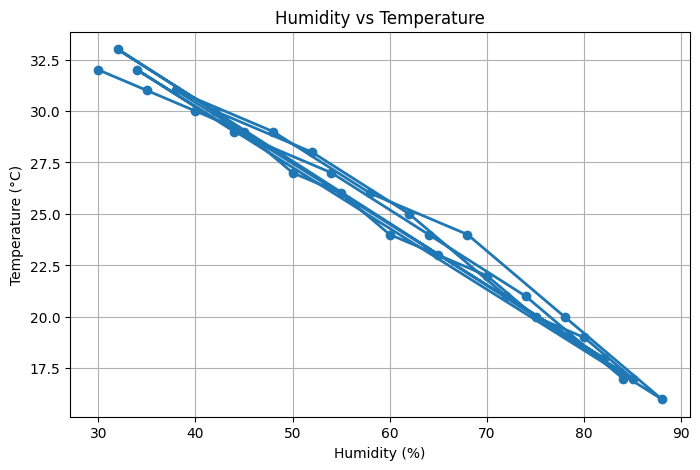

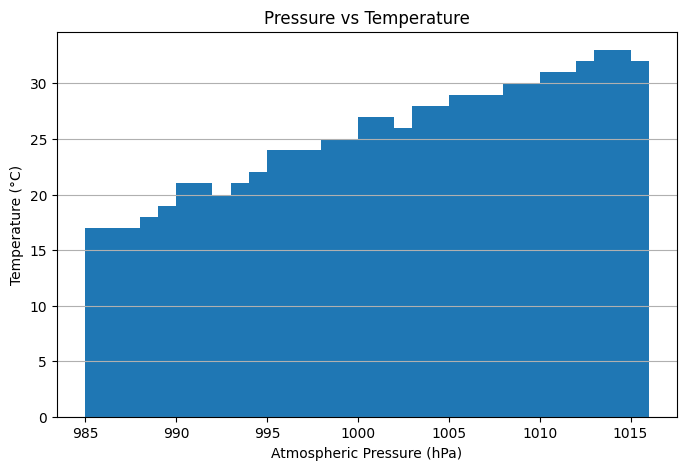

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================================================
# 1. Create Sample Weather Dataset
# =========================================================

data = {
    "Humidity": [
        30, 35, 40, 45, 50, 55, 60, 65, 70, 75,
        80, 85, 32, 42, 52, 62, 72, 82, 38, 48,
        58, 68, 78, 88, 34, 44, 54, 64, 74, 84
    ],

    "Pressure": [
        1015, 1012, 1010, 1008, 1005, 1002, 1000, 998, 995, 992,
        990, 988, 1014, 1009, 1004, 999, 994, 989, 1011, 1007,
        1003, 997, 993, 987, 1013, 1006, 1001, 996, 991, 986
    ],

    "Wind_Speed": [
        5, 6, 8, 10, 7, 9, 12, 14, 11, 15,
        16, 18, 4, 7, 10, 13, 15, 17, 6, 8,
        11, 13, 16, 19, 5, 9, 12, 14, 17, 20
    ],

    "Temperature": [
        32, 31, 30, 29, 27, 26, 24, 23, 22, 20,
        19, 17, 33, 30, 28, 25, 21, 18, 31, 29,
        26, 24, 20, 16, 32, 29, 27, 24, 21, 17
    ]
}

df = pd.DataFrame(data)

print("Weather Dataset:\n")
print(df.head())

print("\nDataset Shape:", df.shape)


# =========================================================
# 2. Define Features and Target
# =========================================================

X = df[["Humidity", "Pressure", "Wind_Speed"]]
y = df["Temperature"]


# =========================================================
# 3. Split Dataset
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =========================================================
# 4. Train Linear Regression Model
# =========================================================

model = LinearRegression()

model.fit(X_train, y_train)


# =========================================================
# 5. Make Predictions
# =========================================================

y_pred = model.predict(X_test)


# =========================================================
# 6. Model Evaluation
# =========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))


# =========================================================
# 7. Model Coefficients
# =========================================================

print("\n========== MODEL COEFFICIENTS ==========")

print("Humidity Coefficient   :", round(model.coef_[0], 4))
print("Pressure Coefficient   :", round(model.coef_[1], 4))
print("Wind Speed Coefficient :", round(model.coef_[2], 4))
print("Intercept              :", round(model.intercept_, 4))


# =========================================================
# 8. User Input
# =========================================================

print("\n========== TEMPERATURE PREDICTION ==========")


# Humidity
while True:
    try:
        humidity = float(input("Enter Humidity (%): "))

        if 0 <= humidity <= 100:
            break
        else:
            print("Humidity must be between 0 and 100%.")

    except ValueError:
        print("Please enter a valid number.")


# Pressure
while True:
    try:
        pressure = float(input("Enter Atmospheric Pressure (hPa): "))

        if 950 <= pressure <= 1050:
            break
        else:
            print("Pressure must be between 950 and 1050 hPa.")

    except ValueError:
        print("Please enter a valid number.")


# Wind Speed
while True:
    try:
        wind_speed = float(input("Enter Wind Speed (km/h): "))

        if 0 <= wind_speed <= 150:
            break
        else:
            print("Wind speed must be between 0 and 150 km/h.")

    except ValueError:
        print("Please enter a valid number.")


# =========================================================
# 9. Predict Temperature
# =========================================================

new_weather = pd.DataFrame({
    "Humidity": [humidity],
    "Pressure": [pressure],
    "Wind_Speed": [wind_speed]
})

predicted_temperature = model.predict(new_weather)[0]


# =========================================================
# 10. Temperature Category
# =========================================================

if predicted_temperature < 10:
    category = "Very Cold"
elif predicted_temperature < 20:
    category = "Cold"
elif predicted_temperature < 30:
    category = "Moderate"
elif predicted_temperature < 40:
    category = "Hot"
else:
    category = "Very Hot"


# =========================================================
# 11. Display Prediction
# =========================================================

print("\n========== PREDICTION RESULT ==========")

print(f"Humidity    : {humidity}%")
print(f"Pressure    : {pressure} hPa")
print(f"Wind Speed  : {wind_speed} km/h")

print(f"\nPredicted Temperature: {predicted_temperature:.2f} °C")
print("Temperature Category :", category)


# =========================================================
# 12. GRAPH 1
# Humidity vs Temperature
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df["Humidity"],
    df["Temperature"],
    marker="o",
    linewidth=2
)

plt.xlabel("Humidity (%)")
plt.ylabel("Temperature (°C)")
plt.title("Humidity vs Temperature")
plt.grid(True)

plt.show()


# =========================================================
# 13. GRAPH 2
# Pressure vs Temperature
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    df["Pressure"],
    df["Temperature"],
    width=2
)

plt.xlabel("Atmospheric Pressure (hPa)")
plt.ylabel("Temperature (°C)")
plt.title("Pressure vs Temperature")
plt.grid(axis="y")

plt.show()

14. Crop Yield Prediction

First 5 Records:
   Rainfall  Fertilizer  Temperature  Crop_Yield
0       450          40           32         2.1
1       500          45           31         2.3
2       550          50           30         2.5
3       600          55           29         2.8
4       650          60           28         3.0

Dataset Shape:
(30, 4)

========== MODEL EVALUATION ==========
MAE  : 0.053
MSE  : 0.004
RMSE : 0.061
R²   : 0.991

========== MODEL COEFFICIENTS ==========
Rainfall Coefficient   : 0.0043
Fertilizer Coefficient : -0.0
Temperature Coefficient: -0.0158
Intercept              : 0.6064

========== CROP YIELD PREDICTION ==========
Enter Rainfall (mm): 65
Please enter rainfall between 100 and 3000 mm.
Enter Rainfall (mm): 250
Enter Fertilizer (kg/hectare): 50
Enter Temperature (°C): 36

========== PREDICTION RESULT ==========
Rainfall       : 250.0 mm
Fertilizer     : 50.0 kg/hectare
Temperature    : 36.0 °C
Predicted Yield: 1.12 tons/hectare
Yield Category : Low Yield


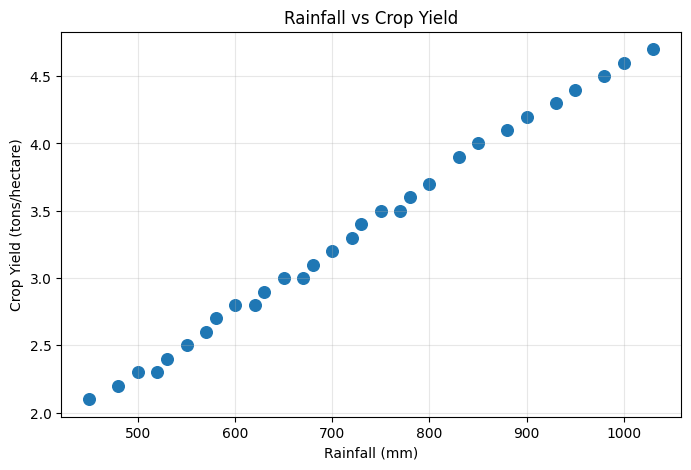

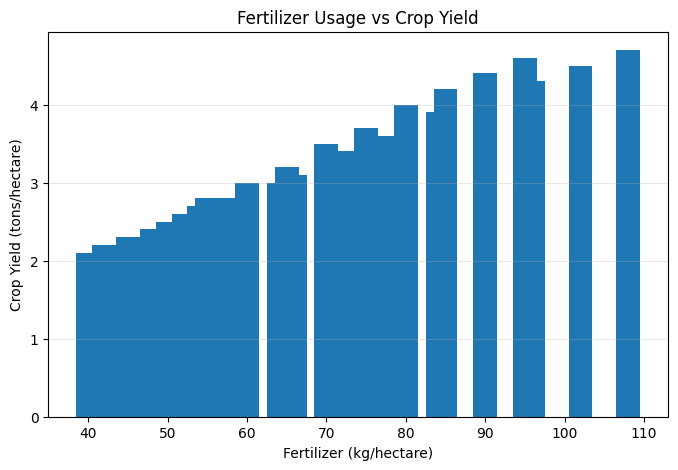

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Rainfall": [
        450, 500, 550, 600, 650, 700, 750, 800, 850, 900,
        950, 1000, 480, 530, 580, 630, 680, 730, 780, 830,
        880, 930, 980, 1030, 520, 570, 620, 670, 720, 770
    ],

    "Fertilizer": [
        40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
        90, 95, 42, 48, 54, 60, 66, 72, 78, 84,
        90, 96, 102, 108, 46, 52, 58, 64, 70, 76
    ],

    "Temperature": [
        32, 31, 30, 29, 28, 27, 26, 25, 24, 23,
        22, 21, 33, 31, 29, 28, 27, 26, 25, 24,
        23, 22, 21, 20, 32, 30, 28, 27, 26, 25
    ],

    "Crop_Yield": [
        2.1, 2.3, 2.5, 2.8, 3.0, 3.2, 3.5, 3.7, 4.0, 4.2,
        4.4, 4.6, 2.2, 2.4, 2.7, 2.9, 3.1, 3.4, 3.6, 3.9,
        4.1, 4.3, 4.5, 4.7, 2.3, 2.6, 2.8, 3.0, 3.3, 3.5
    ]
})


print("First 5 Records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ============================================================
# 2. Separate Features and Target
# ============================================================

X = data[["Rainfall", "Fertilizer", "Temperature"]]
y = data["Crop_Yield"]


# ============================================================
# 3. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 4. Train Linear Regression Model
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)


# ============================================================
# 5. Prediction on Test Data
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 6. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 3))
print("MSE  :", round(mse, 3))
print("RMSE :", round(rmse, 3))
print("R²   :", round(r2, 3))


# ============================================================
# 7. Model Coefficients
# ============================================================

print("\n========== MODEL COEFFICIENTS ==========")

print("Rainfall Coefficient   :", round(model.coef_[0], 4))
print("Fertilizer Coefficient :", round(model.coef_[1], 4))
print("Temperature Coefficient:", round(model.coef_[2], 4))
print("Intercept              :", round(model.intercept_, 4))


# ============================================================
# 8. Take User Input
# ============================================================

print("\n========== CROP YIELD PREDICTION ==========")

# Rainfall
while True:
    try:
        rainfall = float(input("Enter Rainfall (mm): "))

        if 100 <= rainfall <= 3000:
            break
        else:
            print("Please enter rainfall between 100 and 3000 mm.")

    except ValueError:
        print("Please enter a valid number.")


# Fertilizer
while True:
    try:
        fertilizer = float(input("Enter Fertilizer (kg/hectare): "))

        if 0 <= fertilizer <= 500:
            break
        else:
            print("Please enter fertilizer between 0 and 500 kg/hectare.")

    except ValueError:
        print("Please enter a valid number.")


# Temperature
while True:
    try:
        temperature = float(input("Enter Temperature (°C): "))

        if 5 <= temperature <= 50:
            break
        else:
            print("Please enter temperature between 5 and 50 °C.")

    except ValueError:
        print("Please enter a valid number.")


# ============================================================
# 9. Predict Crop Yield
# ============================================================

new_crop = pd.DataFrame({
    "Rainfall": [rainfall],
    "Fertilizer": [fertilizer],
    "Temperature": [temperature]
})

predicted_yield = model.predict(new_crop)[0]

# Avoid negative prediction
predicted_yield = max(0, predicted_yield)


# ============================================================
# 10. Yield Category
# ============================================================

if predicted_yield < 2:
    category = "Low Yield"
elif predicted_yield < 3:
    category = "Moderate Yield"
elif predicted_yield < 4:
    category = "Good Yield"
else:
    category = "High Yield"


print("\n========== PREDICTION RESULT ==========")

print("Rainfall       :", rainfall, "mm")
print("Fertilizer     :", fertilizer, "kg/hectare")
print("Temperature    :", temperature, "°C")
print("Predicted Yield:", round(predicted_yield, 2), "tons/hectare")
print("Yield Category :", category)


# ============================================================
# 11. GRAPH 1 - Rainfall vs Crop Yield
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Rainfall"],
    data["Crop_Yield"],
    s=70
)

plt.xlabel("Rainfall (mm)")
plt.ylabel("Crop Yield (tons/hectare)")
plt.title("Rainfall vs Crop Yield")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# 12. GRAPH 2 - Fertilizer vs Crop Yield
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    data["Fertilizer"],
    data["Crop_Yield"],
    width=3
)

plt.xlabel("Fertilizer (kg/hectare)")
plt.ylabel("Crop Yield (tons/hectare)")
plt.title("Fertilizer Usage vs Crop Yield")

plt.grid(axis="y", alpha=0.3)
plt.show()

15. Water Consumption Prediction

First 5 Records:
   Temperature  Family_Size  Season  Water_Consumption
0           18            2  Winter                210
1           20            3  Winter                245
2           22            4  Winter                280
3           24            5  Winter                315
4           26            6  Winter                350

Dataset Shape:
(30, 4)

========== MODEL EVALUATION ==========
MAE  : 4.2
MSE  : 23.99
RMSE : 4.9
R²   : 0.994

========== WATER CONSUMPTION PREDICTION ==========
Enter Temperature (°C): 45
Enter Family Size: 5
Enter Season (Summer/Winter): summer

========== PREDICTION RESULT ==========
Temperature        : 45.0 °C
Family Size        : 5
Season             : Summer
Predicted Water Consumption: 720.52 litres/day
Consumption Category: Very High Consumption


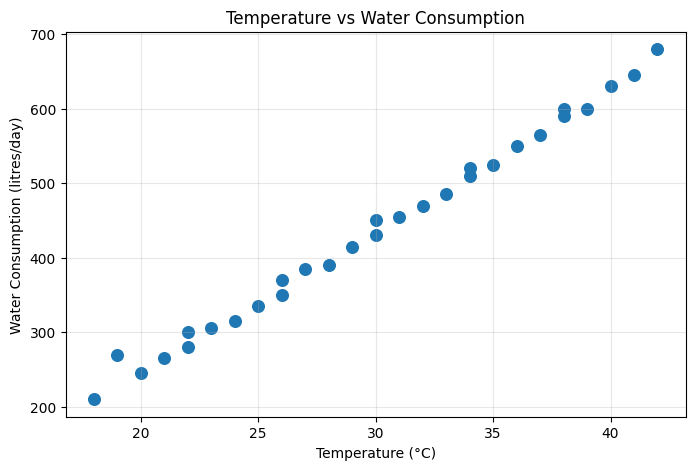

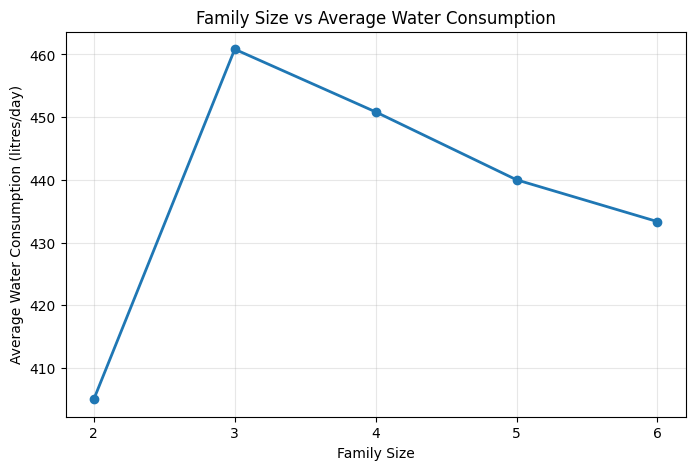

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Temperature": [
        18, 20, 22, 24, 26, 28, 30, 32, 34, 36,
        38, 40, 19, 23, 27, 31, 35, 39, 21, 25,
        29, 33, 37, 41, 22, 26, 30, 34, 38, 42
    ],

    "Family_Size": [
        2, 3, 4, 5, 6, 2, 3, 4, 5, 6,
        2, 3, 4, 5, 6, 2, 3, 4, 5, 6,
        2, 3, 4, 5, 6, 2, 3, 4, 5, 6
    ],

    "Season": [
        "Winter", "Winter", "Winter", "Winter", "Winter",
        "Summer", "Summer", "Summer", "Summer", "Summer",
        "Summer", "Summer", "Winter", "Winter", "Summer",
        "Summer", "Summer", "Summer", "Winter", "Winter",
        "Summer", "Summer", "Summer", "Summer", "Winter",
        "Summer", "Summer", "Summer", "Summer", "Summer"
    ],

    "Water_Consumption": [
        210, 245, 280, 315, 350, 390, 430, 470, 510, 550,
        590, 630, 270, 305, 385, 455, 525, 600, 265, 335,
        415, 485, 565, 645, 300, 370, 450, 520, 600, 680
    ]
})


print("First 5 Records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ============================================================
# 2. Define Features and Target
# ============================================================

X = data[["Temperature", "Family_Size", "Season"]]
y = data["Water_Consumption"]


# ============================================================
# 3. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 4. Preprocessing
# ============================================================

categorical_features = ["Season"]
numerical_features = ["Temperature", "Family_Size"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


# ============================================================
# 5. Create Linear Regression Pipeline
# ============================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Test Prediction
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))


# ============================================================
# 9. User Input
# ============================================================

print("\n========== WATER CONSUMPTION PREDICTION ==========")

# Temperature
while True:
    try:
        temperature = float(
            input("Enter Temperature (°C): ")
        )

        if 0 <= temperature <= 50:
            break
        else:
            print("Please enter temperature between 0 and 50 °C.")

    except ValueError:
        print("Please enter a valid number.")


# Family Size
while True:
    try:
        family_size = int(
            input("Enter Family Size: ")
        )

        if 1 <= family_size <= 20:
            break
        else:
            print("Please enter family size between 1 and 20.")

    except ValueError:
        print("Please enter a valid whole number.")


# Season
while True:
    season = input(
        "Enter Season (Summer/Winter): "
    ).strip().title()

    if season in ["Summer", "Winter"]:
        break
    else:
        print("Please enter either Summer or Winter.")


# ============================================================
# 10. Predict Water Consumption
# ============================================================

new_data = pd.DataFrame({
    "Temperature": [temperature],
    "Family_Size": [family_size],
    "Season": [season]
})

predicted_consumption = model.predict(new_data)[0]

predicted_consumption = max(0, predicted_consumption)


# ============================================================
# 11. Consumption Category
# ============================================================

if predicted_consumption < 250:
    category = "Low Consumption"

elif predicted_consumption < 400:
    category = "Moderate Consumption"

elif predicted_consumption < 550:
    category = "High Consumption"

else:
    category = "Very High Consumption"


# ============================================================
# 12. Display Result
# ============================================================

print("\n========== PREDICTION RESULT ==========")

print("Temperature        :", temperature, "°C")
print("Family Size        :", family_size)
print("Season             :", season)
print(
    "Predicted Water Consumption:",
    round(predicted_consumption, 2),
    "litres/day"
)
print("Consumption Category:", category)


# ============================================================
# GRAPH 1 - Temperature vs Water Consumption
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Temperature"],
    data["Water_Consumption"],
    s=70
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Water Consumption (litres/day)")
plt.title("Temperature vs Water Consumption")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# GRAPH 2 - Family Size vs Water Consumption
# ============================================================

family_avg = (
    data.groupby("Family_Size")["Water_Consumption"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    family_avg.index,
    family_avg.values,
    marker="o",
    linewidth=2
)

plt.xlabel("Family Size")
plt.ylabel("Average Water Consumption (litres/day)")
plt.title("Family Size vs Average Water Consumption")

plt.xticks(family_avg.index)
plt.grid(True, alpha=0.3)

plt.show()

16. Calories Burned Prediction

First 5 Records:
   Exercise_Time  Weight  Heart_Rate  Calories_Burned
0             15      50          95               90
1             20      55         100              120
2             25      60         105              155
3             30      65         110              195
4             35      70         115              235

Dataset Shape:
(30, 4)

========== MODEL EVALUATION ==========
MAE  : 12.17
MSE  : 257.88
RMSE : 16.06
R²   : 0.988

========== MODEL COEFFICIENTS ==========
Exercise Time Coefficient: 8.638
Weight Coefficient: -0.94
Heart Rate Coefficient: 1.46
Intercept: -156.094

========== CALORIES BURNED PREDICTION ==========
Enter Exercise Time (minutes): 120
Enter Weight (kg): 98
Enter Heart Rate (BPM): 89

========== PREDICTION RESULT ==========
Exercise Time : 120.0 minutes
Weight        : 98.0 kg
Heart Rate    : 89.0 BPM
Predicted Calories Burned: 918.3 calories
Category: Very High Calorie Burn


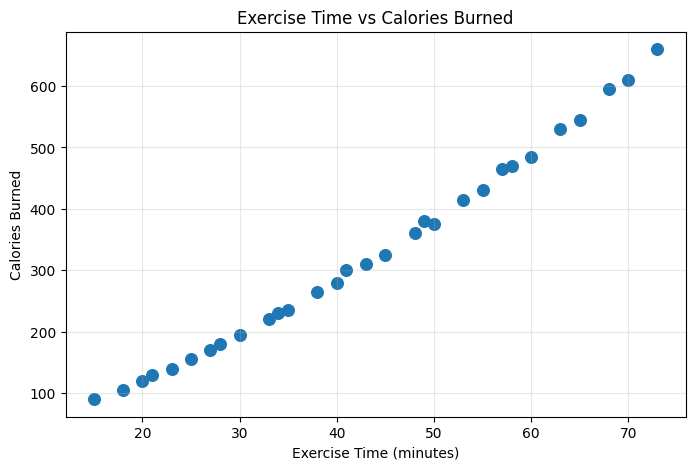

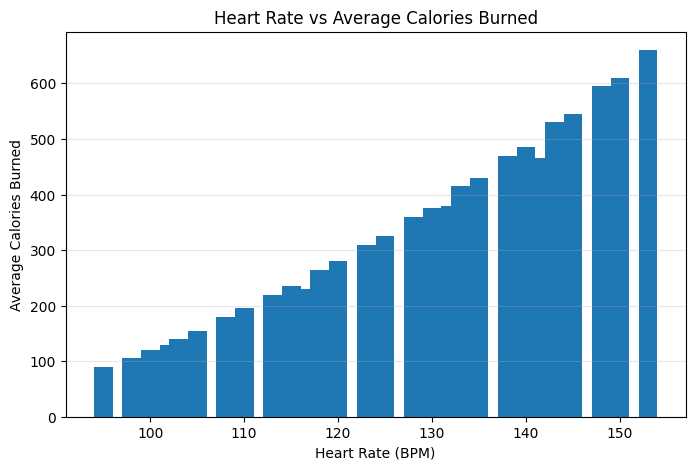

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Exercise_Time": [
        15, 20, 25, 30, 35, 40, 45, 50, 55, 60,
        65, 70, 18, 23, 28, 33, 38, 43, 48, 53,
        58, 63, 68, 73, 21, 27, 34, 41, 49, 57
    ],

    "Weight": [
        50, 55, 60, 65, 70, 75, 80, 85, 90, 95,
        60, 65, 52, 58, 63, 68, 73, 78, 83, 88,
        93, 98, 72, 77, 57, 62, 69, 76, 84, 91
    ],

    "Heart_Rate": [
        95, 100, 105, 110, 115, 120, 125, 130, 135, 140,
        145, 150, 98, 103, 108, 113, 118, 123, 128, 133,
        138, 143, 148, 153, 102, 109, 116, 124, 132, 141
    ],

    "Calories_Burned": [
        90, 120, 155, 195, 235, 280, 325, 375, 430, 485,
        545, 610, 105, 140, 180, 220, 265, 310, 360, 415,
        470, 530, 595, 660, 130, 170, 230, 300, 380, 465
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("First 5 Records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ============================================================
# 3. Features and Target
# ============================================================

X = data[[
    "Exercise_Time",
    "Weight",
    "Heart_Rate"
]]

y = data["Calories_Burned"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Test Prediction
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))


# ============================================================
# 9. Model Coefficients
# ============================================================

print("\n========== MODEL COEFFICIENTS ==========")

print(
    "Exercise Time Coefficient:",
    round(model.coef_[0], 3)
)

print(
    "Weight Coefficient:",
    round(model.coef_[1], 3)
)

print(
    "Heart Rate Coefficient:",
    round(model.coef_[2], 3)
)

print(
    "Intercept:",
    round(model.intercept_, 3)
)


# ============================================================
# 10. User Input
# ============================================================

print("\n========== CALORIES BURNED PREDICTION ==========")

# Exercise Time
while True:
    try:
        exercise_time = float(
            input("Enter Exercise Time (minutes): ")
        )

        if 5 <= exercise_time <= 300:
            break
        else:
            print(
                "Please enter exercise time between "
                "5 and 300 minutes."
            )

    except ValueError:
        print("Please enter a valid number.")


# Weight
while True:
    try:
        weight = float(
            input("Enter Weight (kg): ")
        )

        if 30 <= weight <= 200:
            break
        else:
            print(
                "Please enter weight between 30 and 200 kg."
            )

    except ValueError:
        print("Please enter a valid number.")


# Heart Rate
while True:
    try:
        heart_rate = float(
            input("Enter Heart Rate (BPM): ")
        )

        if 50 <= heart_rate <= 220:
            break
        else:
            print(
                "Please enter heart rate between "
                "50 and 220 BPM."
            )

    except ValueError:
        print("Please enter a valid number.")


# ============================================================
# 11. Prepare New Data
# ============================================================

new_exercise = pd.DataFrame({
    "Exercise_Time": [exercise_time],
    "Weight": [weight],
    "Heart_Rate": [heart_rate]
})


# ============================================================
# 12. Predict Calories
# ============================================================

predicted_calories = model.predict(new_exercise)[0]

predicted_calories = max(0, predicted_calories)


# ============================================================
# 13. Calories Category
# ============================================================

if predicted_calories < 150:
    category = "Low Calorie Burn"

elif predicted_calories < 300:
    category = "Moderate Calorie Burn"

elif predicted_calories < 500:
    category = "High Calorie Burn"

else:
    category = "Very High Calorie Burn"


# ============================================================
# 14. Display Prediction
# ============================================================

print("\n========== PREDICTION RESULT ==========")

print("Exercise Time :", exercise_time, "minutes")
print("Weight        :", weight, "kg")
print("Heart Rate    :", heart_rate, "BPM")

print(
    "Predicted Calories Burned:",
    round(predicted_calories, 2),
    "calories"
)

print("Category:", category)


# ============================================================
# GRAPH 1 - Exercise Time vs Calories
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Exercise_Time"],
    data["Calories_Burned"],
    s=70
)

plt.xlabel("Exercise Time (minutes)")
plt.ylabel("Calories Burned")
plt.title("Exercise Time vs Calories Burned")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# GRAPH 2 - Heart Rate vs Calories
# ============================================================

heart_rate_avg = (
    data.groupby("Heart_Rate")["Calories_Burned"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    heart_rate_avg.index,
    heart_rate_avg.values,
    width=2
)

plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Average Calories Burned")
plt.title("Heart Rate vs Average Calories Burned")

plt.grid(axis="y", alpha=0.3)
plt.show()

17. Running Time Prediction

First 5 Records:
   Distance  Age  Training_Hours  Running_Time
0         2   18               2          12.5
1         3   20               3          18.0
2         4   22               4          23.0
3         5   24               5          28.5
4         6   26               6          34.0

Dataset Shape:
(30, 4)

========== MODEL EVALUATION ==========
MAE  : 0.71
MSE  : 0.67
RMSE : 0.82
R²   : 0.997

========== MODEL COEFFICIENTS ==========
Distance Coefficient: 2.367
Age Coefficient: 0.397
Training Hours Coefficient: 2.367
Intercept: -4.502

========== RUNNING TIME PREDICTION ==========
Enter Distance (km): 5
Enter Age (years): 25
Enter Training Hours per Week: 12

========== PREDICTION RESULT ==========
Distance       : 5.0 km
Age            : 25 years
Training Hours : 12.0 hours/week
Predicted Running Time: 45.66 minutes
Running Category: Moderate


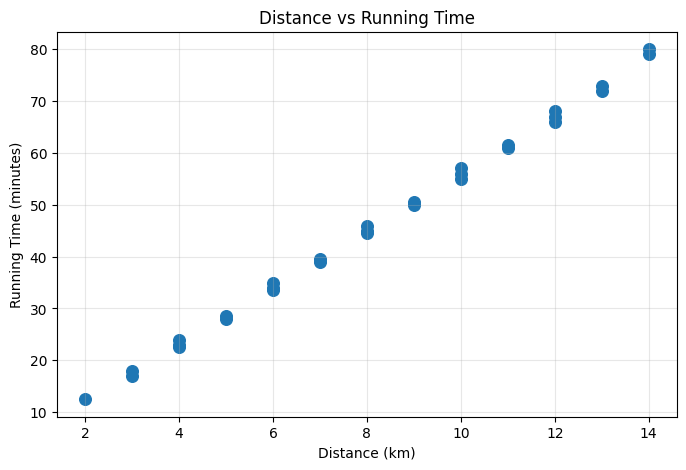

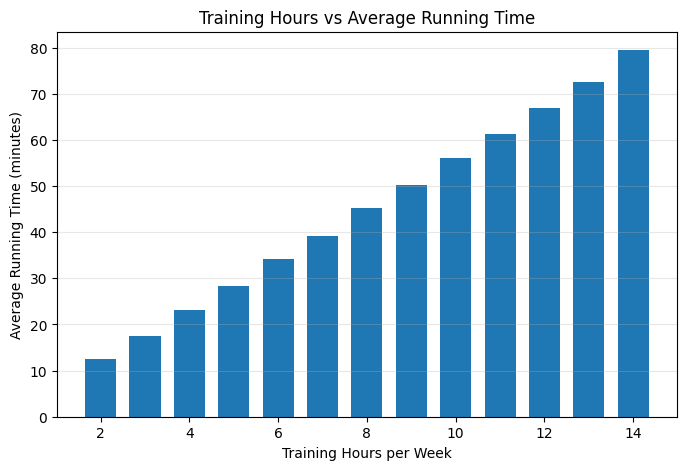

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Distance": [
        2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
        12, 13, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 4, 6, 8, 10, 12, 14
    ],

    "Age": [
        18, 20, 22, 24, 26, 28, 30, 32, 34, 36,
        38, 40, 19, 21, 23, 25, 27, 29, 31, 33,
        35, 37, 39, 41, 22, 26, 30, 34, 38, 42
    ],

    "Training_Hours": [
        2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
        12, 13, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 4, 6, 8, 10, 12, 14
    ],

    "Running_Time": [
        12.5, 18.0, 23.0, 28.5, 34.0, 39.0, 44.5, 50.0, 55.0, 61.0,
        66.0, 72.0, 17.0, 22.5, 28.0, 33.5, 39.5, 45.0, 50.5, 56.0,
        61.5, 67.0, 73.0, 79.0, 24.0, 35.0, 46.0, 57.0, 68.0, 80.0
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("First 5 Records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[[
    "Distance",
    "Age",
    "Training_Hours"
]]

y = data["Running_Time"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Test Prediction
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))


# ============================================================
# 9. Model Coefficients
# ============================================================

print("\n========== MODEL COEFFICIENTS ==========")

print(
    "Distance Coefficient:",
    round(model.coef_[0], 3)
)

print(
    "Age Coefficient:",
    round(model.coef_[1], 3)
)

print(
    "Training Hours Coefficient:",
    round(model.coef_[2], 3)
)

print(
    "Intercept:",
    round(model.intercept_, 3)
)


# ============================================================
# 10. User Input
# ============================================================

print("\n========== RUNNING TIME PREDICTION ==========")


# Distance
while True:
    try:
        distance = float(
            input("Enter Distance (km): ")
        )

        if 0.5 <= distance <= 100:
            break
        else:
            print(
                "Please enter distance between "
                "0.5 and 100 km."
            )

    except ValueError:
        print("Please enter a valid number.")


# Age
while True:
    try:
        age = int(
            input("Enter Age (years): ")
        )

        if 10 <= age <= 100:
            break
        else:
            print(
                "Please enter age between 10 and 100."
            )

    except ValueError:
        print("Please enter a valid whole number.")


# Training Hours
while True:
    try:
        training_hours = float(
            input("Enter Training Hours per Week: ")
        )

        if 0 <= training_hours <= 50:
            break
        else:
            print(
                "Please enter training hours between "
                "0 and 50."
            )

    except ValueError:
        print("Please enter a valid number.")


# ============================================================
# 11. Prepare New Data
# ============================================================

new_runner = pd.DataFrame({
    "Distance": [distance],
    "Age": [age],
    "Training_Hours": [training_hours]
})


# ============================================================
# 12. Predict Running Time
# ============================================================

predicted_time = model.predict(new_runner)[0]

predicted_time = max(0, predicted_time)


# ============================================================
# 13. Running Time Category
# ============================================================

if predicted_time < 30:
    category = "Fast"

elif predicted_time < 60:
    category = "Moderate"

elif predicted_time < 90:
    category = "Slow"

else:
    category = "Very Slow"


# ============================================================
# 14. Display Result
# ============================================================

print("\n========== PREDICTION RESULT ==========")

print("Distance       :", distance, "km")
print("Age            :", age, "years")
print("Training Hours :", training_hours, "hours/week")

print(
    "Predicted Running Time:",
    round(predicted_time, 2),
    "minutes"
)

print("Running Category:", category)


# ============================================================
# GRAPH 1 - Distance vs Running Time
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Distance"],
    data["Running_Time"],
    s=70
)

plt.xlabel("Distance (km)")
plt.ylabel("Running Time (minutes)")
plt.title("Distance vs Running Time")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# GRAPH 2 - Training Hours vs Average Running Time
# ============================================================

training_avg = (
    data.groupby("Training_Hours")["Running_Time"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    training_avg.index,
    training_avg.values,
    width=0.7
)

plt.xlabel("Training Hours per Week")
plt.ylabel("Average Running Time (minutes)")
plt.title("Training Hours vs Average Running Time")

plt.grid(axis="y", alpha=0.3)
plt.show()

18. Office Rent Prediction

First 5 Records:
   Area  Location_Score  Floors  Monthly_Rent
0   500               4       1         25000
1   600               4       1         29000
2   700               5       2         35000
3   800               5       2         40000
4   900               6       3         47000

Dataset Shape:
(30, 4)

========== MODEL EVALUATION ==========
MAE  : 1533.36
MSE  : 3695064.34
RMSE : 1922.26
R²   : 0.988

========== MODEL COEFFICIENTS ==========
Area Coefficient: 51.57
Location Score Coefficient: -10498.6
Floors Coefficient: 13563.99
Intercept: 23812.45

========== OFFICE RENT PREDICTION ==========
Enter Office Area (sq.ft): 1159
Enter Location Score (1-10): 8
Enter Number of Floors: 5

========== PREDICTION RESULT ==========
Office Area     : 1159.0 sq.ft
Location Score  : 8.0
Floors          : 5
Predicted Monthly Rent: ₹ 67408.2
Rent Category: Mid-Range Office


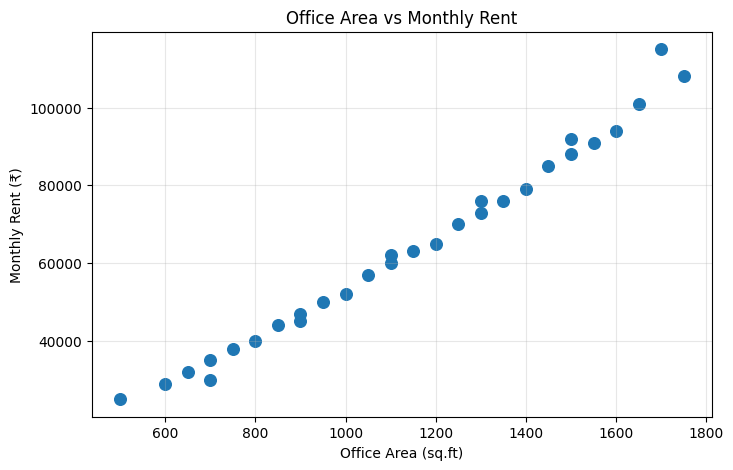

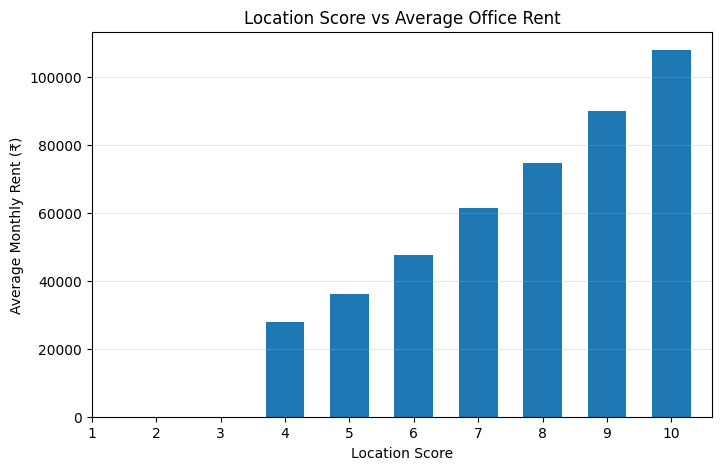

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Area": [
        500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400,
        1500, 1600, 650, 750, 850, 950, 1050, 1150, 1250, 1350,
        1450, 1550, 1650, 1750, 700, 900, 1100, 1300, 1500, 1700
    ],

    "Location_Score": [
        4, 4, 5, 5, 6, 6, 7, 7, 8, 8,
        9, 9, 5, 5, 6, 6, 7, 7, 8, 8,
        9, 9, 10, 10, 4, 6, 7, 8, 9, 10
    ],

    "Floors": [
        1, 1, 2, 2, 3, 3, 4, 4, 5, 5,
        6, 6, 2, 2, 3, 3, 4, 4, 5, 5,
        6, 6, 7, 7, 1, 3, 4, 5, 6, 8
    ],

    "Monthly_Rent": [
        25000, 29000, 35000, 40000, 47000, 52000,
        60000, 65000, 73000, 79000, 88000, 94000,
        32000, 38000, 44000, 50000, 57000, 63000,
        70000, 76000, 85000, 91000, 101000, 108000,
        30000, 45000, 62000, 76000, 92000, 115000
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("First 5 Records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[
    ["Area", "Location_Score", "Floors"]
]

y = data["Monthly_Rent"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Test Prediction
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))


# ============================================================
# 9. Model Coefficients
# ============================================================

print("\n========== MODEL COEFFICIENTS ==========")

print(
    "Area Coefficient:",
    round(model.coef_[0], 2)
)

print(
    "Location Score Coefficient:",
    round(model.coef_[1], 2)
)

print(
    "Floors Coefficient:",
    round(model.coef_[2], 2)
)

print(
    "Intercept:",
    round(model.intercept_, 2)
)


# ============================================================
# 10. User Input
# ============================================================

print("\n========== OFFICE RENT PREDICTION ==========")


# Area
while True:
    try:
        area = float(
            input("Enter Office Area (sq.ft): ")
        )

        if 100 <= area <= 50000:
            break
        else:
            print(
                "Please enter area between "
                "100 and 50,000 sq.ft."
            )

    except ValueError:
        print("Please enter a valid number.")


# Location Score
while True:
    try:
        location_score = float(
            input("Enter Location Score (1-10): ")
        )

        if 1 <= location_score <= 10:
            break
        else:
            print(
                "Please enter a location score "
                "between 1 and 10."
            )

    except ValueError:
        print("Please enter a valid number.")


# Floors
while True:
    try:
        floors = int(
            input("Enter Number of Floors: ")
        )

        if 1 <= floors <= 100:
            break
        else:
            print(
                "Please enter floors between 1 and 100."
            )

    except ValueError:
        print("Please enter a valid whole number.")


# ============================================================
# 11. Prepare New Office Data
# ============================================================

new_office = pd.DataFrame({
    "Area": [area],
    "Location_Score": [location_score],
    "Floors": [floors]
})


# ============================================================
# 12. Predict Monthly Rent
# ============================================================

predicted_rent = model.predict(new_office)[0]

predicted_rent = max(0, predicted_rent)


# ============================================================
# 13. Rent Category
# ============================================================

if predicted_rent < 40000:
    category = "Budget Office"

elif predicted_rent < 70000:
    category = "Mid-Range Office"

elif predicted_rent < 100000:
    category = "Premium Office"

else:
    category = "Luxury Office"


# ============================================================
# 14. Display Result
# ============================================================

print("\n========== PREDICTION RESULT ==========")

print("Office Area     :", area, "sq.ft")
print("Location Score  :", location_score)
print("Floors          :", floors)

print(
    "Predicted Monthly Rent: ₹",
    round(predicted_rent, 2)
)

print("Rent Category:", category)


# ============================================================
# GRAPH 1 - Area vs Monthly Rent
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Area"],
    data["Monthly_Rent"],
    s=70
)

plt.xlabel("Office Area (sq.ft)")
plt.ylabel("Monthly Rent (₹)")
plt.title("Office Area vs Monthly Rent")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# GRAPH 2 - Location Score vs Average Rent
# ============================================================

location_avg = (
    data.groupby("Location_Score")["Monthly_Rent"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    location_avg.index,
    location_avg.values,
    width=0.6
)

plt.xlabel("Location Score")
plt.ylabel("Average Monthly Rent (₹)")
plt.title("Location Score vs Average Office Rent")

plt.xticks(range(1, 11))
plt.grid(axis="y", alpha=0.3)

plt.show()

19. Shop Sales Prediction

First 5 Records:
   Advertising  Customers  Discount  Sales
0            5        100         5  22000
1            8        120        10  26000
2           10        140         5  30000
3           12        160        15  35000
4           15        180        10  40000

Dataset Shape:
(30, 4)

========== MODEL EVALUATION ==========
MAE  : 1614.21
MSE  : 2813760.71
RMSE : 1677.43
R²   : 0.981

========== MODEL COEFFICIENTS ==========
Advertising Coefficient: 432.97
Customers Coefficient: 211.14
Discount Coefficient: -72.39
Intercept: -2520.54

========== SHOP SALES PREDICTION ==========
Enter Advertising Budget (₹ thousands): 5000
Please enter advertising budget between 0 and 500.
Enter Advertising Budget (₹ thousands): 450
Enter Number of Customers: 900
Enter Discount (%): 3

========== PREDICTION RESULT ==========
Advertising Budget : ₹ 450.0 thousand
Customers           : 900
Discount            : 3.0 %
Predicted Sales     : ₹ 382127.1
Sales Category      : Very High Sales


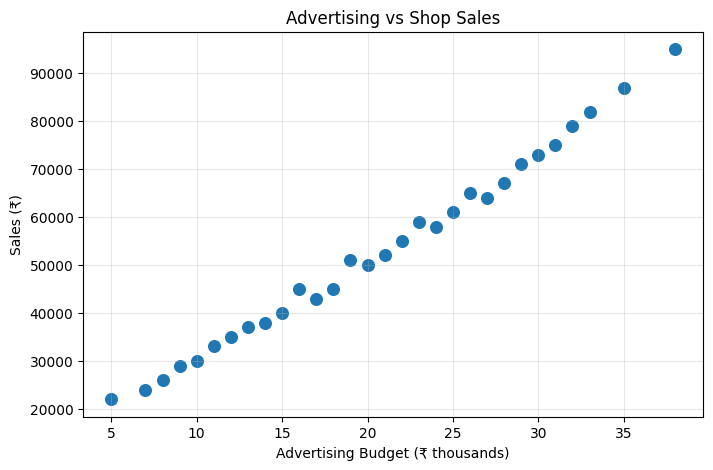

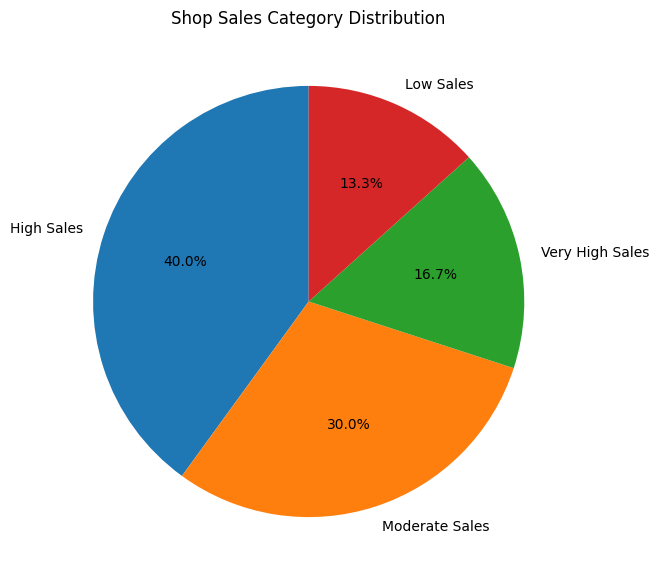

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Advertising": [
        5, 8, 10, 12, 15, 18, 20, 22, 25, 28,
        30, 32, 7, 11, 14, 17, 21, 24, 27, 31,
        9, 13, 16, 19, 23, 26, 29, 33, 35, 38
    ],

    "Customers": [
        100, 120, 140, 160, 180, 200, 220, 240, 260, 280,
        300, 320, 110, 150, 170, 190, 230, 250, 270, 310,
        130, 155, 185, 210, 245, 265, 295, 330, 350, 380
    ],

    "Discount": [
        5, 10, 5, 15, 10, 5, 20, 10, 15, 5,
        10, 20, 5, 10, 15, 5, 10, 20, 15, 10,
        5, 15, 10, 20, 5, 10, 15, 20, 10, 5
    ],

    "Sales": [
        22000, 26000, 30000, 35000, 40000, 45000,
        50000, 55000, 61000, 67000, 73000, 79000,
        24000, 33000, 38000, 43000, 52000, 58000,
        64000, 75000, 29000, 37000, 45000, 51000,
        59000, 65000, 71000, 82000, 87000, 95000
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("First 5 Records:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[
    ["Advertising", "Customers", "Discount"]
]

y = data["Sales"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Test Prediction
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 3))


# ============================================================
# 9. Model Coefficients
# ============================================================

print("\n========== MODEL COEFFICIENTS ==========")

print(
    "Advertising Coefficient:",
    round(model.coef_[0], 2)
)

print(
    "Customers Coefficient:",
    round(model.coef_[1], 2)
)

print(
    "Discount Coefficient:",
    round(model.coef_[2], 2)
)

print(
    "Intercept:",
    round(model.intercept_, 2)
)


# ============================================================
# 10. User Input
# ============================================================

print("\n========== SHOP SALES PREDICTION ==========")


# Advertising
while True:
    try:
        advertising = float(
            input("Enter Advertising Budget (₹ thousands): ")
        )

        if 0 <= advertising <= 500:
            break
        else:
            print(
                "Please enter advertising budget "
                "between 0 and 500."
            )

    except ValueError:
        print("Please enter a valid number.")


# Customers
while True:
    try:
        customers = int(
            input("Enter Number of Customers: ")
        )

        if 1 <= customers <= 5000:
            break
        else:
            print(
                "Please enter customers between "
                "1 and 5000."
            )

    except ValueError:
        print("Please enter a valid whole number.")


# Discount
while True:
    try:
        discount = float(
            input("Enter Discount (%): ")
        )

        if 0 <= discount <= 50:
            break
        else:
            print(
                "Please enter discount between 0% and 50%."
            )

    except ValueError:
        print("Please enter a valid number.")


# ============================================================
# 11. Prepare New Data
# ============================================================

new_shop = pd.DataFrame({
    "Advertising": [advertising],
    "Customers": [customers],
    "Discount": [discount]
})


# ============================================================
# 12. Predict Sales
# ============================================================

predicted_sales = model.predict(new_shop)[0]

predicted_sales = max(0, predicted_sales)


# ============================================================
# 13. Sales Category
# ============================================================

if predicted_sales < 30000:
    category = "Low Sales"

elif predicted_sales < 50000:
    category = "Moderate Sales"

elif predicted_sales < 75000:
    category = "High Sales"

else:
    category = "Very High Sales"


# ============================================================
# 14. Display Prediction
# ============================================================

print("\n========== PREDICTION RESULT ==========")

print(
    "Advertising Budget : ₹",
    advertising,
    "thousand"
)

print("Customers           :", customers)
print("Discount            :", discount, "%")

print(
    "Predicted Sales     : ₹",
    round(predicted_sales, 2)
)

print("Sales Category      :", category)


# ============================================================
# GRAPH 1 - Advertising vs Sales
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    data["Advertising"],
    data["Sales"],
    s=70
)

plt.xlabel("Advertising Budget (₹ thousands)")
plt.ylabel("Sales (₹)")
plt.title("Advertising vs Shop Sales")

plt.grid(True, alpha=0.3)
plt.show()


# ============================================================
# GRAPH 2 - PIE CHART
# Sales Category Distribution
# ============================================================

def sales_category(sales):

    if sales < 30000:
        return "Low Sales"

    elif sales < 50000:
        return "Moderate Sales"

    elif sales < 75000:
        return "High Sales"

    else:
        return "Very High Sales"


data["Sales_Category"] = data["Sales"].apply(
    sales_category
)

category_counts = data["Sales_Category"].value_counts()


plt.figure(figsize=(7, 7))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Shop Sales Category Distribution")

plt.show()

20. Advertisement Sales Prediction

Advertisement Sales Dataset:
   TV_Ads  Social_Media_Ads  Newspaper_Ads  Sales
0      10                 5              2  18000
1      15                 8              3  21000
2      20                10              4  24500
3      25                12              5  28000
4      30                15              6  32000

Dataset Shape: (30, 4)

Model Evaluation
-------------------------
MAE  : 624.56
MSE  : 529817.23
RMSE : 727.89
R²   : 0.998

Model Coefficients
-------------------------
TV Ads Coefficient       : 409.23
Social Media Coefficient: 781.76
Newspaper Coefficient   : -70.49
Intercept               : 8311.95


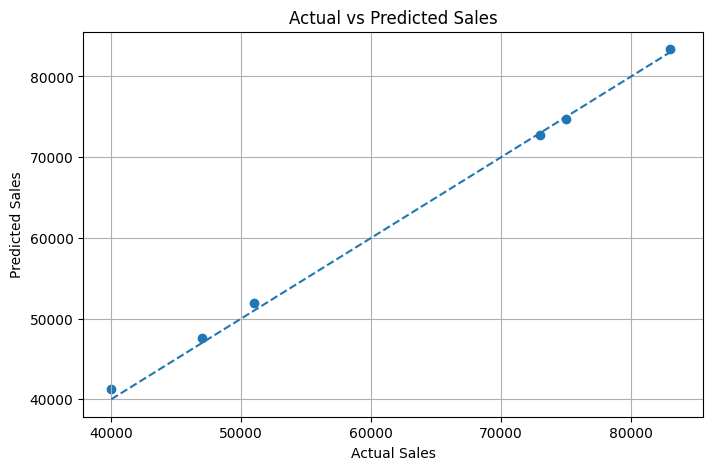

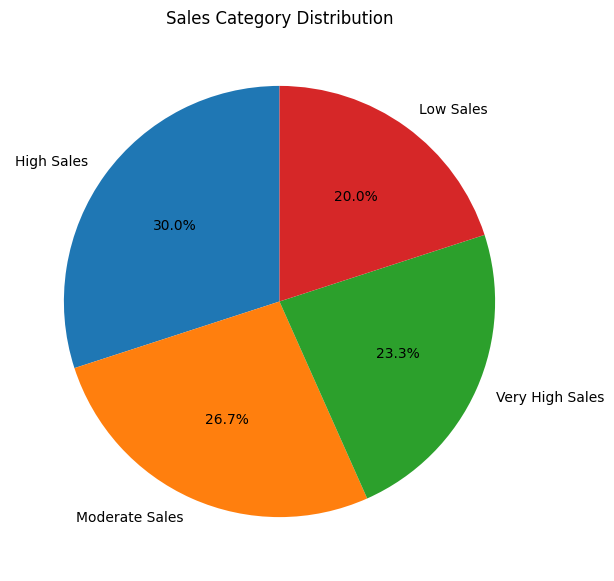


Advertisement Sales Prediction
--------------------------------
TV Ads should be between 0 and 500.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "TV_Ads": [
        10, 15, 20, 25, 30, 35, 40, 45, 50, 55,
        60, 65, 70, 75, 80, 85, 90, 95, 100, 105,
        12, 22, 32, 42, 52, 62, 72, 82, 92, 102
    ],

    "Social_Media_Ads": [
        5, 8, 10, 12, 15, 18, 20, 22, 25, 28,
        30, 32, 35, 38, 40, 42, 45, 48, 50, 52,
        7, 11, 16, 21, 26, 31, 36, 41, 46, 51
    ],

    "Newspaper_Ads": [
        2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
        12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
        3, 5, 7, 9, 11, 13, 15, 17, 19, 21
    ],

    "Sales": [
        18000, 21000, 24500, 28000, 32000, 35000, 39000, 43000, 47000, 51000,
        55000, 59000, 63000, 67000, 71000, 75000, 79000, 83000, 87000, 91000,
        19500, 26000, 31000, 40000, 48000, 57000, 65000, 73000, 81000, 90000
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("Advertisement Sales Dataset:")
print(data.head())

print("\nDataset Shape:", data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[["TV_Ads", "Social_Media_Ads", "Newspaper_Ads"]]
y = data["Sales"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Train Linear Regression Model
# ============================================================

model = LinearRegression()

model.fit(X_train, y_train)


# ============================================================
# 6. Prediction on Test Data
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 7. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation")
print("-------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))


# ============================================================
# 8. Model Coefficients
# ============================================================

print("\nModel Coefficients")
print("-------------------------")

print("TV Ads Coefficient       :", round(model.coef_[0], 2))
print("Social Media Coefficient:", round(model.coef_[1], 2))
print("Newspaper Coefficient   :", round(model.coef_[2], 2))
print("Intercept               :", round(model.intercept_, 2))


# ============================================================
# 9. Sales Category Function
# ============================================================

def sales_category(sales):

    if sales < 30000:
        return "Low Sales"

    elif sales < 50000:
        return "Moderate Sales"

    elif sales < 75000:
        return "High Sales"

    else:
        return "Very High Sales"


# ============================================================
# 10. Actual vs Predicted Graph
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.grid(True)
plt.show()


# ============================================================
# 11. Pie Chart - Sales Category Distribution
# ============================================================

data["Sales_Category"] = data["Sales"].apply(sales_category)

category_counts = data["Sales_Category"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Category Distribution")
plt.show()


# ============================================================
# 12. User Input for New Prediction
# ============================================================

print("\nAdvertisement Sales Prediction")
print("--------------------------------")

while True:

    try:

        tv = float(input("Enter TV advertising budget (₹ thousands): "))

        social = float(
            input("Enter Social Media advertising budget (₹ thousands): ")
        )

        newspaper = float(
            input("Enter Newspaper advertising budget (₹ thousands): ")
        )

        # Validation
        if tv < 0 or tv > 500:
            print("TV Ads should be between 0 and 500.")
            continue

        if social < 0 or social > 500:
            print("Social Media Ads should be between 0 and 500.")
            continue

        if newspaper < 0 or newspaper > 500:
            print("Newspaper Ads should be between 0 and 500.")
            continue

        break

    except ValueError:

        print("Please enter valid numeric values.")


# ============================================================
# 13. Make Prediction
# ============================================================

new_data = pd.DataFrame({
    "TV_Ads": [tv],
    "Social_Media_Ads": [social],
    "Newspaper_Ads": [newspaper]
})

predicted_sales = model.predict(new_data)[0]

predicted_sales = max(0, predicted_sales)

category = sales_category(predicted_sales)


# ============================================================
# 14. Display Result
# ============================================================

print("\nPrediction Result")
print("-------------------------")

print(f"TV Ads              : ₹{tv:.2f} thousand")
print(f"Social Media Ads    : ₹{social:.2f} thousand")
print(f"Newspaper Ads       : ₹{newspaper:.2f} thousand")

print(f"\nPredicted Sales     : ₹{predicted_sales:,.2f}")

print(f"Sales Category      : {category}")

21.Delivery Time Prediction

Delivery Time Dataset
-------------------------
   Distance Traffic_Level  Package_Weight  Delivery_Time
0         2           Low               1             18
1         4           Low               2             25
2         6        Medium               3             33
3         8        Medium               4             40
4        10          High               5             50

Dataset Shape: (30, 4)

Model Evaluation
-------------------------
MAE  : 2.62 minutes
MSE  : 9.66
RMSE : 3.11 minutes
R²   : 0.9338


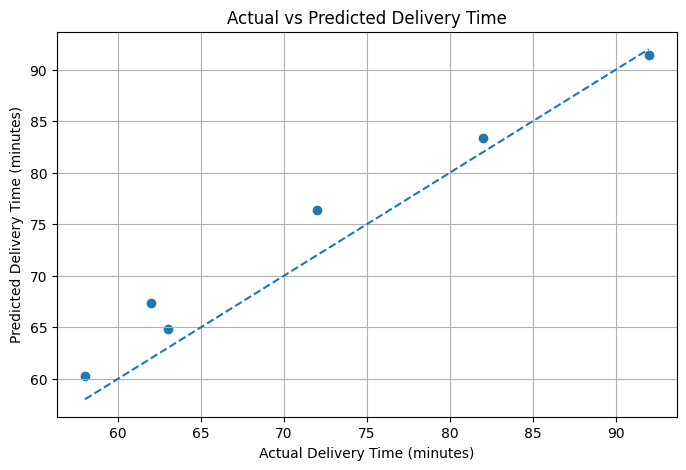

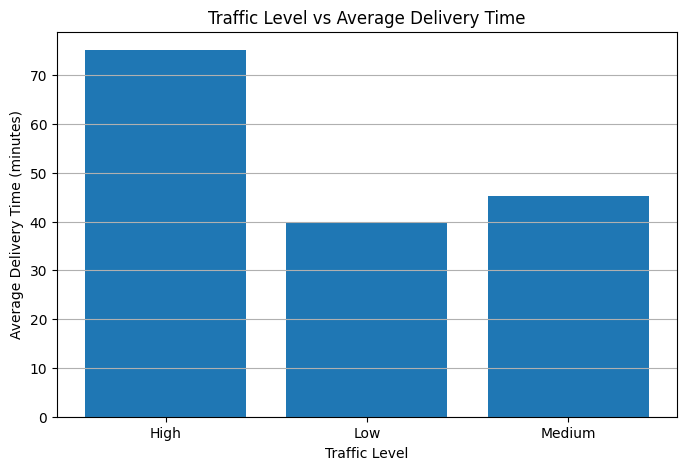

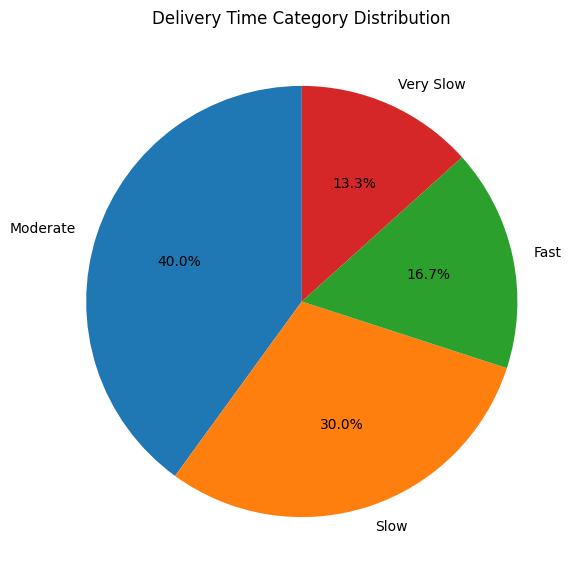


Delivery Time Prediction
-------------------------
Enter delivery distance (km): 15
Enter traffic level (Low/Medium/High): low
Enter package weight (kg): 3

Prediction Result
-------------------------
Distance        : 15.00 km
Traffic Level   : Low
Package Weight  : 3.00 kg

Predicted Delivery Time : 51.61 minutes
Delivery Category       : Moderate


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({
    "Distance": [
        2, 4, 6, 8, 10, 12, 14, 16, 18, 20,
        3, 5, 7, 9, 11, 13, 15, 17, 19, 21,
        4, 8, 12, 16, 20, 6, 10, 14, 18, 22
    ],

    "Traffic_Level": [
        "Low", "Low", "Medium", "Medium", "High",
        "High", "Medium", "Low", "High", "High",
        "Low", "Medium", "Low", "High", "Medium",
        "High", "Medium", "Low", "High", "High",
        "Low", "Medium", "High", "Low", "High",
        "Medium", "Low", "Medium", "High", "High"
    ],

    "Package_Weight": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
        1, 3, 5, 7, 9, 2, 4, 6, 8, 10
    ],

    "Delivery_Time": [
        18, 25, 33, 40, 50, 59, 65, 68, 82, 92,
        20, 30, 35, 48, 52, 63, 70, 72, 85, 98,
        17, 32, 55, 62, 90, 28, 42, 58, 78, 102
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("Delivery Time Dataset")
print("-------------------------")
print(data.head())

print("\nDataset Shape:", data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[[
    "Distance",
    "Traffic_Level",
    "Package_Weight"
]]

y = data["Delivery_Time"]


# ============================================================
# 4. Define Numerical and Categorical Features
# ============================================================

categorical_features = ["Traffic_Level"]

numerical_features = [
    "Distance",
    "Package_Weight"
]


# ============================================================
# 5. Preprocessing
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)


# ============================================================
# 6. Create Linear Regression Pipeline
# ============================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)


# ============================================================
# 7. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 8. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 9. Prediction
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 10. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\nModel Evaluation")
print("-------------------------")
print("MAE  :", round(mae, 2), "minutes")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2), "minutes")
print("R²   :", round(r2, 4))


# ============================================================
# 11. Delivery Time Category
# ============================================================

def delivery_category(time):

    if time < 30:
        return "Fast"

    elif time < 60:
        return "Moderate"

    elif time < 90:
        return "Slow"

    else:
        return "Very Slow"


# ============================================================
# 12. Actual vs Predicted Graph
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time")

plt.grid(True)
plt.show()


# ============================================================
# 13. Traffic Level vs Average Delivery Time
# ============================================================

traffic_average = data.groupby(
    "Traffic_Level"
)["Delivery_Time"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    traffic_average.index,
    traffic_average.values
)

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (minutes)")
plt.title("Traffic Level vs Average Delivery Time")

plt.grid(axis="y")
plt.show()


# ============================================================
# 14. Pie Chart - Delivery Time Categories
# ============================================================

data["Delivery_Category"] = data["Delivery_Time"].apply(
    delivery_category
)

category_counts = data["Delivery_Category"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Delivery Time Category Distribution")

plt.show()


# ============================================================
# 15. User Input
# ============================================================

print("\nDelivery Time Prediction")
print("-------------------------")

while True:

    try:

        distance = float(
            input("Enter delivery distance (km): ")
        )

        traffic = input(
            "Enter traffic level (Low/Medium/High): "
        ).strip().title()

        weight = float(
            input("Enter package weight (kg): ")
        )


        # Validation
        if distance <= 0 or distance > 500:
            print("Distance should be between 0 and 500 km.")
            continue

        if traffic not in ["Low", "Medium", "High"]:
            print("Traffic must be Low, Medium, or High.")
            continue

        if weight <= 0 or weight > 100:
            print("Package weight should be between 0 and 100 kg.")
            continue

        break

    except ValueError:

        print("Please enter valid numeric values.")


# ============================================================
# 16. Make New Prediction
# ============================================================

new_data = pd.DataFrame({
    "Distance": [distance],
    "Traffic_Level": [traffic],
    "Package_Weight": [weight]
})

predicted_time = model.predict(new_data)[0]

predicted_time = max(0, predicted_time)

category = delivery_category(predicted_time)


# ============================================================
# 17. Display Prediction
# ============================================================

print("\nPrediction Result")
print("-------------------------")

print(f"Distance        : {distance:.2f} km")
print(f"Traffic Level   : {traffic}")
print(f"Package Weight  : {weight:.2f} kg")

print(
    f"\nPredicted Delivery Time : "
    f"{predicted_time:.2f} minutes"
)

print(f"Delivery Category       : {category}")

22. Call Center Waiting Time Prediction

Call Center Waiting Time Dataset
---------------------------------
   Number_of_Calls  Agents  Call_Duration  Waiting_Time
0               20      10              3             2
1               25      10              4             3
2               30       9              4             4
3               35       9              5             5
4               40       8              5             6

Dataset Shape: (30, 4)

Model Evaluation
-------------------------
MAE  : 2.5 minutes
MSE  : 6.66
RMSE : 2.58 minutes
R²   : 0.9416

Model Coefficients
-------------------------
Number of Calls : 0.58
Agents          : 2.0
Call Duration   : 0.38
Intercept       : -36.2


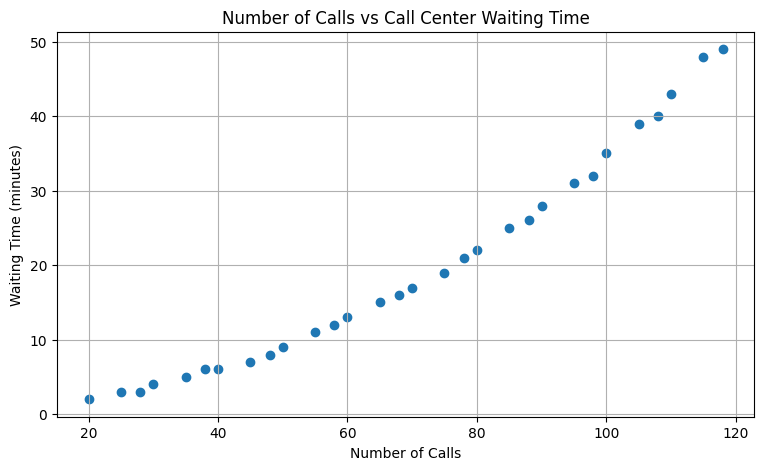

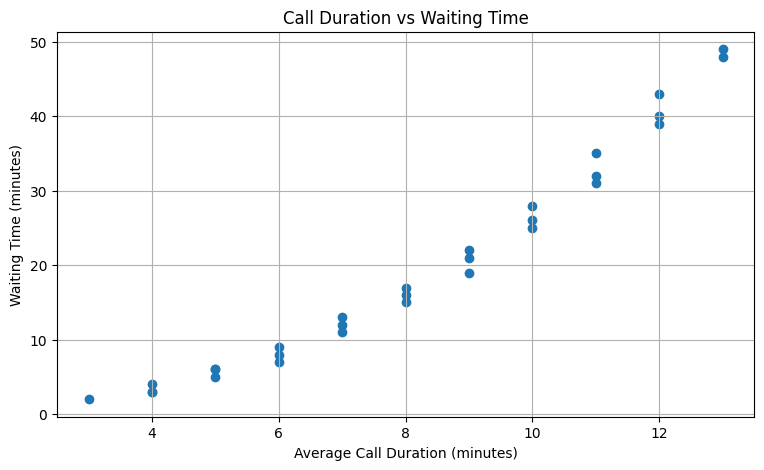

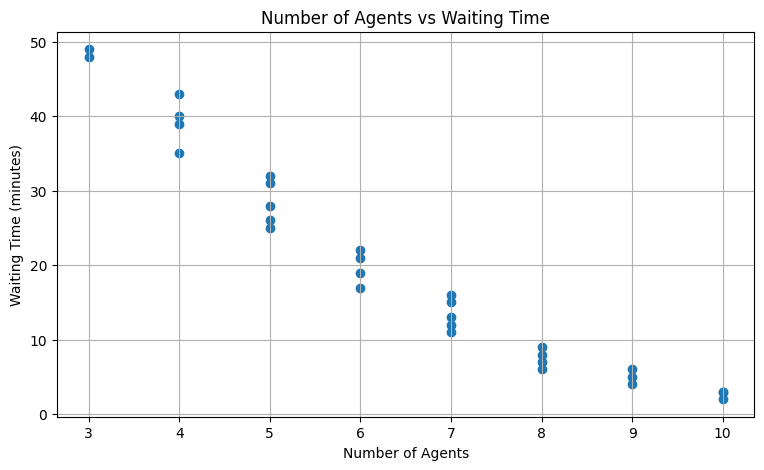

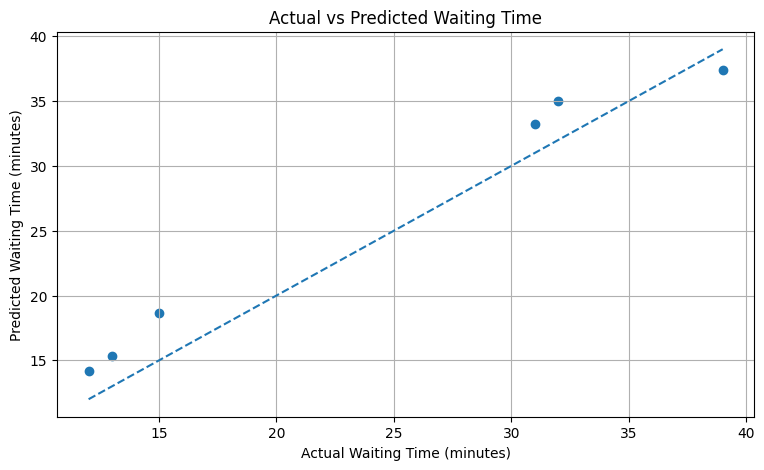


Call Center Waiting Time Prediction
------------------------------------
Enter number of calls: 15
Enter number of available agents: 5
Enter average call duration (minutes): 10

Prediction Result
-------------------------
Number of Calls : 15
Available Agents: 5
Call Duration   : 10.00 minutes

Predicted Waiting Time : 0.00 minutes
Waiting Category       : Very Low


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({

    "Number_of_Calls": [
        20, 25, 30, 35, 40, 45, 50, 55, 60, 65,
        70, 75, 80, 85, 90, 95, 100, 105, 110, 115,
        28, 38, 48, 58, 68, 78, 88, 98, 108, 118
    ],

    "Agents": [
        10, 10, 9, 9, 8, 8, 8, 7, 7, 7,
        6, 6, 6, 5, 5, 5, 4, 4, 4, 3,
        10, 9, 8, 7, 7, 6, 5, 5, 4, 3
    ],

    "Call_Duration": [
        3, 4, 4, 5, 5, 6, 6, 7, 7, 8,
        8, 9, 9, 10, 10, 11, 11, 12, 12, 13,
        4, 5, 6, 7, 8, 9, 10, 11, 12, 13
    ],

    "Waiting_Time": [
        2, 3, 4, 5, 6, 7, 9, 11, 13, 15,
        17, 19, 22, 25, 28, 31, 35, 39, 43, 48,
        3, 6, 8, 12, 16, 21, 26, 32, 40, 49
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("Call Center Waiting Time Dataset")
print("---------------------------------")

print(data.head())

print("\nDataset Shape:", data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[
    [
        "Number_of_Calls",
        "Agents",
        "Call_Duration"
    ]
]

y = data["Waiting_Time"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Make Predictions
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\nModel Evaluation")
print("-------------------------")

print("MAE  :", round(mae, 2), "minutes")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2), "minutes")
print("R²   :", round(r2, 4))


# ============================================================
# 9. Display Model Coefficients
# ============================================================

print("\nModel Coefficients")
print("-------------------------")

print(
    "Number of Calls :",
    round(model.coef_[0], 2)
)

print(
    "Agents          :",
    round(model.coef_[1], 2)
)

print(
    "Call Duration   :",
    round(model.coef_[2], 2)
)

print(
    "Intercept       :",
    round(model.intercept_, 2)
)


# ============================================================
# 10. Waiting Time Category
# ============================================================

def waiting_category(time):

    if time < 5:
        return "Very Low"

    elif time < 15:
        return "Low"

    elif time < 30:
        return "Moderate"

    else:
        return "High"


# ============================================================
# 11. SCATTER GRAPH
# Number of Calls vs Waiting Time
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Number_of_Calls"],
    data["Waiting_Time"]
)

plt.xlabel("Number of Calls")
plt.ylabel("Waiting Time (minutes)")

plt.title(
    "Number of Calls vs Call Center Waiting Time"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. SCATTER GRAPH
# Call Duration vs Waiting Time
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Call_Duration"],
    data["Waiting_Time"]
)

plt.xlabel("Average Call Duration (minutes)")
plt.ylabel("Waiting Time (minutes)")

plt.title(
    "Call Duration vs Waiting Time"
)

plt.grid(True)

plt.show()


# ============================================================
# 13. SCATTER GRAPH
# Number of Agents vs Waiting Time
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Agents"],
    data["Waiting_Time"]
)

plt.xlabel("Number of Agents")
plt.ylabel("Waiting Time (minutes)")

plt.title(
    "Number of Agents vs Waiting Time"
)

plt.grid(True)

plt.show()


# ============================================================
# 14. Actual vs Predicted Scatter Plot
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Waiting Time (minutes)")
plt.ylabel("Predicted Waiting Time (minutes)")

plt.title(
    "Actual vs Predicted Waiting Time"
)

plt.grid(True)

plt.show()


# ============================================================
# 15. User Input
# ============================================================

print("\nCall Center Waiting Time Prediction")
print("------------------------------------")

while True:

    try:

        calls = float(
            input("Enter number of calls: ")
        )

        agents = float(
            input("Enter number of available agents: ")
        )

        duration = float(
            input("Enter average call duration (minutes): ")
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        if calls <= 0 or calls > 10000:

            print(
                "Number of calls should be between 1 and 10000."
            )

            continue


        if agents <= 0 or agents > 1000:

            print(
                "Number of agents should be between 1 and 1000."
            )

            continue


        if duration <= 0 or duration > 120:

            print(
                "Call duration should be between 1 and 120 minutes."
            )

            continue


        break


    except ValueError:

        print(
            "Please enter valid numeric values."
        )


# ============================================================
# 16. Create New Data
# ============================================================

new_data = pd.DataFrame({

    "Number_of_Calls": [calls],

    "Agents": [agents],

    "Call_Duration": [duration]

})


# ============================================================
# 17. Predict Waiting Time
# ============================================================

predicted_waiting_time = model.predict(
    new_data
)[0]


# Prevent negative prediction
predicted_waiting_time = max(
    0,
    predicted_waiting_time
)


# ============================================================
# 18. Waiting Time Category
# ============================================================

category = waiting_category(
    predicted_waiting_time
)


# ============================================================
# 19. Display Final Result
# ============================================================

print("\nPrediction Result")
print("-------------------------")

print(
    f"Number of Calls : {calls:.0f}"
)

print(
    f"Available Agents: {agents:.0f}"
)

print(
    f"Call Duration   : {duration:.2f} minutes"
)

print(
    f"\nPredicted Waiting Time : "
    f"{predicted_waiting_time:.2f} minutes"
)

print(
    f"Waiting Category       : {category}"
)

23. Factory Production Prediction


Factory Production Dataset
---------------------------
   Working_Hours  Workers  Machines  Production_Units
0              4       10         2               180
1              5       12         2               230
2              6       14         3               290
3              7       16         3               350
4              8       18         4               420

Dataset Shape: (30, 4)

Model Evaluation
-------------------------
MAE  : 11.53 units
MSE  : 229.05
RMSE : 15.13 units
R²   : 0.9815

Model Coefficients
-------------------------
Working Hours Coefficient : 28.0
Workers Coefficient       : 18.2
Machines Coefficient      : 18.38
Intercept                 : -176.02


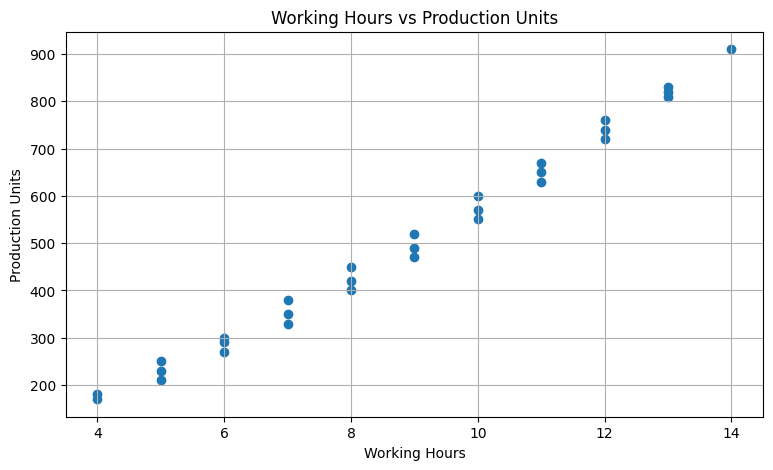

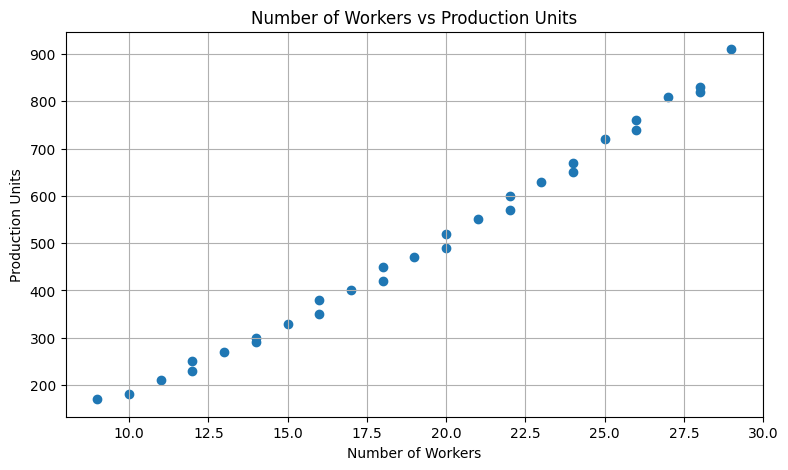

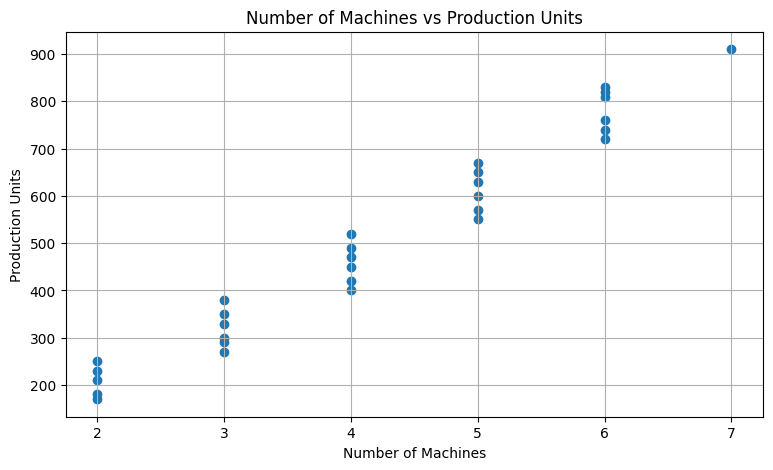

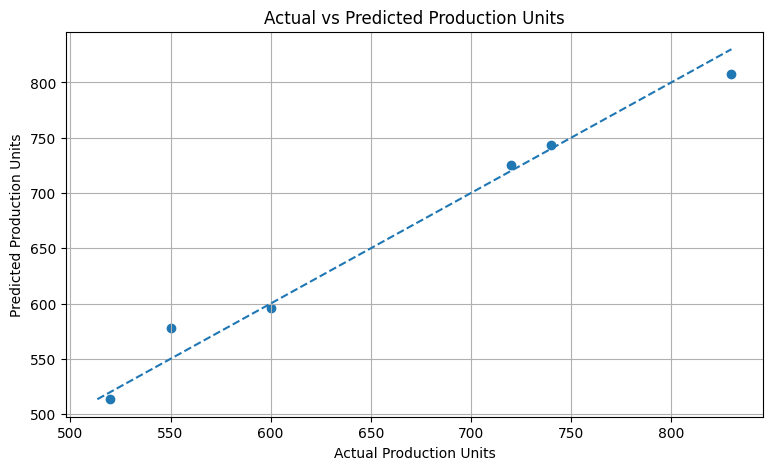


Factory Production Prediction
-----------------------------
Enter working hours: 9
Enter number of workers: 5
Enter number of machines: 2

Prediction Result
-------------------------
Working Hours : 9.00
Workers       : 5
Machines      : 2

Predicted Production Units : 203.73
Production Category        : Low Production


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({

    "Working_Hours": [
        4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
        5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
        4, 6, 8, 10, 12, 5, 7, 9, 11, 13
    ],

    "Workers": [
        10, 12, 14, 16, 18, 20, 22, 24, 26, 28,
        11, 13, 15, 17, 19, 21, 23, 25, 27, 29,
        9, 14, 18, 22, 26, 12, 16, 20, 24, 28
    ],

    "Machines": [
        2, 2, 3, 3, 4, 4, 5, 5, 6, 6,
        2, 3, 3, 4, 4, 5, 5, 6, 6, 7,
        2, 3, 4, 5, 6, 2, 3, 4, 5, 6
    ],

    "Production_Units": [
        180, 230, 290, 350, 420, 490, 570, 650, 740, 830,
        210, 270, 330, 400, 470, 550, 630, 720, 810, 910,
        170, 300, 450, 600, 760, 250, 380, 520, 670, 820
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("Factory Production Dataset")
print("---------------------------")

print(data.head())

print("\nDataset Shape:", data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[
    [
        "Working_Hours",
        "Workers",
        "Machines"
    ]
]

y = data["Production_Units"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Make Predictions
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\nModel Evaluation")
print("-------------------------")

print("MAE  :", round(mae, 2), "units")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2), "units")
print("R²   :", round(r2, 4))


# ============================================================
# 9. Display Model Coefficients
# ============================================================

print("\nModel Coefficients")
print("-------------------------")

print(
    "Working Hours Coefficient :",
    round(model.coef_[0], 2)
)

print(
    "Workers Coefficient       :",
    round(model.coef_[1], 2)
)

print(
    "Machines Coefficient      :",
    round(model.coef_[2], 2)
)

print(
    "Intercept                 :",
    round(model.intercept_, 2)
)


# ============================================================
# 10. Production Category
# ============================================================

def production_category(units):

    if units < 300:
        return "Low Production"

    elif units < 500:
        return "Moderate Production"

    elif units < 700:
        return "High Production"

    else:
        return "Very High Production"


# ============================================================
# 11. Scatter Plot
# Working Hours vs Production Units
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Working_Hours"],
    data["Production_Units"]
)

plt.xlabel("Working Hours")
plt.ylabel("Production Units")

plt.title(
    "Working Hours vs Production Units"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. Scatter Plot
# Workers vs Production Units
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Workers"],
    data["Production_Units"]
)

plt.xlabel("Number of Workers")
plt.ylabel("Production Units")

plt.title(
    "Number of Workers vs Production Units"
)

plt.grid(True)

plt.show()


# ============================================================
# 13. Scatter Plot
# Machines vs Production Units
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Machines"],
    data["Production_Units"]
)

plt.xlabel("Number of Machines")
plt.ylabel("Production Units")

plt.title(
    "Number of Machines vs Production Units"
)

plt.grid(True)

plt.show()


# ============================================================
# 14. Actual vs Predicted Scatter Plot
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Production Units")
plt.ylabel("Predicted Production Units")

plt.title(
    "Actual vs Predicted Production Units"
)

plt.grid(True)

plt.show()


# ============================================================
# 15. User Input
# ============================================================

print("\nFactory Production Prediction")
print("-----------------------------")

while True:

    try:

        hours = float(
            input("Enter working hours: ")
        )

        workers = float(
            input("Enter number of workers: ")
        )

        machines = float(
            input("Enter number of machines: ")
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        if hours <= 0 or hours > 24:

            print(
                "Working hours should be between 1 and 24."
            )

            continue


        if workers <= 0 or workers > 1000:

            print(
                "Number of workers should be between 1 and 1000."
            )

            continue


        if machines <= 0 or machines > 500:

            print(
                "Number of machines should be between 1 and 500."
            )

            continue


        break


    except ValueError:

        print(
            "Please enter valid numeric values."
        )


# ============================================================
# 16. Create New Data
# ============================================================

new_data = pd.DataFrame({

    "Working_Hours": [hours],

    "Workers": [workers],

    "Machines": [machines]

})


# ============================================================
# 17. Predict Production
# ============================================================

predicted_production = model.predict(
    new_data
)[0]


# Prevent negative prediction
predicted_production = max(
    0,
    predicted_production
)


# ============================================================
# 18. Production Category
# ============================================================

category = production_category(
    predicted_production
)


# ============================================================
# 19. Display Final Result
# ============================================================

print("\nPrediction Result")
print("-------------------------")

print(
    f"Working Hours : {hours:.2f}"
)

print(
    f"Workers       : {workers:.0f}"
)

print(
    f"Machines      : {machines:.0f}"
)

print(
    f"\nPredicted Production Units : "
    f"{predicted_production:.2f}"
)

print(
    f"Production Category        : "
    f"{category}"
)

24. Plant Growth Prediction

Plant Growth Dataset
--------------------
   Water  Sunlight  Fertilizer  Plant_Height
0    100         3          10            12
1    120         4          15            15
2    140         5          20            18
3    160         6          25            21
4    180         7          30            25

Dataset Shape: (30, 4)

Model Evaluation
-------------------------
MAE  : 1.62 cm
MSE  : 4.07
RMSE : 2.02 cm
R²   : 0.925

Model Coefficients
-------------------------
Water Coefficient      : 0.05
Sunlight Coefficient   : -1.19
Fertilizer Coefficient : 0.75
Intercept              : 2.6


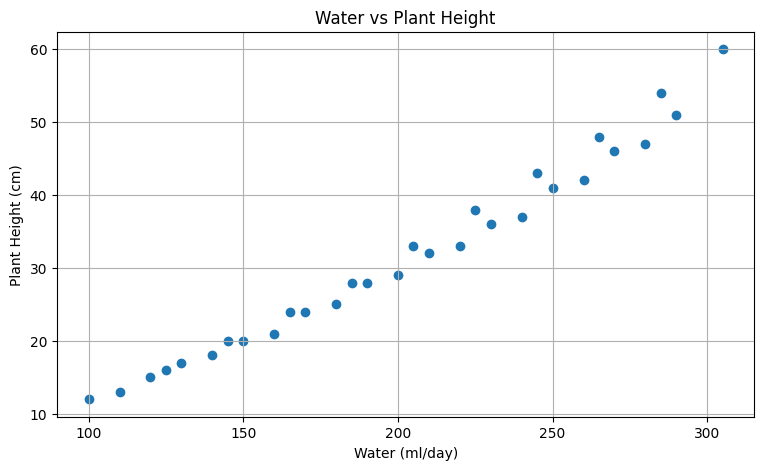

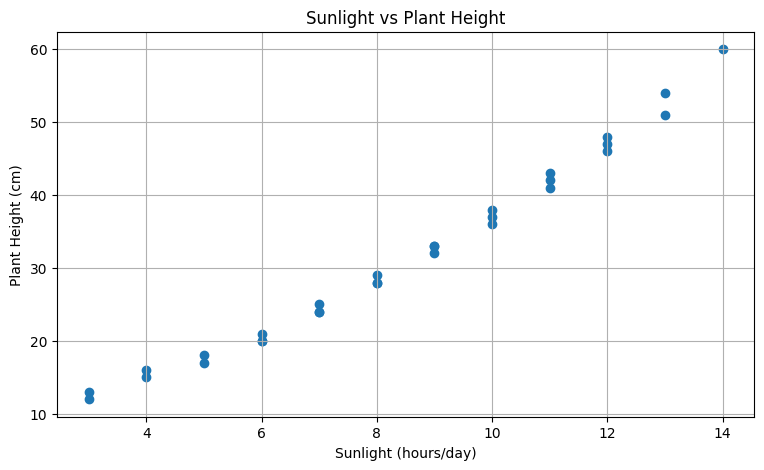

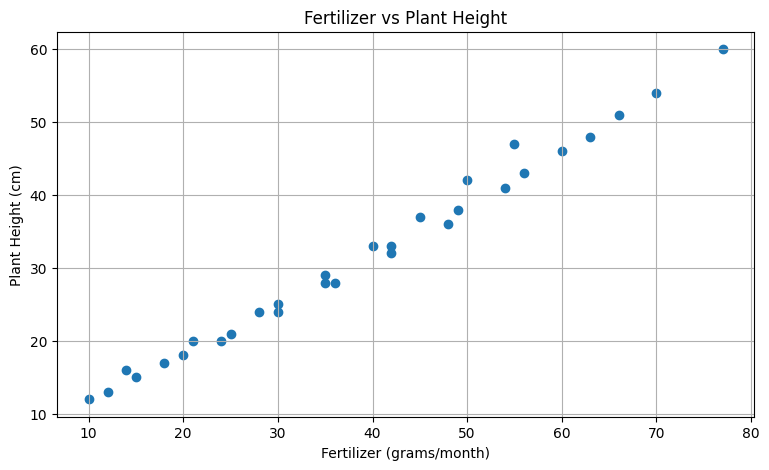

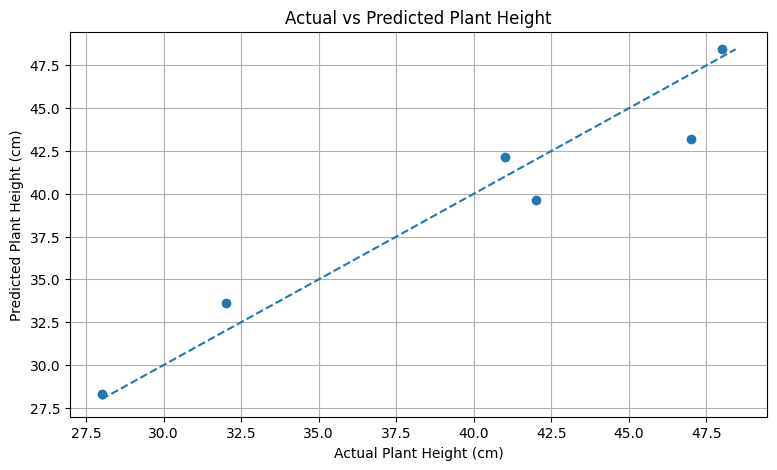


Plant Growth Prediction
-----------------------
Enter water amount (ml/day): 5
Enter sunlight hours/day: 9
Enter fertilizer amount (grams/month): 96

Prediction Result
-------------------------
Water       : 5.00 ml/day
Sunlight    : 9.00 hours/day
Fertilizer  : 96.00 grams/month

Predicted Plant Height : 64.15 cm
Growth Category        : Excellent Growth


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ============================================================
# 1. Create Dataset
# ============================================================

data = pd.DataFrame({

    "Water": [
        100, 120, 140, 160, 180, 200, 220, 240, 260, 280,
        110, 130, 150, 170, 190, 210, 230, 250, 270, 290,
        125, 145, 165, 185, 205, 225, 245, 265, 285, 305
    ],

    "Sunlight": [
        3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
        3, 5, 6, 7, 8, 9, 10, 11, 12, 13,
        4, 6, 7, 8, 9, 10, 11, 12, 13, 14
    ],

    "Fertilizer": [
        10, 15, 20, 25, 30, 35, 40, 45, 50, 55,
        12, 18, 24, 30, 36, 42, 48, 54, 60, 66,
        14, 21, 28, 35, 42, 49, 56, 63, 70, 77
    ],

    "Plant_Height": [
        12, 15, 18, 21, 25, 29, 33, 37, 42, 47,
        13, 17, 20, 24, 28, 32, 36, 41, 46, 51,
        16, 20, 24, 28, 33, 38, 43, 48, 54, 60
    ]
})


# ============================================================
# 2. Display Dataset
# ============================================================

print("Plant Growth Dataset")
print("--------------------")

print(data.head())

print("\nDataset Shape:", data.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

X = data[
    [
        "Water",
        "Sunlight",
        "Fertilizer"
    ]
]

y = data["Plant_Height"]


# ============================================================
# 4. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. Create Linear Regression Model
# ============================================================

model = LinearRegression()


# ============================================================
# 6. Train Model
# ============================================================

model.fit(X_train, y_train)


# ============================================================
# 7. Make Predictions
# ============================================================

y_pred = model.predict(X_test)


# ============================================================
# 8. Model Evaluation
# ============================================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)


print("\nModel Evaluation")
print("-------------------------")

print("MAE  :", round(mae, 2), "cm")
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2), "cm")
print("R²   :", round(r2, 4))


# ============================================================
# 9. Display Model Coefficients
# ============================================================

print("\nModel Coefficients")
print("-------------------------")

print(
    "Water Coefficient      :",
    round(model.coef_[0], 2)
)

print(
    "Sunlight Coefficient   :",
    round(model.coef_[1], 2)
)

print(
    "Fertilizer Coefficient :",
    round(model.coef_[2], 2)
)

print(
    "Intercept              :",
    round(model.intercept_, 2)
)


# ============================================================
# 10. Plant Growth Category
# ============================================================

def growth_category(height):

    if height < 20:
        return "Poor Growth"

    elif height < 35:
        return "Moderate Growth"

    elif height < 50:
        return "Good Growth"

    else:
        return "Excellent Growth"


# ============================================================
# 11. Scatter Plot
# Water vs Plant Height
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Water"],
    data["Plant_Height"]
)

plt.xlabel("Water (ml/day)")
plt.ylabel("Plant Height (cm)")

plt.title(
    "Water vs Plant Height"
)

plt.grid(True)

plt.show()


# ============================================================
# 12. Scatter Plot
# Sunlight vs Plant Height
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Sunlight"],
    data["Plant_Height"]
)

plt.xlabel("Sunlight (hours/day)")
plt.ylabel("Plant Height (cm)")

plt.title(
    "Sunlight vs Plant Height"
)

plt.grid(True)

plt.show()


# ============================================================
# 13. Scatter Plot
# Fertilizer vs Plant Height
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    data["Fertilizer"],
    data["Plant_Height"]
)

plt.xlabel("Fertilizer (grams/month)")
plt.ylabel("Plant Height (cm)")

plt.title(
    "Fertilizer vs Plant Height"
)

plt.grid(True)

plt.show()


# ============================================================
# 14. Actual vs Predicted Scatter Plot
# ============================================================

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Plant Height (cm)")
plt.ylabel("Predicted Plant Height (cm)")

plt.title(
    "Actual vs Predicted Plant Height"
)

plt.grid(True)

plt.show()


# ============================================================
# 15. User Input
# ============================================================

print("\nPlant Growth Prediction")
print("-----------------------")

while True:

    try:

        water = float(
            input("Enter water amount (ml/day): ")
        )

        sunlight = float(
            input("Enter sunlight hours/day: ")
        )

        fertilizer = float(
            input("Enter fertilizer amount (grams/month): ")
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        if water <= 0 or water > 5000:

            print(
                "Water should be between 1 and 5000 ml/day."
            )

            continue


        if sunlight <= 0 or sunlight > 24:

            print(
                "Sunlight should be between 1 and 24 hours/day."
            )

            continue


        if fertilizer < 0 or fertilizer > 1000:

            print(
                "Fertilizer should be between 0 and 1000 grams/month."
            )

            continue


        break


    except ValueError:

        print(
            "Please enter valid numeric values."
        )


# ============================================================
# 16. Create New Data
# ============================================================

new_data = pd.DataFrame({

    "Water": [water],

    "Sunlight": [sunlight],

    "Fertilizer": [fertilizer]

})


# ============================================================
# 17. Predict Plant Height
# ============================================================

predicted_height = model.predict(
    new_data
)[0]


# Prevent negative prediction
predicted_height = max(
    0,
    predicted_height
)


# ============================================================
# 18. Growth Category
# ============================================================

category = growth_category(
    predicted_height
)


# ============================================================
# 19. Display Final Result
# ============================================================

print("\nPrediction Result")
print("-------------------------")

print(
    f"Water       : {water:.2f} ml/day"
)

print(
    f"Sunlight    : {sunlight:.2f} hours/day"
)

print(
    f"Fertilizer  : {fertilizer:.2f} grams/month"
)

print(
    f"\nPredicted Plant Height : "
    f"{predicted_height:.2f} cm"
)

print(
    f"Growth Category        : "
    f"{category}"
)

25. Milk Production Prediction


Dataset:
    Feed_Quantity  Cow_Age  Water_Intake  Milk_Produced
0               5        2            25            8.5
1               6        2            28            9.2
2               7        3            30           10.1
3               8        3            32           11.0
4               9        4            35           12.0
5              10        4            38           13.1
6              11        5            40           14.0
7              12        5            42           15.0
8              13        6            45           16.2
9              14        6            48           17.0
10              6        2            27            9.0
11              7        3            31           10.0
12              8        3            34           10.8
13              9        4            36           11.8
14             10        4            39           12.8
15             11        5            41           13.8
16             12        5            4

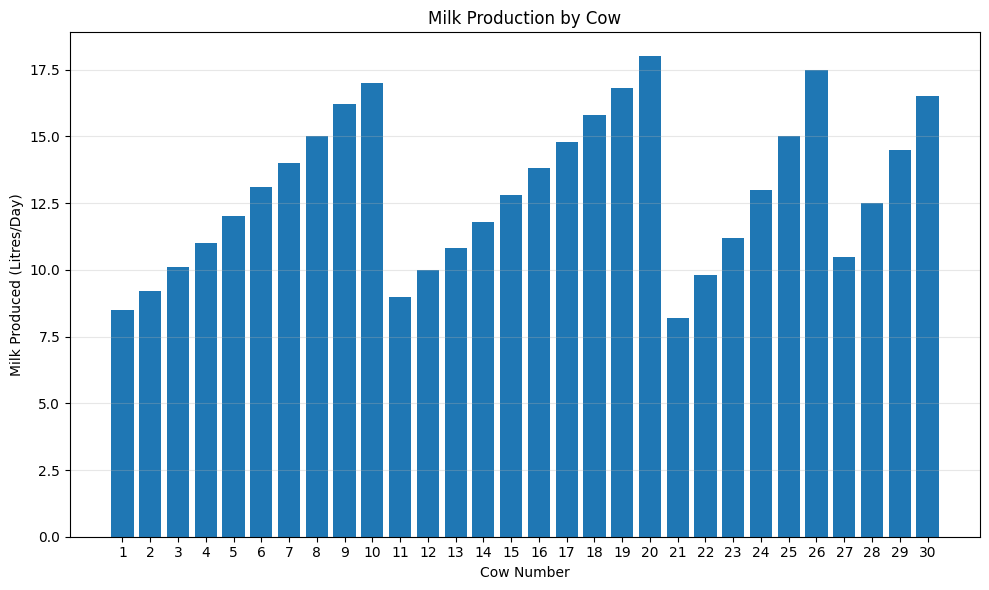

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---------------------------------------------------
# 1. Create Dataset
# ---------------------------------------------------

data = pd.DataFrame({
    "Feed_Quantity": [
        5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
        6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
        5, 7, 9, 11, 13, 15, 8, 10, 12, 14
    ],

    "Cow_Age": [
        2, 2, 3, 3, 4, 4, 5, 5, 6, 6,
        2, 3, 3, 4, 4, 5, 5, 6, 7, 7,
        2, 3, 4, 5, 6, 7, 3, 4, 5, 6
    ],

    "Water_Intake": [
        25, 28, 30, 32, 35, 38, 40, 42, 45, 48,
        27, 31, 34, 36, 39, 41, 44, 46, 49, 52,
        24, 29, 34, 39, 44, 50, 33, 38, 43, 48
    ],

    "Milk_Produced": [
        8.5, 9.2, 10.1, 11.0, 12.0, 13.1, 14.0, 15.0, 16.2, 17.0,
        9.0, 10.0, 10.8, 11.8, 12.8, 13.8, 14.8, 15.8, 16.8, 18.0,
        8.2, 9.8, 11.2, 13.0, 15.0, 17.5, 10.5, 12.5, 14.5, 16.5
    ]
})


print("Dataset:")
print(data)


# ---------------------------------------------------
# 2. Input and Target
# ---------------------------------------------------

X = data[["Feed_Quantity", "Cow_Age", "Water_Intake"]]
y = data["Milk_Produced"]


# ---------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------
# 4. Train Linear Regression Model
# ---------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)


# ---------------------------------------------------
# 5. Prediction
# ---------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------
# 6. Model Evaluation
# ---------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


# ---------------------------------------------------
# 7. Model Coefficients
# ---------------------------------------------------

print("\n--- Model Coefficients ---")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print(f"Intercept: {model.intercept_:.2f}")


# ---------------------------------------------------
# 8. User Input
# ---------------------------------------------------

print("\n--- Enter Cow Details ---")

while True:
    try:
        feed = float(input("Enter feed quantity (kg/day): "))

        if feed <= 0 or feed > 50:
            print("Enter feed quantity between 0 and 50 kg.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        age = float(input("Enter cow age (years): "))

        if age <= 0 or age > 20:
            print("Enter cow age between 0 and 20 years.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        water = float(input("Enter water intake (litres/day): "))

        if water <= 0 or water > 150:
            print("Enter water intake between 0 and 150 litres.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


# ---------------------------------------------------
# 9. Predict Milk Production
# ---------------------------------------------------

new_cow = pd.DataFrame({
    "Feed_Quantity": [feed],
    "Cow_Age": [age],
    "Water_Intake": [water]
})

prediction = model.predict(new_cow)[0]

prediction = max(0, prediction)


# ---------------------------------------------------
# 10. Production Category
# ---------------------------------------------------

if prediction < 8:
    category = "Low Production"

elif prediction < 12:
    category = "Moderate Production"

elif prediction < 16:
    category = "Good Production"

else:
    category = "High Production"


# ---------------------------------------------------
# 11. Display Result
# ---------------------------------------------------

print("\n==============================")
print("    MILK PRODUCTION RESULT")
print("==============================")

print(f"Feed Quantity : {feed:.2f} kg/day")
print(f"Cow Age       : {age:.2f} years")
print(f"Water Intake  : {water:.2f} litres/day")
print(f"Milk Produced : {prediction:.2f} litres/day")
print(f"Category      : {category}")


# ---------------------------------------------------
# 12. BAR CHART ONLY
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    range(1, len(data) + 1),
    data["Milk_Produced"]
)

plt.xlabel("Cow Number")
plt.ylabel("Milk Produced (Litres/Day)")
plt.title("Milk Production by Cow")

plt.xticks(range(1, len(data) + 1))

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

26. Internet Data Usage Prediction

Dataset:
    Streaming_Hours  Downloads  Devices  Data_Usage
0                 5          2        1          25
1                 8          4        1          35
2                10          5        2          45
3                12          6        2          52
4                15          8        2          65
5                18          9        3          78
6                20         11        3          88
7                22         12        3          98
8                25         14        4         115
9                28         16        4         130
10                6          3        1          30
11                9          5        2          42
12               11          6        2          50
13               14          7        2          62
14               17          9        3          74
15               19         10        3          85
16               21         12        4          96
17               24         13        4         108
18 

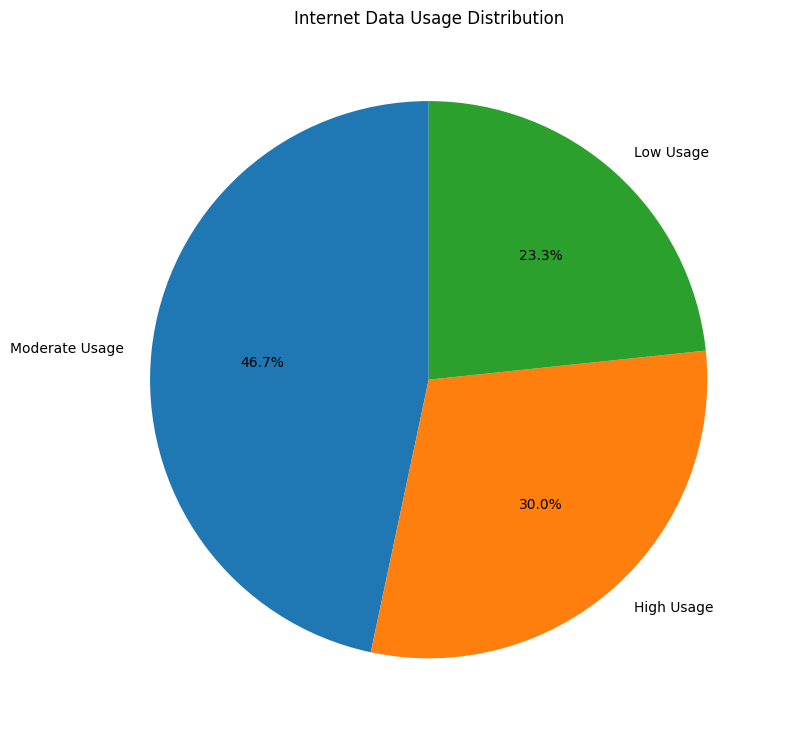

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---------------------------------------------------
# 1. Create Sample Dataset
# ---------------------------------------------------

data = pd.DataFrame({
    "Streaming_Hours": [
        5, 8, 10, 12, 15, 18, 20, 22, 25, 28,
        6, 9, 11, 14, 17, 19, 21, 24, 27, 30,
        7, 13, 16, 23, 26, 29, 10, 15, 20, 25
    ],

    "Downloads": [
        2, 4, 5, 6, 8, 9, 11, 12, 14, 16,
        3, 5, 6, 7, 9, 10, 12, 13, 15, 17,
        3, 6, 8, 12, 13, 16, 5, 8, 11, 14
    ],

    "Devices": [
        1, 1, 2, 2, 2, 3, 3, 3, 4, 4,
        1, 2, 2, 2, 3, 3, 4, 4, 4, 5,
        1, 2, 3, 3, 4, 5, 2, 3, 4, 4
    ],

    "Data_Usage": [
        25, 35, 45, 52, 65, 78, 88, 98, 115, 130,
        30, 42, 50, 62, 74, 85, 96, 108, 125, 142,
        32, 55, 70, 105, 120, 138, 48, 68, 92, 118
    ]
})


print("Dataset:")
print(data)


# ---------------------------------------------------
# 2. Input and Target
# ---------------------------------------------------

X = data[["Streaming_Hours", "Downloads", "Devices"]]
y = data["Data_Usage"]


# ---------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------
# 4. Train Linear Regression Model
# ---------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)


# ---------------------------------------------------
# 5. Test Prediction
# ---------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------
# 6. Model Evaluation
# ---------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


# ---------------------------------------------------
# 7. Model Coefficients
# ---------------------------------------------------

print("\n--- Model Coefficients ---")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print(f"Intercept: {model.intercept_:.2f}")


# ---------------------------------------------------
# 8. User Input
# ---------------------------------------------------

print("\n--- Enter Internet Usage Details ---")

while True:
    try:
        streaming = float(input("Enter streaming hours/month: "))

        if streaming < 0 or streaming > 1000:
            print("Enter streaming hours between 0 and 1000.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        downloads = float(input("Enter number of downloads/month: "))

        if downloads < 0 or downloads > 1000:
            print("Enter downloads between 0 and 1000.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        devices = int(input("Enter number of connected devices: "))

        if devices < 1 or devices > 50:
            print("Enter devices between 1 and 50.")
            continue

        break

    except ValueError:
        print("Please enter a valid whole number.")


# ---------------------------------------------------
# 9. Predict Data Usage
# ---------------------------------------------------

new_user = pd.DataFrame({
    "Streaming_Hours": [streaming],
    "Downloads": [downloads],
    "Devices": [devices]
})

prediction = model.predict(new_user)[0]

prediction = max(0, prediction)


# ---------------------------------------------------
# 10. Data Usage Category
# ---------------------------------------------------

if prediction < 50:
    category = "Low Usage"

elif prediction < 100:
    category = "Moderate Usage"

elif prediction < 150:
    category = "High Usage"

else:
    category = "Very High Usage"


# ---------------------------------------------------
# 11. Display Result
# ---------------------------------------------------

print("\n==============================")
print("   DATA USAGE PREDICTION")
print("==============================")

print(f"Streaming Hours : {streaming:.2f}")
print(f"Downloads       : {downloads:.2f}")
print(f"Devices         : {devices}")
print(f"Predicted Usage : {prediction:.2f} GB/month")
print(f"Category        : {category}")


# ---------------------------------------------------
# 12. PIE CHART
# ---------------------------------------------------

usage_categories = []

for usage in data["Data_Usage"]:

    if usage < 50:
        usage_categories.append("Low Usage")

    elif usage < 100:
        usage_categories.append("Moderate Usage")

    elif usage < 150:
        usage_categories.append("High Usage")

    else:
        usage_categories.append("Very High Usage")


category_counts = pd.Series(usage_categories).value_counts()


plt.figure(figsize=(8, 8))

plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Internet Data Usage Distribution")

plt.tight_layout()
plt.show()

27. Battery Life Prediction

Dataset:
    Screen_Time  Brightness  Apps_Used  Battery_Remaining
0             1          20          3                 92
1             2          25          4                 84
2             3          30          5                 76
3             4          35          6                 68
4             5          40          7                 60
5             6          45          8                 51
6             7          50          9                 43
7             8          55         10                 35
8             2          30          4                 82
9             3          35          5                 73
10            4          40          6                 65
11            5          45          7                 56
12            6          50          8                 48
13            7          55          9                 39
14            8          60         10                 31
15            9          65         11                 23
16   

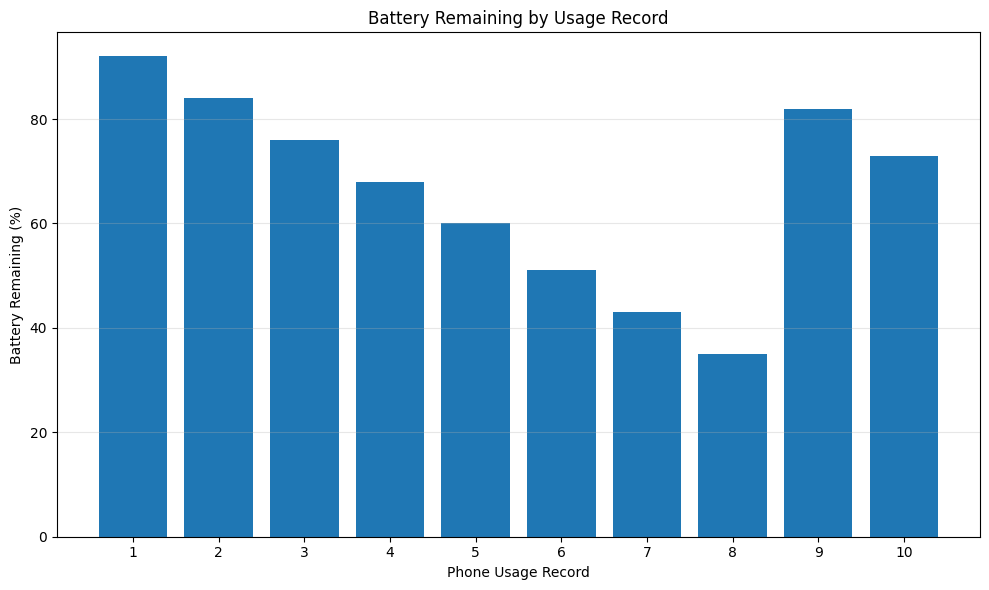

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---------------------------------------------------
# 1. Create Sample Dataset
# ---------------------------------------------------

data = pd.DataFrame({
    "Screen_Time": [
        1, 2, 3, 4, 5, 6, 7, 8, 2, 3,
        4, 5, 6, 7, 8, 9, 1, 3, 5, 7,
        2, 4, 6, 8, 9, 10, 3, 5, 7, 9
    ],

    "Brightness": [
        20, 25, 30, 35, 40, 45, 50, 55, 30, 35,
        40, 45, 50, 55, 60, 65, 25, 35, 45, 55,
        30, 40, 50, 60, 70, 75, 30, 45, 60, 70
    ],

    "Apps_Used": [
        3, 4, 5, 6, 7, 8, 9, 10, 4, 5,
        6, 7, 8, 9, 10, 11, 2, 5, 7, 9,
        4, 6, 8, 10, 12, 13, 5, 8, 10, 12
    ],

    "Battery_Remaining": [
        92, 84, 76, 68, 60, 51, 43, 35, 82, 73,
        65, 56, 48, 39, 31, 23, 94, 75, 57, 40,
        85, 69, 50, 34, 25, 16, 78, 58, 39, 22
    ]
})


print("Dataset:")
print(data)


# ---------------------------------------------------
# 2. Input and Target
# ---------------------------------------------------

X = data[["Screen_Time", "Brightness", "Apps_Used"]]
y = data["Battery_Remaining"]


# ---------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------
# 4. Train Linear Regression Model
# ---------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)


# ---------------------------------------------------
# 5. Test Prediction
# ---------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------
# 6. Model Evaluation
# ---------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


# ---------------------------------------------------
# 7. Model Coefficients
# ---------------------------------------------------

print("\n--- Model Coefficients ---")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print(f"Intercept: {model.intercept_:.2f}")


# ---------------------------------------------------
# 8. User Input
# ---------------------------------------------------

print("\n--- Enter Phone Usage Details ---")

while True:
    try:
        screen_time = float(
            input("Enter screen time (hours/day): ")
        )

        if screen_time < 0 or screen_time > 24:
            print("Enter screen time between 0 and 24 hours.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        brightness = float(
            input("Enter screen brightness (%): ")
        )

        if brightness < 0 or brightness > 100:
            print("Enter brightness between 0 and 100.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        apps = int(
            input("Enter number of apps used: ")
        )

        if apps < 0 or apps > 100:
            print("Enter apps used between 0 and 100.")
            continue

        break

    except ValueError:
        print("Please enter a valid whole number.")


# ---------------------------------------------------
# 9. Predict Battery Remaining
# ---------------------------------------------------

new_phone = pd.DataFrame({
    "Screen_Time": [screen_time],
    "Brightness": [brightness],
    "Apps_Used": [apps]
})

prediction = model.predict(new_phone)[0]

# Keep prediction between 0% and 100%
prediction = max(0, min(100, prediction))


# ---------------------------------------------------
# 10. Battery Category
# ---------------------------------------------------

if prediction < 20:
    category = "Critical"

elif prediction < 40:
    category = "Low"

elif prediction < 70:
    category = "Moderate"

else:
    category = "Healthy"


# ---------------------------------------------------
# 11. Display Result
# ---------------------------------------------------

print("\n==============================")
print("    BATTERY LIFE PREDICTION")
print("==============================")

print(f"Screen Time      : {screen_time:.2f} hours")
print(f"Brightness       : {brightness:.2f}%")
print(f"Apps Used        : {apps}")
print(f"Battery Remaining: {prediction:.2f}%")
print(f"Battery Status   : {category}")


# ---------------------------------------------------
# 12. BAR CHART
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

sample_data = data.head(10)

plt.bar(
    range(1, 11),
    sample_data["Battery_Remaining"]
)

plt.xlabel("Phone Usage Record")
plt.ylabel("Battery Remaining (%)")
plt.title("Battery Remaining by Usage Record")

plt.xticks(range(1, 11))

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

28. Loan Interest Prediction

Dataset:
    Loan_Amount  Duration  Credit_Score  Interest_Amount
0         50000        12           780             3000
1         75000        12           760             4200
2        100000        18           740             6500
3        125000        18           720             8000
4        150000        24           700            10500
5        175000        24           680            14000
6        200000        30           660            17500
7        225000        30           640            21000
8        250000        36           620            26000
9        275000        36           600            31000
10        60000        12           770             3500
11        90000        18           750             6000
12       120000        18           730             7500
13       140000        24           710            10000
14       160000        24           690            12000
15       180000        30           670            16000
16       210000       

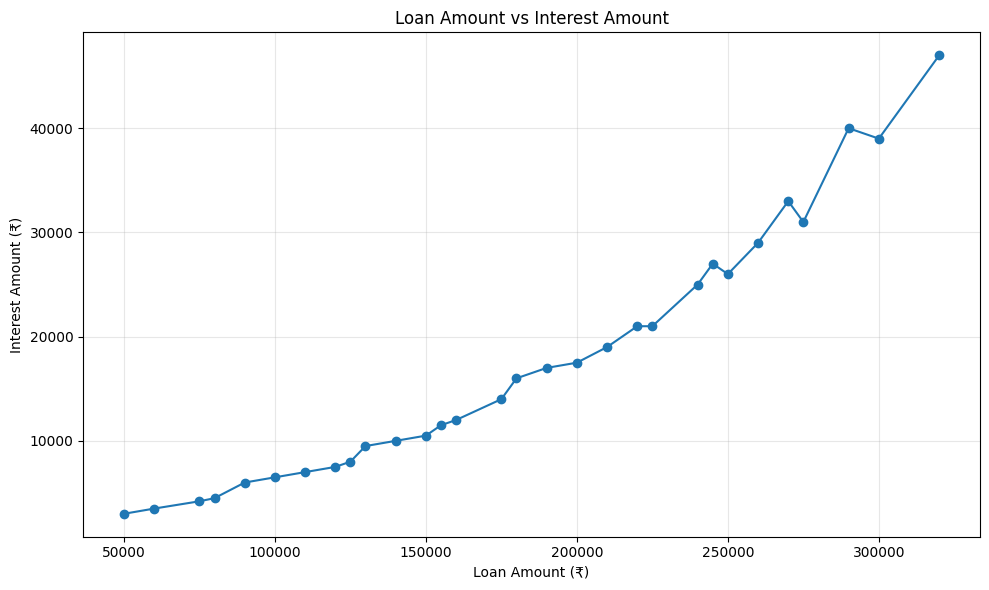

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---------------------------------------------------
# 1. Create Sample Dataset
# ---------------------------------------------------

data = pd.DataFrame({
    "Loan_Amount": [
        50000, 75000, 100000, 125000, 150000,
        175000, 200000, 225000, 250000, 275000,
        60000, 90000, 120000, 140000, 160000,
        180000, 210000, 240000, 260000, 300000,
        80000, 110000, 130000, 155000, 190000,
        220000, 245000, 270000, 290000, 320000
    ],

    "Duration": [
        12, 12, 18, 18, 24,
        24, 30, 30, 36, 36,
        12, 18, 18, 24, 24,
        30, 30, 36, 36, 48,
        12, 18, 24, 24, 30,
        30, 36, 42, 48, 48
    ],

    "Credit_Score": [
        780, 760, 740, 720, 700,
        680, 660, 640, 620, 600,
        770, 750, 730, 710, 690,
        670, 650, 630, 610, 590,
        765, 745, 725, 705, 685,
        665, 645, 625, 605, 580
    ],

    "Interest_Amount": [
        3000, 4200, 6500, 8000, 10500,
        14000, 17500, 21000, 26000, 31000,
        3500, 6000, 7500, 10000, 12000,
        16000, 19000, 25000, 29000, 39000,
        4500, 7000, 9500, 11500, 17000,
        21000, 27000, 33000, 40000, 47000
    ]
})


print("Dataset:")
print(data)


# ---------------------------------------------------
# 2. Separate Input and Target
# ---------------------------------------------------

X = data[["Loan_Amount", "Duration", "Credit_Score"]]
y = data["Interest_Amount"]


# ---------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------
# 4. Train Linear Regression Model
# ---------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)


# ---------------------------------------------------
# 5. Prediction
# ---------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------
# 6. Model Evaluation
# ---------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


# ---------------------------------------------------
# 7. Model Coefficients
# ---------------------------------------------------

print("\n--- Model Coefficients ---")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print(f"Intercept: {model.intercept_:.2f}")


# ---------------------------------------------------
# 8. User Input
# ---------------------------------------------------

print("\n--- Enter Loan Details ---")

while True:
    try:
        loan_amount = float(
            input("Enter loan amount (₹): ")
        )

        if loan_amount <= 0 or loan_amount > 10000000:
            print("Enter loan amount between ₹1 and ₹1,00,00,000.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        duration = int(
            input("Enter loan duration (months): ")
        )

        if duration <= 0 or duration > 360:
            print("Enter duration between 1 and 360 months.")
            continue

        break

    except ValueError:
        print("Please enter a valid whole number.")


while True:
    try:
        credit_score = int(
            input("Enter credit score: ")
        )

        if credit_score < 300 or credit_score > 900:
            print("Enter credit score between 300 and 900.")
            continue

        break

    except ValueError:
        print("Please enter a valid whole number.")


# ---------------------------------------------------
# 9. Predict Interest Amount
# ---------------------------------------------------

new_loan = pd.DataFrame({
    "Loan_Amount": [loan_amount],
    "Duration": [duration],
    "Credit_Score": [credit_score]
})

prediction = model.predict(new_loan)[0]

prediction = max(0, prediction)


# ---------------------------------------------------
# 10. Interest Category
# ---------------------------------------------------

if prediction < 10000:
    category = "Low Interest"

elif prediction < 20000:
    category = "Moderate Interest"

elif prediction < 35000:
    category = "High Interest"

else:
    category = "Very High Interest"


# ---------------------------------------------------
# 11. Display Result
# ---------------------------------------------------

print("\n==============================")
print("    LOAN INTEREST RESULT")
print("==============================")

print(f"Loan Amount     : ₹{loan_amount:,.2f}")
print(f"Duration        : {duration} months")
print(f"Credit Score    : {credit_score}")
print(f"Interest Amount : ₹{prediction:,.2f}")
print(f"Category        : {category}")


# ---------------------------------------------------
# 12. DIFFERENT GRAPH - LINE CHART
# ---------------------------------------------------

sorted_data = data.sort_values("Loan_Amount")

plt.figure(figsize=(10, 6))

plt.plot(
    sorted_data["Loan_Amount"],
    sorted_data["Interest_Amount"],
    marker="o"
)

plt.xlabel("Loan Amount (₹)")
plt.ylabel("Interest Amount (₹)")
plt.title("Loan Amount vs Interest Amount")

plt.grid(True, alpha=0.3)

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

29. Solar Power Generation Prediction

Dataset:
    Sunlight_Hours  Temperature  Panel_Area  Power_Generated
0                3           22          10               22
1                4           24          10               30
2                5           25          12               39
3                6           27          12               49
4                7           29          14               60
5                8           31          14               72
6                9           33          16               86
7               10           35          16              100
8               11           36          18              116
9               12           38          18              132
10               4           23          10               27
11               5           25          12               38
12               6           27          12               47
13               7           28          14               58
14               8           30          14               70
15             

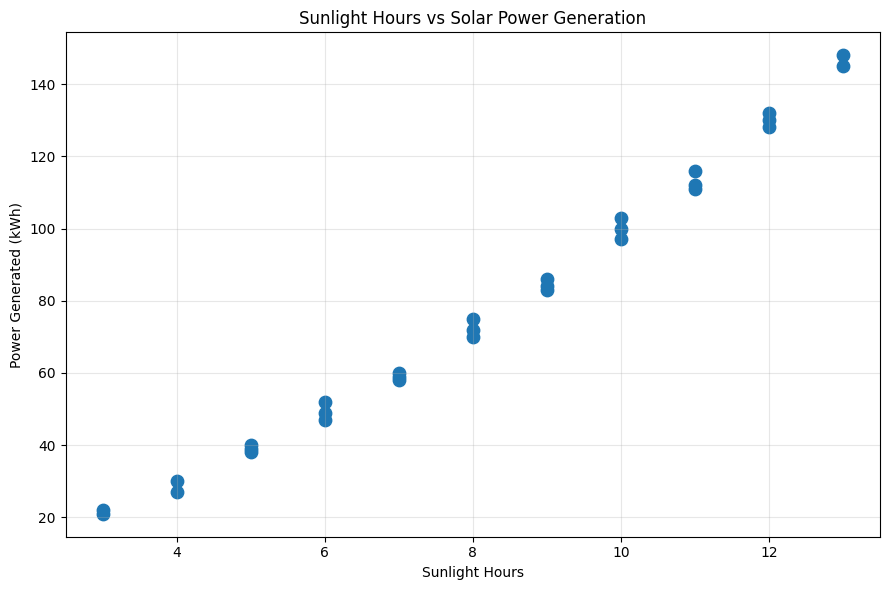

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---------------------------------------------------
# 1. Create Sample Dataset
# ---------------------------------------------------

data = pd.DataFrame({
    "Sunlight_Hours": [
        3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
        4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
        3, 5, 7, 9, 11, 13, 6, 8, 10, 12
    ],

    "Temperature": [
        22, 24, 25, 27, 29, 31, 33, 35, 36, 38,
        23, 25, 27, 28, 30, 32, 34, 36, 38, 40,
        21, 25, 29, 33, 36, 40, 26, 30, 34, 38
    ],

    "Panel_Area": [
        10, 10, 12, 12, 14, 14, 16, 16, 18, 18,
        10, 12, 12, 14, 14, 16, 16, 18, 18, 20,
        10, 12, 14, 16, 18, 20, 12, 14, 16, 18
    ],

    "Power_Generated": [
        22, 30, 39, 49, 60, 72, 86, 100, 116, 132,
        27, 38, 47, 58, 70, 83, 97, 112, 128, 148,
        21, 40, 59, 84, 111, 145, 52, 75, 103, 130
    ]
})


print("Dataset:")
print(data)


# ---------------------------------------------------
# 2. Separate Input and Target
# ---------------------------------------------------

X = data[[
    "Sunlight_Hours",
    "Temperature",
    "Panel_Area"
]]

y = data["Power_Generated"]


# ---------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ---------------------------------------------------
# 4. Train Linear Regression Model
# ---------------------------------------------------

model = LinearRegression()

model.fit(X_train, y_train)


# ---------------------------------------------------
# 5. Test Prediction
# ---------------------------------------------------

y_pred = model.predict(X_test)


# ---------------------------------------------------
# 6. Model Evaluation
# ---------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


# ---------------------------------------------------
# 7. Model Coefficients
# ---------------------------------------------------

print("\n--- Model Coefficients ---")

for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient:.2f}")

print(f"Intercept: {model.intercept_:.2f}")


# ---------------------------------------------------
# 8. User Input
# ---------------------------------------------------

print("\n--- Enter Solar Panel Details ---")


while True:
    try:
        sunlight = float(
            input("Enter sunlight hours/day: ")
        )

        if sunlight <= 0 or sunlight > 24:
            print("Enter sunlight hours between 0 and 24.")

            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        temperature = float(
            input("Enter temperature (°C): ")
        )

        if temperature < -20 or temperature > 60:
            print("Enter temperature between -20°C and 60°C.")

            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        panel_area = float(
            input("Enter panel area (m²): ")
        )

        if panel_area <= 0 or panel_area > 1000:
            print("Enter panel area between 0 and 1000 m².")

            continue

        break

    except ValueError:
        print("Please enter a valid number.")


# ---------------------------------------------------
# 9. Predict Power Generation
# ---------------------------------------------------

new_panel = pd.DataFrame({
    "Sunlight_Hours": [sunlight],
    "Temperature": [temperature],
    "Panel_Area": [panel_area]
})


prediction = model.predict(new_panel)[0]

prediction = max(0, prediction)


# ---------------------------------------------------
# 10. Power Generation Category
# ---------------------------------------------------

if prediction < 50:

    category = "Low Generation"

elif prediction < 100:

    category = "Moderate Generation"

elif prediction < 150:

    category = "High Generation"

else:

    category = "Very High Generation"


# ---------------------------------------------------
# 11. Display Result
# ---------------------------------------------------

print("\n==============================")
print(" SOLAR POWER PREDICTION RESULT")
print("==============================")

print(f"Sunlight Hours : {sunlight:.2f} hours/day")
print(f"Temperature    : {temperature:.2f} °C")
print(f"Panel Area     : {panel_area:.2f} m²")
print(f"Power Generated: {prediction:.2f} kWh")
print(f"Category       : {category}")


# ---------------------------------------------------
# 12. DIFFERENT GRAPH - SCATTER PLOT
# ---------------------------------------------------

plt.figure(figsize=(9, 6))

plt.scatter(
    data["Sunlight_Hours"],
    data["Power_Generated"],
    s=80
)

plt.xlabel("Sunlight Hours")
plt.ylabel("Power Generated (kWh)")
plt.title("Sunlight Hours vs Solar Power Generation")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

30 YouTube Views Prediction


========== MODEL PERFORMANCE ==========
MAE  : 1203.44
MSE  : 1895039.46
RMSE : 1376.60
R²   : 0.95

========== MODEL DETAILS ==========
Subscribers Coefficient : 1.17
Video Length Coefficient: -424.99
Likes Coefficient       : 18.25
Intercept               : 422.61

========== ENTER VIDEO DETAILS ==========
Enter number of subscribers: 9
Enter video length in minutes: 1
Enter number of likes: 15

       YOUTUBE VIEWS PREDICTION
Subscribers     : 9
Video Length    : 1.0 minutes
Likes           : 15
--------------------------------------
Predicted Views : 282
Category        : Low Views


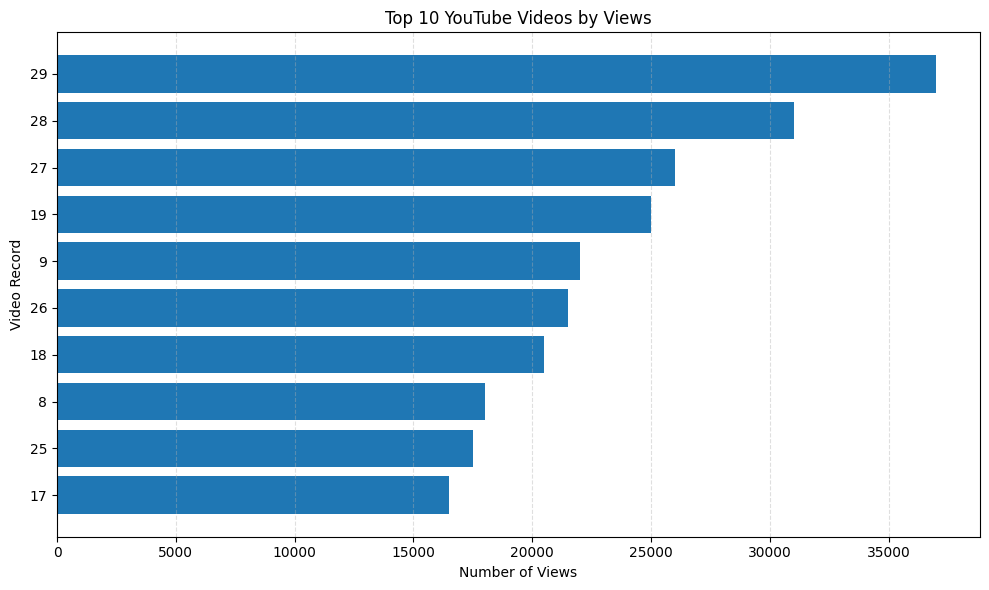

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# --------------------------------------------------
# 1. Create Sample Dataset
# --------------------------------------------------

data = {
    "Subscribers": [
        1000, 1500, 2000, 2500, 3000,
        4000, 5000, 6000, 7000, 8000,
        1200, 1800, 2800, 3500, 4500,
        5500, 6500, 7500, 9000, 10000,
        2200, 3200, 4200, 5200, 6200,
        7200, 8200, 9200, 11000, 12000
    ],

    "Video_Length": [
        5, 6, 7, 8, 10,
        12, 15, 18, 20, 22,
        6, 8, 9, 11, 13,
        16, 19, 21, 23, 25,
        7, 10, 12, 14, 17,
        20, 22, 24, 26, 28
    ],

    "Likes": [
        80, 120, 180, 250, 320,
        450, 600, 750, 900, 1100,
        100, 160, 220, 300, 400,
        550, 700, 850, 1050, 1250,
        200, 350, 500, 650, 800,
        1000, 1200, 1400, 1600, 1800
    ],

    "Views": [
        1500, 2200, 3200, 4500, 6000,
        8500, 11500, 14500, 18000, 22000,
        1800, 2800, 3800, 5200, 7000,
        9500, 13000, 16500, 20500, 25000,
        3500, 5500, 7500, 10000, 13500,
        17500, 21500, 26000, 31000, 37000
    ]
}

df = pd.DataFrame(data)


# --------------------------------------------------
# 2. Define Input and Target
# --------------------------------------------------

X = df[["Subscribers", "Video_Length", "Likes"]]
y = df["Views"]


# --------------------------------------------------
# 3. Train-Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------------
# 4. Train Linear Regression Model
# --------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)


# --------------------------------------------------
# 5. Prediction on Test Data
# --------------------------------------------------

y_pred = model.predict(X_test)


# --------------------------------------------------
# 6. Model Evaluation
# --------------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL PERFORMANCE ==========")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")


# --------------------------------------------------
# 7. Model Coefficients
# --------------------------------------------------

print("\n========== MODEL DETAILS ==========")
print(f"Subscribers Coefficient : {model.coef_[0]:.2f}")
print(f"Video Length Coefficient: {model.coef_[1]:.2f}")
print(f"Likes Coefficient       : {model.coef_[2]:.2f}")
print(f"Intercept               : {model.intercept_:.2f}")


# --------------------------------------------------
# 8. Take User Input
# --------------------------------------------------

print("\n========== ENTER VIDEO DETAILS ==========")

while True:
    try:
        subscribers = float(input("Enter number of subscribers: "))

        if subscribers < 0:
            print("Subscribers cannot be negative.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        video_length = float(input("Enter video length in minutes: "))

        if video_length <= 0 or video_length > 600:
            print("Video length should be between 0 and 600 minutes.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


while True:
    try:
        likes = float(input("Enter number of likes: "))

        if likes < 0:
            print("Likes cannot be negative.")
            continue

        break

    except ValueError:
        print("Please enter a valid number.")


# --------------------------------------------------
# 9. Predict YouTube Views
# --------------------------------------------------

new_video = pd.DataFrame({
    "Subscribers": [subscribers],
    "Video_Length": [video_length],
    "Likes": [likes]
})

predicted_views = model.predict(new_video)[0]

predicted_views = max(0, predicted_views)


# --------------------------------------------------
# 10. Categorize Views
# --------------------------------------------------

if predicted_views < 5000:
    category = "Low Views"

elif predicted_views < 15000:
    category = "Moderate Views"

elif predicted_views < 30000:
    category = "High Views"

else:
    category = "Very High Views"


# --------------------------------------------------
# 11. Display Result
# --------------------------------------------------

print("\n======================================")
print("       YOUTUBE VIEWS PREDICTION")
print("======================================")

print(f"Subscribers     : {subscribers:.0f}")
print(f"Video Length    : {video_length:.1f} minutes")
print(f"Likes           : {likes:.0f}")

print("--------------------------------------")
print(f"Predicted Views : {predicted_views:.0f}")
print(f"Category        : {category}")
print("======================================")


# --------------------------------------------------
# 12. DIFFERENT GRAPH
# Horizontal Bar Chart
# Top 10 Videos by Views
# --------------------------------------------------

graph_data = df.sort_values(
    by="Views",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    graph_data.index.astype(str),
    graph_data["Views"]
)

plt.xlabel("Number of Views")
plt.ylabel("Video Record")
plt.title("Top 10 YouTube Videos by Views")

plt.gca().invert_yaxis()

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()